In [1]:
# ==============================================================================
# CELDA 0 — INSTALACIÓN DE DEPENDENCIAS
# ==============================================================================
!pip install -q gplearn pysr xgboost

import sklearn, numpy, scipy, pandas, matplotlib, sympy, joblib
print("=" * 78)
print("  DEPENDENCIAS INSTALADAS")
print("=" * 78)
for _m in (sklearn, numpy, scipy, pandas, matplotlib, sympy, joblib):
    print(f"    {_m.__name__:<14} {_m.__version__}")
try:
    import xgboost, gplearn, pysr
    for _m in (xgboost, gplearn, pysr):
        print(f"    {_m.__name__:<14} {_m.__version__}")
except Exception as _e:
    print(f"    (aún no importables antes del reinicio: {_e})")
print("\n  AHORA: Entorno de ejecución > Reiniciar sesión.")
print("  Después ejecuta desde la Celda 1. No vuelvas a ejecutar esta celda.")

  DEPENDENCIAS INSTALADAS
    sklearn        1.9.1
    numpy          2.1.3
    scipy          1.16.3
    pandas         2.2.3
    matplotlib     3.10.0
    sympy          1.14.0
    joblib         1.6.0
    xgboost        3.4.1
    gplearn        0.4.3
    pysr           2.5.1

  AHORA: Entorno de ejecución > Reiniciar sesión.
  Después ejecuta desde la Celda 1. No vuelvas a ejecutar esta celda.


In [2]:
# ==============================================================================
# CELDA 1 — CARGA, LIMPIEZA Y CONFIGURACIÓN COMPARTIDA
# ==============================================================================
import numpy as np
import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

# ── 1. Carga (cabecera en fila 17) ───────────────────────────────────────────
RUTA_EXCEL = '/content/drive/MyDrive/Base de datos Final.xlsx'
df_raw = pd.read_excel(RUTA_EXCEL, header=17)

# ── 2. Renombrado por posición ───────────────────────────────────────────────
rename_map = {
    df_raw.columns[0]:  'referencia',
    df_raw.columns[1]:  'material',
    df_raw.columns[2]:  'relacion_ac',
    df_raw.columns[3]:  'cemento',
    df_raw.columns[4]:  'tipo_acelerante',
    df_raw.columns[5]:  'acelerante',
    df_raw.columns[6]:  'dosificacion',
    df_raw.columns[7]:  'punto_max_ace_mWg',
    df_raw.columns[8]:  'pendiente_ace_mWgh',
    df_raw.columns[9]:  'energia_ace_Jg',
    df_raw.columns[10]: 'punto_max_ppal_mWg',
    df_raw.columns[11]: 'pendiente_ppal_mWgh',
    df_raw.columns[12]: 'energia_ppal_Jg',
    df_raw.columns[13]: 'energia_total',
    df_raw.columns[14]: 'punto_max_ace_C',
    df_raw.columns[15]: 'pendiente_ace_Ch',
    df_raw.columns[16]: 'punto_max_ppal_C',
    df_raw.columns[17]: 'pendiente_ppal_Ch',
    df_raw.columns[18]: 'energia_temp_Jg',
}

TIEMPOS_PEN   = [3, 6, 10, 15, 20, 30, 45, 60, 75, 90,
                 105, 120, 135, 150, 165, 180, 195, 210, 225, 240]
TIEMPOS_CLAVO = [4, 6, 8, 10, 12, 20, 24]
TIEMPOS_COMP  = [1, 1.25, 3, 7, 28]

for i, t in enumerate(TIEMPOS_PEN):
    rename_map[df_raw.columns[19 + i]] = f'pen_{t}min'
for i, t in enumerate(TIEMPOS_CLAVO):
    rename_map[df_raw.columns[39 + i]] = f'clavo_{t}h'
for i, t in enumerate(TIEMPOS_COMP):
    rename_map[df_raw.columns[46 + i]] = f'comp_{t}d'

df = (df_raw.rename(columns=rename_map)
             .dropna(how='all')
             .reset_index(drop=True))

SERIES_PEN   = [f'pen_{t}min' for t in TIEMPOS_PEN]
SERIES_CLAVO = [f'clavo_{t}h' for t in TIEMPOS_CLAVO]
SERIES_COMP  = [f'comp_{t}d'  for t in TIEMPOS_COMP]

# ── 3. Limpieza numérica ─────────────────────────────────────────────────────
def _a_numerico(serie):
    limpio = (serie.astype(str)
                   .str.replace('\xa0', '', regex=False)
                   .str.replace('>', '', regex=False)
                   .str.replace(',', '.', regex=False)
                   .replace(['-', 'nan', 'None', '', 'NaT'], np.nan))
    return pd.to_numeric(limpio, errors='coerce')

COLS_NUMERICAS = (['relacion_ac', 'dosificacion',
                   'punto_max_ace_mWg', 'pendiente_ace_mWgh', 'energia_ace_Jg',
                   'punto_max_ppal_mWg', 'pendiente_ppal_mWgh', 'energia_ppal_Jg',
                   'energia_total', 'punto_max_ace_C', 'pendiente_ace_Ch',
                   'punto_max_ppal_C', 'pendiente_ppal_Ch', 'energia_temp_Jg']
                  + SERIES_PEN + SERIES_CLAVO + SERIES_COMP)

for col in COLS_NUMERICAS:
    if col in df.columns:
        df[col] = _a_numerico(df[col])

# ── 4. Factorización de categóricas ──────────────────────────────────────────
COLS_CATEGORICAS = ['material', 'cemento', 'tipo_acelerante', 'acelerante']
factorizacion = {}
for col in COLS_CATEGORICAS:
    hay_dato = df[col].notna()
    texto = df[col].astype(str).where(hay_dato, np.nan)

    codigos, valores = pd.factorize(texto)
    codigos = codigos.astype(float)
    codigos[codigos == -1] = np.nan

    df[col] = codigos
    factorizacion[col] = list(valores)

df['id_mezcla'] = df.index.values

# ── 5. Combinaciones familia -> producto (para la app) ───────────────────────
combos_validos = {}
for cod_tipo in sorted(df['tipo_acelerante'].dropna().unique()):
    m = df['tipo_acelerante'] == cod_tipo
    combos_validos[factorizacion['tipo_acelerante'][int(cod_tipo)]] = \
        sorted(df.loc[m, 'acelerante'].dropna().unique().tolist())

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN COMPARTIDA
# ══════════════════════════════════════════════════════════════════════════════
CFG_TIPO_CEMENTO = 'R'
CFG_MIN_ENSAYOS  = 10


CFG_FEATURES_CALORIMETRIA = [
    'material', 'relacion_ac', 'cemento', 'tipo_acelerante',
    'acelerante', 'dosificacion',
    'punto_max_ace_mWg', 'pendiente_ace_mWgh', 'energia_ace_Jg',
    'punto_max_ppal_mWg', 'pendiente_ppal_mWgh', 'energia_ppal_Jg',
    'energia_total',
]
CFG_FEATURES_TEMPERATURA = [
    'punto_max_ace_C', 'punto_max_ppal_C', 'energia_temp_Jg',
]
CFG_INCLUIR_TEMPERATURA = False

CFG_FEATURES = CFG_FEATURES_CALORIMETRIA + \
    (CFG_FEATURES_TEMPERATURA if CFG_INCLUIR_TEMPERATURA else [])
CFG_FEATURES = [f for f in CFG_FEATURES if f in df.columns]
CFG_CATEG    = [c for c in COLS_CATEGORICAS if c in CFG_FEATURES]
CFG_NUM      = [c for c in CFG_FEATURES if c not in CFG_CATEG]


_CFG_SERIE_COMPLETA = (
    [(t / 60.0,  f'pen_{t}min',  'Penetración') for t in TIEMPOS_PEN]   +
    [(float(t),  f'clavo_{t}h',  'Clavo')       for t in TIEMPOS_CLAVO] +
    [(t * 24.0,  f'comp_{t}d',   'Compresión')  for t in TIEMPOS_COMP]
)
CFG_SERIE = [(h, c, s) for (h, c, s) in _CFG_SERIE_COMPLETA
             if c in df.columns and df[c].notna().sum() >= CFG_MIN_ENSAYOS]


CFG_PARAMS_RF  = dict(n_estimators=400, max_depth=10, min_samples_leaf=3,
                      random_state=42, n_jobs=-1)
CFG_PARAMS_XGB = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      reg_lambda=10.0, reg_alpha=1.0, random_state=42,
                      verbosity=0)


# ── 6. Auditoría ──────────────────────────────────────────────────────────────

print("=" * 78)
print("  CELDA 1 — CARGA Y CONFIGURACIÓN")
print("=" * 78)
print(f"  Mezclas: {len(df)}")
print(f"  Variables predictoras ({len(CFG_FEATURES)}): "
      f"{'con' if CFG_INCLUIR_TEMPERATURA else 'sin'} temperatura")
print(f"  {', '.join(CFG_FEATURES)}")

print(f"\n  Disponibilidad de las variables objetivo (mínimo {CFG_MIN_ENSAYOS} ensayos):")
n_descartados = 0
for horas, col, serie in _CFG_SERIE_COMPLETA:
    if col not in df.columns:
        continue
    n = int(df[col].notna().sum())
    if n >= CFG_MIN_ENSAYOS:
        marca = ''
    else:
        marca = '  <- descartado de CFG_SERIE'
        n_descartados += 1
    print(f"    {col:<14} {serie:<12} n={n:>3}{marca}")
print(f"  Total en CFG_SERIE: {len(CFG_SERIE)}  ·  descartados: {n_descartados}")

print("\n  Equivalencias de las variables categóricas:")
for col in COLS_CATEGORICAS:
    print(f"\n    {col} ({len(factorizacion[col])} categorías):")
    for i, v in enumerate(factorizacion[col]):
        print(f"      {i} = {v}")

  CELDA 1 — CARGA Y CONFIGURACIÓN
  Mezclas: 103
  Variables predictoras (13): sin temperatura
  material, relacion_ac, cemento, tipo_acelerante, acelerante, dosificacion, punto_max_ace_mWg, pendiente_ace_mWgh, energia_ace_Jg, punto_max_ppal_mWg, pendiente_ppal_mWgh, energia_ppal_Jg, energia_total

  Disponibilidad de las variables objetivo (mínimo 10 ensayos):
    pen_3min       Penetración  n= 27
    pen_6min       Penetración  n= 26
    pen_10min      Penetración  n= 25
    pen_15min      Penetración  n= 14
    pen_20min      Penetración  n= 13
    pen_30min      Penetración  n= 40
    pen_45min      Penetración  n= 14
    pen_60min      Penetración  n= 34
    pen_75min      Penetración  n= 14
    pen_90min      Penetración  n= 32
    pen_105min     Penetración  n= 14
    pen_120min     Penetración  n= 34
    pen_135min     Penetración  n=  0  <- descartado de CFG_SERIE
    pen_150min     Penetración  n= 16
    pen_165min     Penetración  n=  0  <- descartado de CFG_SERIE
    pen_18

In [3]:
# ==============================================================================
# CELDA 1.B — BASE DE DATOS ÚNICA
# ==============================================================================
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor


# ── Parámetros del protocolo de validación ──────────────────────────────────
CFG_N_PART       = 15
CFG_N_PART_CARO  = 3
CFG_TEST_SIZE    = 0.20
CFG_SEMILLA      = 7
CFG_VECINOS_KNN  = 5

CFG_OBJETIVO_LOG = False

CFG_MIN_TEST_METRICA = 5

# ══════════════════════════════════════════════════════════════════════════════
# 1. TABLA LARGA
# ══════════════════════════════════════════════════════════════════════════════
_bloques = []
for horas, col, serie in CFG_SERIE:
    if col not in df.columns:
        continue
    m = df[col].notna()
    if m.sum() < CFG_MIN_ENSAYOS:
        continue
    sub = df.loc[m, CFG_FEATURES].copy()
    sub['tiempo_horas'] = float(horas)
    sub['serie']        = serie
    sub['columna']      = col
    sub['id_mezcla']    = df.loc[m, 'id_mezcla'].values
    sub['y']            = df.loc[m, col].astype(float).values
    _bloques.append(sub)

LARGO = pd.concat(_bloques, ignore_index=True)

X_RAW  = LARGO[CFG_FEATURES]
T_ALL  = LARGO['tiempo_horas'].to_numpy(float)
Y_ALL  = LARGO['y'].to_numpy(float)
G_ALL  = LARGO['id_mezcla'].to_numpy(int)
S_ALL  = LARGO['serie'].to_numpy(object)

NOMBRES_VARIABLES = CFG_FEATURES + ['tiempo_horas']

DATOS_LAB = []
for horas, col, serie in CFG_SERIE:
    if col not in df.columns:
        continue
    vals = df[col].dropna()
    if len(vals) < CFG_MIN_ENSAYOS:
        continue
    DATOS_LAB.append({'horas': float(horas), 'serie': serie, 'columna': col,
                      'media': float(vals.mean()), 'std': float(vals.std()),
                      'n': int(len(vals))})
DATOS_LAB = pd.DataFrame(DATOS_LAB)

# ══════════════════════════════════════════════════════════════════════════════
# 1.bis. AUDITORÍA DE HUECOS
# ══════════════════════════════════════════════════════════════════════════════
CFG_NAN_SOLO_CON_HUECOS = True

MEZCLAS_USADAS = np.unique(G_ALL)
N_MEZCLAS_EXCEL = len(df)
N_MEZCLAS_USADAS = len(MEZCLAS_USADAS)

def tabla_nan(columnas=None, solo_con_huecos=CFG_NAN_SOLO_CON_HUECOS):
    columnas = CFG_FEATURES if columnas is None else columnas
    base = df.loc[MEZCLAS_USADAS]
    filas = []
    for col in columnas:
        n = int(base[col].isna().sum())
        if solo_con_huecos and n == 0:
            continue
        filas.append({'variable': col, 'nan': n, 'total': len(base),
                      'pct': 100.0 * n / len(base)})
    return pd.DataFrame(filas)

TABLA_NAN = tabla_nan()

def imprimir_tabla_nan(tabla=None):
    tabla = TABLA_NAN if tabla is None else tabla
    print(f"\n  Huecos por variable predictora (una fila por mezcla, "
          f"{'con' if CFG_INCLUIR_TEMPERATURA else 'sin'} temperatura):")
    print(f"    {N_MEZCLAS_USADAS} mezclas con ensayos de las {N_MEZCLAS_EXCEL} "
          f"del Excel ({N_MEZCLAS_EXCEL - N_MEZCLAS_USADAS} sin ningún ensayo, excluidas)")
    print(f"    {'variable':<22} {'NaN':>5} {'total':>6} {'%':>7}")
    print("    " + "-" * 42)
    for _, f in tabla.iterrows():
        print(f"    {f['variable']:<22} {int(f['nan']):>5} "
              f"{int(f['total']):>6} {f['pct']:>6.0f} %")
    print("    " + "-" * 42)
    print(f"    {'TOTAL valores ausentes':<22} {int(tabla['nan'].sum()):>5}")
    if CFG_NAN_SOLO_CON_HUECOS:
        completas = [c for c in CFG_FEATURES if c not in set(tabla['variable'])]
        if completas:
            print(f"    (sin huecos, omitidas: {', '.join(completas)})")

def tabla_nan_latex(tabla=None, etiqueta='tab:nan'):
    tabla = TABLA_NAN if tabla is None else tabla
    total = int(tabla['nan'].sum())
    titulo = (f'Valores ausentes en las variables predictoras antes de la '
              f'imputación, sobre las {N_MEZCLAS_USADAS} mezclas con ensayos de la base '
              f'de datos. '
              f'Las variables sin huecos no se listan. El porcentaje se calcula '
              f'por mezcla, no por ensayo.')
    lineas = [r'\begin{table}[htbp]', r'  \centering',
              rf'  \caption{{{titulo}}}', rf'  \label{{{etiqueta}}}',
              r'  \begin{tabular}{lrrr}', r'    \toprule',
              r'    \textbf{Variable} & \textbf{NaN} & \textbf{Total} '
              r'& \textbf{\%} \\', r'    \midrule']
    for _, f in tabla.iterrows():
        nombre = f['variable'].replace('_', r'\_')
        lineas.append(rf"    \texttt{{{nombre}}} & {int(f['nan'])} & "
                      rf"{int(f['total'])} & {f['pct']:.0f} \% \\")
    lineas += [r'    \midrule',
               rf'    \textbf{{Total valores ausentes}} & \textbf{{{total}}} & & \\',
               r'    \bottomrule', r'  \end{tabular}', r'\end{table}']
    return '\n'.join(lineas)

imprimir_tabla_nan()
print("\n" + tabla_nan_latex())


# ══════════════════════════════════════════════════════════════════════════════
# 2. IMPUTACIÓN A NIVEL DE MEZCLA, DENTRO DE CADA PARTICIÓN
# ══════════════════════════════════════════════════════════════════════════════
assert (df['id_mezcla'].to_numpy() == df.index.to_numpy()).all(), \
    "id_mezcla debe coincidir con el índice de df"

def _imputar_mezclas(M_ajuste, *M_aplicar):
    sc = StandardScaler().fit(M_ajuste[CFG_NUM])

    def _escalar(Z):
        Z2 = Z.copy()
        Z2[CFG_NUM] = sc.transform(Z[CFG_NUM])
        return Z2

    imp = KNNImputer(n_neighbors=CFG_VECINOS_KNN).fit(_escalar(M_ajuste))

    def _imputar(Z):
        O = pd.DataFrame(imp.transform(_escalar(Z)),
                         columns=CFG_FEATURES, index=Z.index)
        O[CFG_NUM] = sc.inverse_transform(O[CFG_NUM])
        for col in CFG_CATEG:
            O[col] = O[col].round().clip(0, len(factorizacion[col]) - 1)
        return O

    return tuple(_imputar(Z) for Z in M_aplicar)


def imputar_en_fold(idx_tr, idx_te):
    g_tr, g_te = np.unique(G_ALL[idx_tr]), np.unique(G_ALL[idx_te])
    M_tr = df.loc[g_tr, CFG_FEATURES]
    M_te = df.loc[g_te, CFG_FEATURES]
    I_tr, I_te = _imputar_mezclas(M_tr, M_tr, M_te)
    return (I_tr.loc[G_ALL[idx_tr]].to_numpy(float),
            I_te.loc[G_ALL[idx_te]].to_numpy(float))

# ══════════════════════════════════════════════════════════════════════════════
# 3. PARTICIONES
# ══════════════════════════════════════════════════════════════════════════════
_gss = GroupShuffleSplit(n_splits=CFG_N_PART, test_size=CFG_TEST_SIZE,
                         random_state=CFG_SEMILLA)

FOLDS = []
for i, (itr, ite) in enumerate(_gss.split(X_RAW, Y_ALL, groups=G_ALL)):
    solape = set(G_ALL[itr]) & set(G_ALL[ite])
    assert not solape, f"Fuga de mezclas en la partición {i}: {solape}"
    Xtr, Xte = imputar_en_fold(itr, ite)
    FOLDS.append({
        'i': i, 'idx_tr': itr, 'idx_te': ite,
        'tr': {'X': Xtr, 't': T_ALL[itr], 'y': Y_ALL[itr],
               'serie': S_ALL[itr], 'g': G_ALL[itr]},
        'te': {'X': Xte, 't': T_ALL[ite], 'y': Y_ALL[ite],
               'serie': S_ALL[ite], 'g': G_ALL[ite]},
    })

# ══════════════════════════════════════════════════════════════════════════════
# 4. REGISTRO DE PREDICCIONES
# ══════════════════════════════════════════════════════════════════════════════
PRED = {}

def registrar(nombre, predicciones):
    preds = [np.asarray(p, dtype=float) for p in predicciones]
    if len(preds) > len(FOLDS):
        raise ValueError(f"{nombre}: {len(preds)} predicciones para {len(FOLDS)} particiones")
    for i, p in enumerate(preds):
        n_esperado = len(FOLDS[i]['te']['y'])
        if len(p) != n_esperado:
            raise ValueError(f"{nombre}, partición {i}: {len(p)} predicciones, "
                             f"se esperaban {n_esperado}")
    PRED[nombre] = preds
    print(f"    registrado: {nombre}  ({len(preds)} particiones)")

def para_cada_particion(funcion, n=None, etiqueta=''):
    n = len(FOLDS) if n is None else min(n, len(FOLDS))
    salida = []
    for k in range(n):
        salida.append(np.asarray(funcion(FOLDS[k]['tr'], FOLDS[k]['te']), dtype=float))
        print(f"      {etiqueta} partición {k + 1}/{n}", end='\r')
    print(' ' * 60, end='\r')
    return salida

# ══════════════════════════════════════════════════════════════════════════════
# 5. SUBCONJUNTOS DE EVALUACIÓN Y MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════

MASCARAS = {
    'Global':      lambda d: np.ones(len(d['y']), dtype=bool),
    'Penetración': lambda d: d['serie'] == 'Penetración',
    'Clavo':       lambda d: d['serie'] == 'Clavo',
    'Compresión':  lambda d: d['serie'] == 'Compresión',
}

MASCARAS_LATEX = {
    'Global':      'Conjunto completo',
    'Penetración': 'Penetración (3--240 min)',
    'Clavo':       'Clavo (4--24 h)',
    'Compresión':  'Compresión (1--28 d)',
}

def resumen_metricas(nombre):
    predicciones = PRED[nombre] if isinstance(nombre, str) else nombre
    salida = {}
    for clave, mascara in MASCARAS.items():
        r2s, maes, ns = [], [], []
        for i, p in enumerate(predicciones):
            te = FOLDS[i]['te']
            m = mascara(te) & np.isfinite(p)
            if m.sum() < CFG_MIN_TEST_METRICA:
                continue
            r2s.append(r2_score(te['y'][m], p[m]))
            maes.append(mean_absolute_error(te['y'][m], p[m]))
            ns.append(int(m.sum()))
        salida[clave] = None if not r2s else dict(
            r2=float(np.mean(r2s)), r2_sd=float(np.std(r2s)),
            mae=float(np.mean(maes)), mae_sd=float(np.std(maes)),
            n=int(np.mean(ns)), particiones=len(r2s))
    return salida

# ══════════════════════════════════════════════════════════════════════════════
# 5.bis. MÉTRICAS POR PUNTO Y TABLAS COMUNES
# ══════════════════════════════════════════════════════════════════════════════
PUNTOS = sorted([p for p in CFG_SERIE if p[1] in set(LARGO['columna'])],
                key=lambda p: (p[0], p[2]))
CFG_MIN_ENTRENO_PUNTO = 5

def mascara_punto(d, horas, serie):
    return (d['t'] == horas) & (d['serie'] == serie)

def _base_por_punto(tr, te):
    pred = np.full(len(te['y']), np.nan)
    for horas, _, serie in PUNTOS:
        m_tr, m_te = mascara_punto(tr, horas, serie), mascara_punto(te, horas, serie)
        if not m_te.any() or m_tr.sum() < CFG_MIN_ENTRENO_PUNTO:
            continue
        pred[m_te] = tr['y'][m_tr].mean()
    return pred

PRED_BASE_PUNTO = para_cada_particion(_base_por_punto, etiqueta='Base por punto')

def metricas_por_punto(predicciones):
    salida = {}
    for horas, col, serie in PUNTOS:
        r2s, maes = [], []
        for i, p in enumerate(predicciones):
            te = FOLDS[i]['te']
            m = mascara_punto(te, horas, serie) & np.isfinite(p)
            if m.sum() < CFG_MIN_TEST_METRICA:
                continue
            r2s.append(r2_score(te['y'][m], p[m]))
            maes.append(mean_absolute_error(te['y'][m], p[m]))
        salida[col] = None if not r2s else dict(
            r2=float(np.mean(r2s)), mae=float(np.mean(maes)), particiones=len(r2s))
    return salida

MET_BASE_PUNTO = metricas_por_punto(PRED_BASE_PUNTO)

PUNTOS_EVALUABLES = [c for _, c, _ in PUNTOS if MET_BASE_PUNTO[c] is not None]
_FAMILIA_PUNTO = {c: s for _, c, s in PUNTOS}
PUNTOS_MASCARA = {clave: [c for c in PUNTOS_EVALUABLES
                          if clave == 'Global' or _FAMILIA_PUNTO[c] == clave]
                  for clave in MASCARAS}

def media_entre_puntos(metricas, columnas=None):
    if columnas is None:
        columnas = [c for c in PUNTOS_EVALUABLES if metricas[c] is not None]
    r2 = np.array([metricas[c]['r2'] for c in columnas if metricas[c] is not None])
    if not len(r2):
        return None
    return dict(r2=float(r2.mean()), mediana=float(np.median(r2)),
                minimo=float(r2.min()), maximo=float(r2.max()), n_puntos=len(r2))

def resumen_metricas_por_punto(nombre):
    predicciones = PRED[nombre] if isinstance(nombre, str) else nombre
    met = metricas_por_punto(predicciones)
    salida = {}
    for clave, cols in PUNTOS_MASCARA.items():
        v = [met[c] for c in cols if met[c] is not None]
        salida[clave] = None if not v else dict(
            r2=float(np.mean([d['r2'] for d in v])),
            r2_mediana=float(np.median([d['r2'] for d in v])),
            mae=float(np.mean([d['mae'] for d in v])),
            n_puntos=len(v), puntos_mascara=len(cols))
    return salida

def _ff(x, ancho=9, dec=3):
    return f"{x:>{ancho}.{dec}f}" if (x is not None and np.isfinite(x)) else f"{'—':>{ancho}}"

def imprimir_tabla_por_punto(metodos, titulo, notas=True):
    met = {n: metricas_por_punto(PRED[n]) for n in metodos}
    met['Base por punto'] = MET_BASE_PUNTO
    medias = {n: media_entre_puntos(met[n]) for n in met}

    ancho = 36 + 20 * len(metodos) + 11
    print("\n" + "=" * ancho)
    print(f"  {titulo}")
    print("=" * ancho)
    print(f"  {'':>8} {'':<12} {'':>4} {'':>5}"
          + ''.join(f" | {n:^17}" for n in metodos) + f" | {'Base':>8}")
    print(f"  {'Edad':>8} {'Serie':<12} {'n':>4} {'Part.':>5}"
          + ''.join(f" | {'R²':>8} {'MAE':>8}" for _ in metodos) + f" | {'R²':>8}")
    print("-" * ancho)
    for horas, col, serie in PUNTOS:
        b = met['Base por punto'][col]
        part = max([met[n][col]['particiones'] for n in met if met[n][col]] or [0])
        fila = (f"  {etiqueta_tiempo(horas):>8} {serie:<12} "
                f"{int(df[col].notna().sum()):>4} {part:>5}")
        for n in metodos:
            d = met[n][col]
            fila += (f" | {_ff(d['r2'] if d else None, 8)} "
                     f"{_ff(d['mae'] if d else None, 8, 2)}")
        print(fila + f" | {_ff(b['r2'] if b else None, 8)}")
    print("-" * ancho)
    for etiqueta, clave in [('MEDIA', 'r2'), ('MEDIANA', 'mediana')]:
        fila = f"  {etiqueta:>8} {'':<12} {'':>4} {'':>5}"
        for n in metodos:
            fila += f" | {_ff(medias[n][clave] if medias[n] else None, 8)} {'':>8}"
        b = medias['Base por punto']
        print(fila + f" | {_ff(b[clave] if b else None, 8)}")
    print("=" * ancho)
    print(f"  MEDIA y MEDIANA sobre los {len(PUNTOS_EVALUABLES)} puntos evaluables "
          f"de {len(PUNTOS)} (los que tienen métrica en la base).")
    for n, d in medias.items():
        if d:
            aviso = ('' if d['n_puntos'] == len(PUNTOS_EVALUABLES)
                     else f"  (sólo {d['n_puntos']} puntos con métrica)")
            print(f"    {n:<16} R² entre {d['minimo']:.3f} y {d['maximo']:.3f}{aviso}")
    if notas:
        print(f"\n  R² y MAE medidos SIEMPRE sobre mezclas no vistas, promediando las "
              f"particiones en que se pudo medir.")
        print("  n     = ensayos disponibles en esa columna (todas las mezclas, no sólo test).")
        print(f"  Part. = particiones con al menos {CFG_MIN_TEST_METRICA} probetas de test "
              f"en ese punto (máximo entre métodos).")
        print("          Con pocas, la cifra es poco fiable.")
        print(f"  '—'   = ninguna partición llega a {CFG_MIN_TEST_METRICA} probetas; "
              f"el punto no entra en MEDIA ni MEDIANA.")
        print("  Base  = predecir la media de entrenamiento de ese punto, sin mirar la mezcla.")
        print("          Con 5-20 probetas de test por punto el R² sale sesgado a la baja,")
        print("          y la base lo muestra: lo relevante es la distancia a la base, no el signo.")
        print("  MEDIA = media sin ponderar de los R² de la columna (cada punto pesa igual).")
        print("          La MEDIANA acompaña porque un solo punto con pocas particiones")
        print("          puede arrastrar la media.")
        print("  El MAE no se promedia aquí entre puntos: ver la tabla de MAE por máscara.")
    return met, medias, PUNTOS_EVALUABLES

def imprimir_comparacion_por_punto(candidatos, titulo):
    metodos = [n for n in candidatos if n in PRED]
    if not metodos:
        return None
    met = {n: metricas_por_punto(PRED[n]) for n in metodos}
    met['Base por punto'] = MET_BASE_PUNTO
    base = media_entre_puntos(MET_BASE_PUNTO)
    print("\n" + "=" * 82)
    print(f"  {titulo} ({len(PUNTOS_EVALUABLES)} puntos evaluables)")
    print("=" * 82)
    print(f"  {'Método':<20} {'R² medio':>9} {'R² mediana':>11} "
          f"{'mejora a la base':>17} {'puntos ganados':>15}")
    print("-" * 78)
    for n in metodos + ['Base por punto']:
        d = media_entre_puntos(met[n])
        es_base = n == 'Base por punto'
        cols = [c for c in PUNTOS_EVALUABLES if met[n][c] is not None]
        gana = sum(met[n][c]['r2'] > MET_BASE_PUNTO[c]['r2'] for c in cols)
        txt_mejora = '—' if es_base else f"{d['r2'] - base['r2']:+.3f}"
        txt_gana   = '—' if es_base else f"{gana}/{len(cols)}"
        print(f"  {n:<20} {d['r2']:>9.3f} {d['mediana']:>11.3f} "
              f"{txt_mejora:>17} {txt_gana:>15}")
    print("=" * 78)
    print("  mejora a la base = R² medio del método menos R² medio de la base.")
    print("  puntos ganados   = puntos en que el método supera a la base.")
    if any(('conTiempo' in n or 'porTramo' in n) for n in metodos):
        print(f"  Modelos con el tiempo entrenados sobre "
              f"{'log(1 + resistencia)' if CFG_OBJETIVO_LOG else 'la resistencia en MPa'}"
              f" (CFG_OBJETIVO_LOG = {CFG_OBJETIVO_LOG}).")
    return met, PUNTOS_EVALUABLES

def envolver_objetivo(modelo):
    if not CFG_OBJETIVO_LOG:
        return modelo
    return TransformedTargetRegressor(regressor=modelo, func=np.log1p,
                                      inverse_func=np.expm1)

def importancias_de(modelo):
    return getattr(modelo, 'regressor_', modelo).feature_importances_

def imprimir_tablas_mascaras(metodos, titulo, con_base=True):
    res = {n: {'agrupado': resumen_metricas(n),
               'por_punto': resumen_metricas_por_punto(n),
               'particiones': len(PRED[n])} for n in metodos}
    filas = list(metodos)
    if con_base:
        res['Base por punto'] = {'agrupado': resumen_metricas(PRED_BASE_PUNTO),
                                 'por_punto': resumen_metricas_por_punto(PRED_BASE_PUNTO),
                                 'particiones': len(PRED_BASE_PUNTO)}
        filas.append('Base por punto')

    def _tabla(campo, cab_agr, cab_med, dec, subtitulo):
        ancho = 28 + 30 * len(MASCARAS)
        print("\n" + "=" * ancho)
        print(f"  {titulo} · {subtitulo}")
        print("=" * ancho)
        print(f"  {'':<20} {'':>5}" + ''.join(f" | {c:^27}" for c in MASCARAS))
        print(f"  {'Método':<20} {'Part.':>5}"
              + ''.join(f" | {cab_agr:>17} {cab_med:>9}" for _ in MASCARAS))
        print("-" * ancho)
        for n in filas:
            fila = f"  {n:<20} {res[n]['particiones']:>5}"
            for clave in MASCARAS:
                a = res[n]['agrupado'][clave]
                p = res[n]['por_punto'][clave]
                txt_a = ('—' if a is None
                         else f"{a[campo]:.{dec}f} ± {a[campo + '_sd']:.{dec}f}")
                txt_p = '—' if p is None else f"{p[campo]:.{dec}f}"
                if p is not None and p['n_puntos'] < p['puntos_mascara']:
                    txt_p += '*'
                fila += f" | {txt_a:>17} {txt_p:>9}"
            print(fila)
        print("=" * ancho)

    _tabla('r2', 'R² agrupado', 'R² medio', 3, 'R² agrupado frente a R² medio por punto')
    print("  R² agrupado = una R² con todos los ensayos de la máscara (media ± d.t. entre")
    print("                particiones). Optimista: incluye la variación entre edades.")
    print("  R² medio    = media sin ponderar de la R² de cada punto de la máscara: si el")
    print("                modelo distingue mezclas A EDAD FIJA.")
    print("  Base por punto = predecir la media de cada punto sin mirar la mezcla: es la")
    print("                referencia de las dos columnas (su R² agrupado ya es alto).")

    _tabla('mae', 'MAE agrupado', 'MAE medio', 2, 'MAE agrupado frente a MAE medio por punto (MPa)')
    print("  MAE agrupado = error medio de todos los ensayos de la máscara (media ± d.t.")
    print("                 entre particiones): pesa cada edad según sus probetas de test.")
    print("  MAE medio    = media sin ponderar del MAE de cada punto: cada edad pesa igual.")
    print("                 No es un sesgo optimista como en R²; la diferencia dice qué")
    print("                 edades dominan el agrupado. En Global mezcla escalas muy distintas.")
    print("  Puntos por máscara en las columnas 'medio': "
          + ', '.join(f"{c} {len(PUNTOS_MASCARA[c])}" for c in MASCARAS)
          + f" (de {len(PUNTOS)}). '*' = al método le falta alguno.")
    return res

# ══════════════════════════════════════════════════════════════════════════════
# 6. FIGURAS: PALETA, GUARDADO Y FUNCIONES DE DIBUJO
# ══════════════════════════════════════════════════════════════════════════════
from scipy.interpolate import PchipInterpolator

CARPETA_FIG = 'figuras'
os.makedirs(CARPETA_FIG, exist_ok=True)
FIGURAS_GENERADAS = []

plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.autolayout': False,
})

# ── ESTILO DE LAS FIGURAS DE LA MEMORIA ──────────────────────────────────────
CFG_TITULOS_FIGURA = False

ESTILO_CURVA = {
    'figsize':     (16.0, 8.0),
    'fs_eje':      18,
    'fs_marcas':   15,
    'fs_leyenda':  14,
    'fs_anot':     7,
    'fs_titulo':   18,
    'lw':          2.2,
    'ms':          6,
}

ESTILO_IMPORTANCIA = {
    'figsize':     (11.0, 8.0),
    'fs_eje':      18,
    'fs_marcas':   15,
    'fs_valor':    13,
    'fs_titulo':   18,
}

# ── PALETA ───────────────────────────────────────────────────────────────────
COLOR = {
    'Penetración':  '#1E40AF',
    'Clavo':        '#047857',
    'Compresión':   '#991B1B',

    'RF-porPunto':  '#2563EB',
    'XGB-porPunto': '#7C3AED',
    'RF-conTiempo': '#0891B2',
    'XGB-conTiempo':'#DC2626',
    'RF-porTramo':  '#0D9488',
    'XGB-porTramo': '#DB2777',

    'gplearn':      '#F59E0B',
    'LASSO':        '#059669',
    'PySR':         '#8B5CF6',

    'Freiesleben H-P':      '#B45309',
    'Knudsen parabólico':   '#A16207',
    'Knudsen lineal':       '#CA8A04',
    'SF + de Schutter':     '#7C2D12',
    'Norma CE-21':          '#475569',

    'Base: media global': '#9CA3AF',
    'Base: sólo tiempo':  '#6B7280',
}

def etiqueta_tiempo(horas):
    if horas < 1:
        return f"{int(round(horas * 60))} min"
    if horas < 24:
        return f"{horas:.4g} h"
    return f"{horas / 24:.4g} d"

def guardar_figura(fig, nombre, mostrar=True):
    ruta_pdf = os.path.join(CARPETA_FIG, f'{nombre}.pdf')
    ruta_png = os.path.join(CARPETA_FIG, f'{nombre}.png')
    fig.savefig(ruta_pdf)
    fig.savefig(ruta_png, dpi=300)
    if nombre not in FIGURAS_GENERADAS:
        FIGURAS_GENERADAS.append(nombre)
    if mostrar:
        plt.show()
    plt.close(fig)
    print(f"    figura guardada: {ruta_pdf}")

def descargar_figuras(nombre_zip='figuras_tfg.zip'):
    with zipfile.ZipFile(nombre_zip, 'w', zipfile.ZIP_DEFLATED) as z:
        for nombre in FIGURAS_GENERADAS:
            for ext in ('pdf', 'png'):
                ruta = os.path.join(CARPETA_FIG, f'{nombre}.{ext}')
                if os.path.exists(ruta):
                    z.write(ruta, f'{nombre}.{ext}')
    print(f"  {len(FIGURAS_GENERADAS)} figuras comprimidas en {nombre_zip}")
    try:
        from google.colab import files
        files.download(nombre_zip)
    except Exception:
        print("  (fuera de Colab: descarga manual desde el explorador de archivos)")

def _eje_tiempo(ax, horas=None, rotacion=55, fs_tick=None, fs_label=None):
    fs_tick  = ESTILO_CURVA['fs_marcas'] if fs_tick is None else fs_tick
    fs_label = ESTILO_CURVA['fs_eje'] if fs_label is None else fs_label
    ax.set_xscale('log')
    if horas is None:
        marcas = [3 / 60, 1, 4, 24, 72, 168, 672]
        ax.set_xticks(marcas)
        ax.set_xticklabels(['3 min', '1 h', '4 h', '1 d', '3 d', '7 d', '28 d'],
                           fontsize=fs_tick)
    else:
        marcas = np.asarray(sorted(set(np.asarray(horas, float))), float)
        ax.set_xticks(marcas)
        ax.set_xticklabels([etiqueta_tiempo(h) for h in marcas],
                           rotation=rotacion, ha='right', fontsize=fs_tick)
    ax.set_xlabel('Tiempo (horas) — escala log', fontsize=fs_label)
    ax.set_ylabel('Resistencia (MPa)', fontsize=fs_label)
    ax.tick_params(axis='y', labelsize=fs_tick)
    ax.grid(True, which='both')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

def _deduplicar(horas, valores):
    acumulado = {}
    for h, v in zip(horas, valores):
        acumulado.setdefault(float(h), []).append(float(v))
    hu = np.array(sorted(acumulado))
    return hu, np.array([np.mean(acumulado[h]) for h in hu])

# ── FUNCIONES DE DIBUJO ──────────────────────────────────────────────────────

def titulo_figura(ax, texto, fs):
    if CFG_TITULOS_FIGURA and texto:
        ax.set_title(texto, fontsize=fs, fontweight='bold')


def figura_curva(curvas, archivo, con_laboratorio=True, ylim_factor=1.30,
                 figsize=None, titulo=None, ncol_leyenda=2):
    e = ESTILO_CURVA
    fig, ax = plt.subplots(figsize=figsize or e['figsize'])
    for etiqueta, horas, valores, color, estilo in curvas:
        ax.plot(horas, valores, estilo, color=color, lw=e['lw'] + 0.3, label=etiqueta)
    if con_laboratorio and len(DATOS_LAB):
        for serie in DATOS_LAB['serie'].unique():
            d = DATOS_LAB[DATOS_LAB['serie'] == serie]
            ax.errorbar(d['horas'], d['media'], yerr=d['std'], fmt='o',
                        color=COLOR[serie], ms=e['ms'], capsize=3, capthick=1.2,
                        markeredgecolor='white', markeredgewidth=0.8,
                        zorder=6, label=f'Lab {serie}')
    _eje_tiempo(ax)
    if len(DATOS_LAB):
        ax.set_ylim(0, DATOS_LAB['media'].max() * ylim_factor)
    ax.legend(fontsize=e['fs_leyenda'], ncol=ncol_leyenda, loc='upper left',
              framealpha=0.92)
    titulo_figura(ax, titulo, e['fs_titulo'])
    guardar_figura(fig, archivo)

def figura_curva_por_serie(bloques, archivo, titulo=None, marcas_horas=None,
                           anotar_n=True, figsize=None):
    e = ESTILO_CURVA
    fig, ax = plt.subplots(figsize=figsize or e['figsize'])
    for b in bloques:
        c  = COLOR[b['serie']]
        h  = np.asarray(b['horas'], float)
        mp = np.asarray(b['media_pred'], float)
        sd = np.asarray(b['std_pred'], float)
        mr = np.asarray(b['media_real'], float)
        ax.fill_between(h, mp - sd, mp + sd, alpha=0.12, color=c, zorder=2)
        ax.plot(h, mp, 'o-', color=c, lw=e['lw'], ms=e['ms'], zorder=4,
                label=f"{b['serie']} predicho")
        ax.plot(h, mr, 's--', color=c, lw=1.5, ms=e['ms'] - 1, alpha=0.6, zorder=3,
                label=f"{b['serie']} real")
        if anotar_n:
            for hi, ri, ni in zip(h, mr, b['n']):
                ax.annotate(f'n={ni}', (hi, ri), textcoords='offset points',
                            xytext=(0, 8), ha='center', fontsize=e['fs_anot'],
                            color='#374151')
    _eje_tiempo(ax, marcas_horas)
    ax.legend(fontsize=e['fs_leyenda'], ncol=3, loc='upper left', framealpha=0.92)
    titulo_figura(ax, titulo, e['fs_titulo'])
    guardar_figura(fig, archivo)

def figura_pchip(curvas, archivo, titulo=None, reales=None, marcas_horas=None,
                 n_puntos=300, figsize=None):
    e = ESTILO_CURVA
    fig, ax = plt.subplots(figsize=figsize or e['figsize'])
    for etiqueta, horas, valores, color in curvas:
        hu, vu = _deduplicar(horas, valores)
        interp = PchipInterpolator(hu, vu)
        h_fino = np.logspace(np.log10(hu.min()), np.log10(hu.max()), n_puntos)
        ax.plot(h_fino, np.clip(interp(h_fino), 0, None), '-',
                color=color, lw=e['lw'] + 0.3, label=f'{etiqueta} (PCHIP)')
        ax.scatter(hu, vu, color=color, s=e['ms'] ** 2, zorder=5,
                   edgecolors='white', lw=0.5)
    if reales is not None:
        hr, vr = _deduplicar(reales[0], reales[1])
        ax.scatter(hr, vr, color='black', marker='x', s=(e['ms'] + 2) ** 2, zorder=6,
                   label='Media real lab')
    _eje_tiempo(ax, marcas_horas)
    ax.legend(fontsize=e['fs_leyenda'], loc='upper left', framealpha=0.92)
    titulo_figura(ax, titulo, e['fs_titulo'])
    guardar_figura(fig, archivo)

def figura_importancias(nombres_vars, importancias, archivo, titulo=None,
                        figsize=None, etiqueta_eje='Importancia'):
    e = ESTILO_IMPORTANCIA
    imp = np.asarray(importancias, float)
    orden = np.argsort(imp)
    fig, ax = plt.subplots(figsize=figsize or e['figsize'])
    ax.barh([nombres_vars[i] for i in orden], imp[orden],
            color=plt.cm.viridis(np.linspace(0.2, 0.9, len(orden))),
            edgecolor='white', lw=0.5)
    for i, v in enumerate(imp[orden]):
        ax.text(v + imp.max() * 0.01, i, f'{v:.3f}', va='center',
                fontsize=e['fs_valor'])
    ax.set_xlim(0, imp.max() * 1.22)
    ax.set_xlabel(etiqueta_eje, fontsize=e['fs_eje'])
    ax.tick_params(labelsize=e['fs_marcas'])
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.grid(True, axis='x', alpha=0.25)
    ax.grid(False, axis='y')
    titulo_figura(ax, titulo, e['fs_titulo'])
    guardar_figura(fig, archivo)

# ══════════════════════════════════════════════════════════════════════════════
# 7. IMPUTACIÓN CON EL 100 % — SÓLO PARA EXPORTAR MODELOS A LA APP
# ══════════════════════════════════════════════════════════════════════════════


_M_app = df[CFG_FEATURES]
(_X_app,) = _imputar_mezclas(_M_app, _M_app)
X_IMP_APP = _X_app.to_numpy(float)

IMPUTADOR_APP = SimpleImputer(strategy='median').fit(df[CFG_FEATURES])

def aplanar_con_tiempo(X_base):
    filas_X, filas_y, filas_t, filas_s = [], [], [], []
    for horas, col, serie in CFG_SERIE:
        if col not in df.columns:
            continue
        m = df[col].notna()
        if m.sum() < CFG_MIN_ENSAYOS:
            continue
        sub = X_base[m.to_numpy()]
        filas_X.append(np.hstack([sub, np.full((len(sub), 1), float(horas))]))
        filas_y.append(df.loc[m, col].to_numpy(float))
        filas_t.append(np.full(int(m.sum()), float(horas)))
        filas_s += [serie] * int(m.sum())
    return (np.vstack(filas_X), np.concatenate(filas_y),
            np.concatenate(filas_t), np.array(filas_s, dtype=object))

X_APP_LARGO, Y_APP_LARGO, T_APP_LARGO, S_APP_LARGO = aplanar_con_tiempo(X_IMP_APP)
assert np.array_equal(Y_APP_LARGO, Y_ALL) and np.array_equal(T_APP_LARGO, T_ALL), \
    "La tabla larga de la app no está alineada con LARGO"

def _mezcla_tipica(X):
    Xd = pd.DataFrame(X, columns=CFG_FEATURES)
    out = {c: float(Xd[c].median()) for c in CFG_NUM}
    for col in CFG_CATEG:
        if col != 'acelerante':
            out[col] = float(Xd[col].mode().iloc[0])
    if 'acelerante' in CFG_CATEG:
        sub = Xd
        if 'tipo_acelerante' in CFG_CATEG:
            sub = Xd[Xd['tipo_acelerante'] == out['tipo_acelerante']]
        out['acelerante'] = float(sub['acelerante'].mode().iloc[0])
    return np.array([out[c] for c in CFG_FEATURES], float)

MEDIANAS_APP = _mezcla_tipica(X_IMP_APP[MEZCLAS_USADAS])

HORAS_EJE = np.logspace(np.log10(3 / 60), np.log10(672), 300)
X_CURVA   = np.column_stack([np.tile(MEDIANAS_APP, (len(HORAS_EJE), 1)), HORAS_EJE])

DATOS_REALES_APP = [
    {'horas': float(r['horas']), 'media': float(r['media']), 'std': float(r['std']),
     'serie': r['serie'], 'n': int(r['n'])}
    for _, r in DATOS_LAB.iterrows()
]
FACTORIZACION_APP = {k: list(v) for k, v in factorizacion.items()}

# ── Resumen ─────────────────────────────────────────────────────────────────
print("=" * 78)
print("  CELDA 1.B — BASE DE DATOS ÚNICA")
print("=" * 78)
print(f"  Tabla larga: {len(LARGO)} ensayos · {LARGO['id_mezcla'].nunique()} mezclas "
      f"· {LARGO['tiempo_horas'].nunique()} edades")
for serie in ['Penetración', 'Clavo', 'Compresión']:
    n = int((LARGO['serie'] == serie).sum())
    if n:
        print(f"    {serie:<12} {n:>4} ensayos")
print(f"\n  Particiones: {len(FOLDS)} · test = {CFG_TEST_SIZE:.0%} de las mezclas "
      f"· semilla {CFG_SEMILLA}")
print(f"    entrenamiento típico: {len(FOLDS[0]['tr']['y'])} ensayos "
      f"de {len(set(FOLDS[0]['tr']['g']))} mezclas")
print(f"    test típico:          {len(FOLDS[0]['te']['y'])} ensayos "
      f"de {len(set(FOLDS[0]['te']['g']))} mezclas")
print("    verificado: ninguna mezcla aparece en train y test de la misma partición")
print(f"\n  Imputación KNN a nivel de mezcla, ajustada dentro de cada partición (sin fuga).")
print(f"  Imputación con el 100 % reservada para exportar modelos a la app.")
print("\n  Mezcla de referencia para las curvas (MEDIANAS_APP):")
for _c, _v in zip(CFG_FEATURES, MEDIANAS_APP):
    _txt = (factorizacion[_c][int(_v)] if _c in CFG_CATEG else f"{_v:.4g}")
    print(f"    {_c:<22} {_txt}")
print(f"  Figuras -> carpeta '{CARPETA_FIG}/' en PDF vectorial y PNG 300 ppp.")


  Huecos por variable predictora (una fila por mezcla, sin temperatura):
    100 mezclas con ensayos de las 103 del Excel (3 sin ningún ensayo, excluidas)
    variable                 NaN  total       %
    ------------------------------------------
    relacion_ac               12    100     12 %
    dosificacion               7    100      7 %
    punto_max_ace_mWg         28    100     28 %
    pendiente_ace_mWgh        36    100     36 %
    energia_ace_Jg            68    100     68 %
    punto_max_ppal_mWg        28    100     28 %
    pendiente_ppal_mWgh       36    100     36 %
    energia_ppal_Jg           68    100     68 %
    energia_total             36    100     36 %
    ------------------------------------------
    TOTAL valores ausentes   319
    (sin huecos, omitidas: material, cemento, tipo_acelerante, acelerante)

\begin{table}[htbp]
  \centering
  \caption{Valores ausentes en las variables predictoras antes de la imputación, sobre las 100 mezclas con ensayos de l

  CELDA 2 — MODELOS POR PUNTO TEMPORAL
    registrado: RF-porPunto  (15 particiones)
    registrado: XGB-porPunto  (15 particiones)

  MODELOS POR PUNTO · R² y MAE de cada punto
                                   |    RF-porPunto    |   XGB-porPunto    |     Base
      Edad Serie           n Part. |       R²      MAE |       R²      MAE |       R²
---------------------------------------------------------------------------------------
     3 min Penetración    27    14 |    0.139     0.15 |   -0.137     0.17 |   -0.443
     6 min Penetración    26    13 |   -0.589     0.17 |   -0.821     0.19 |   -0.816
    10 min Penetración    25    13 |   -0.335     0.17 |   -0.513     0.20 |   -0.541
    15 min Penetración    14     0 |        —        — |        —        — |        —
    20 min Penetración    13     4 |   -0.443     0.08 |   -0.301     0.08 |   -0.301
    30 min Penetración    40    15 |   -0.554     0.73 |   -0.218     0.65 |   -0.665
    45 min Penetración    14     0 |        — 

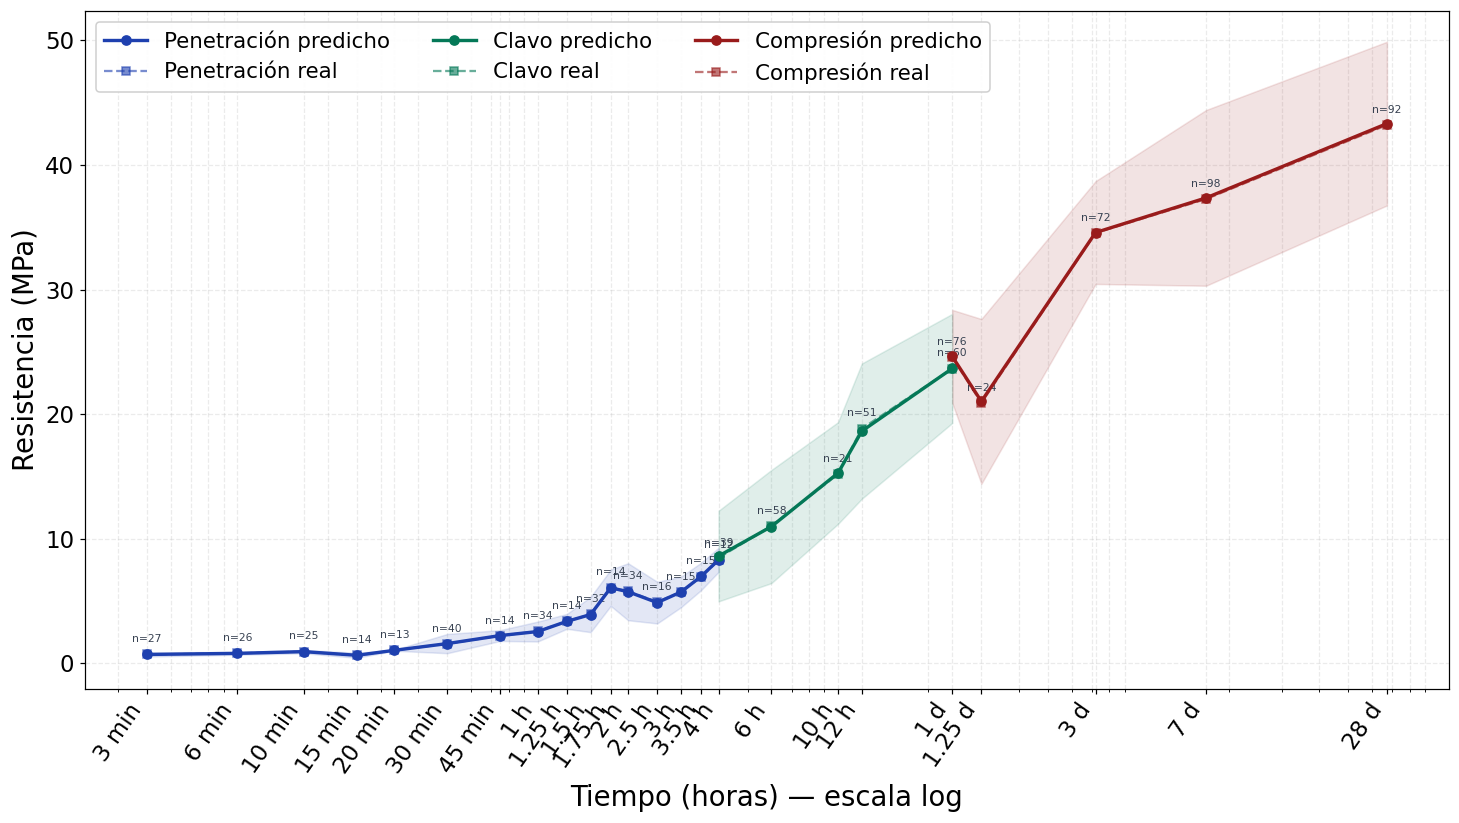

    figura guardada: figuras/fig_2_curva_por_punto_rf.pdf


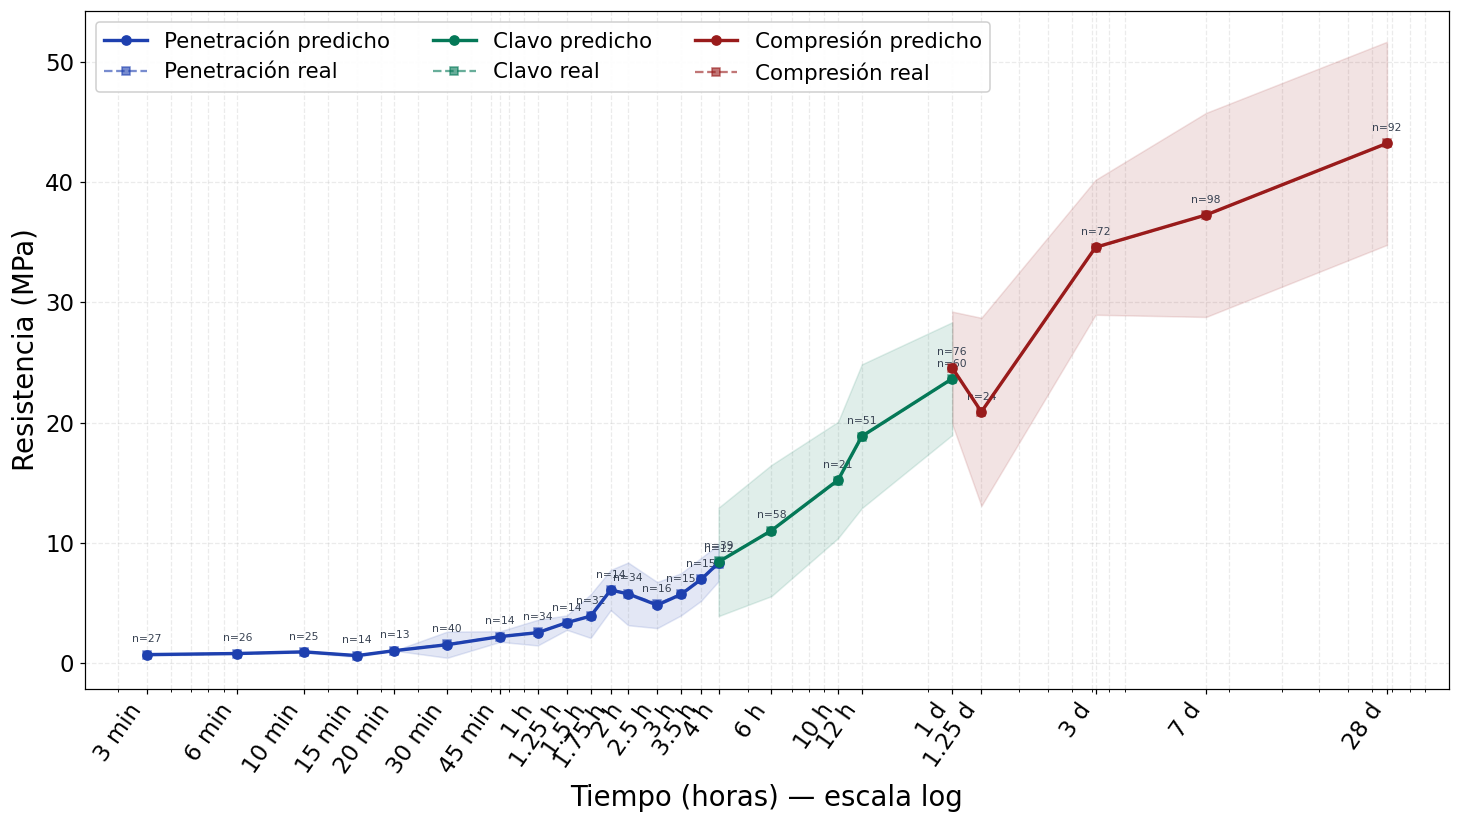

    figura guardada: figuras/fig_2_curva_por_punto_xgb.pdf


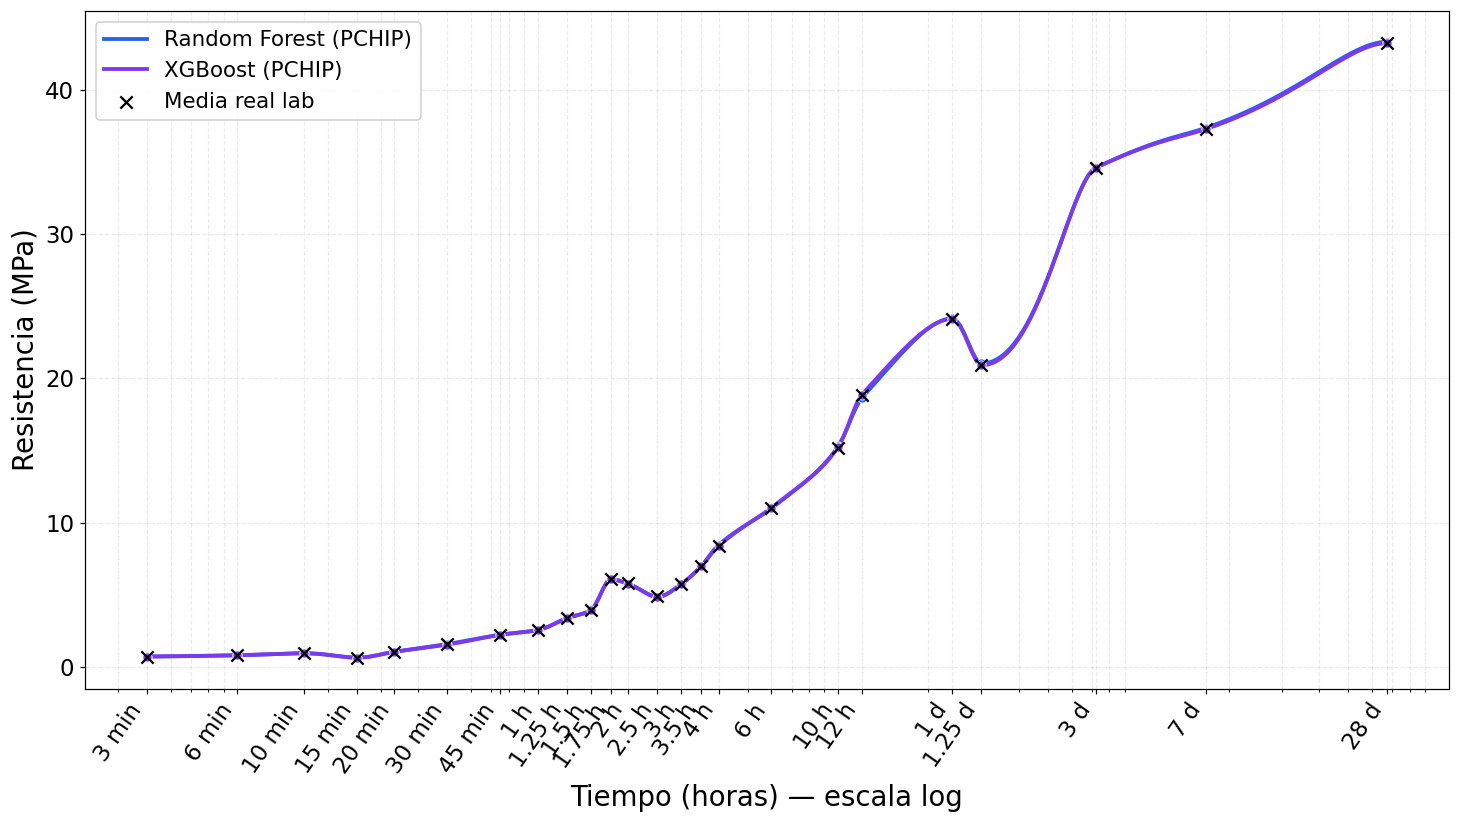

    figura guardada: figuras/fig_2_curva_pchip.pdf


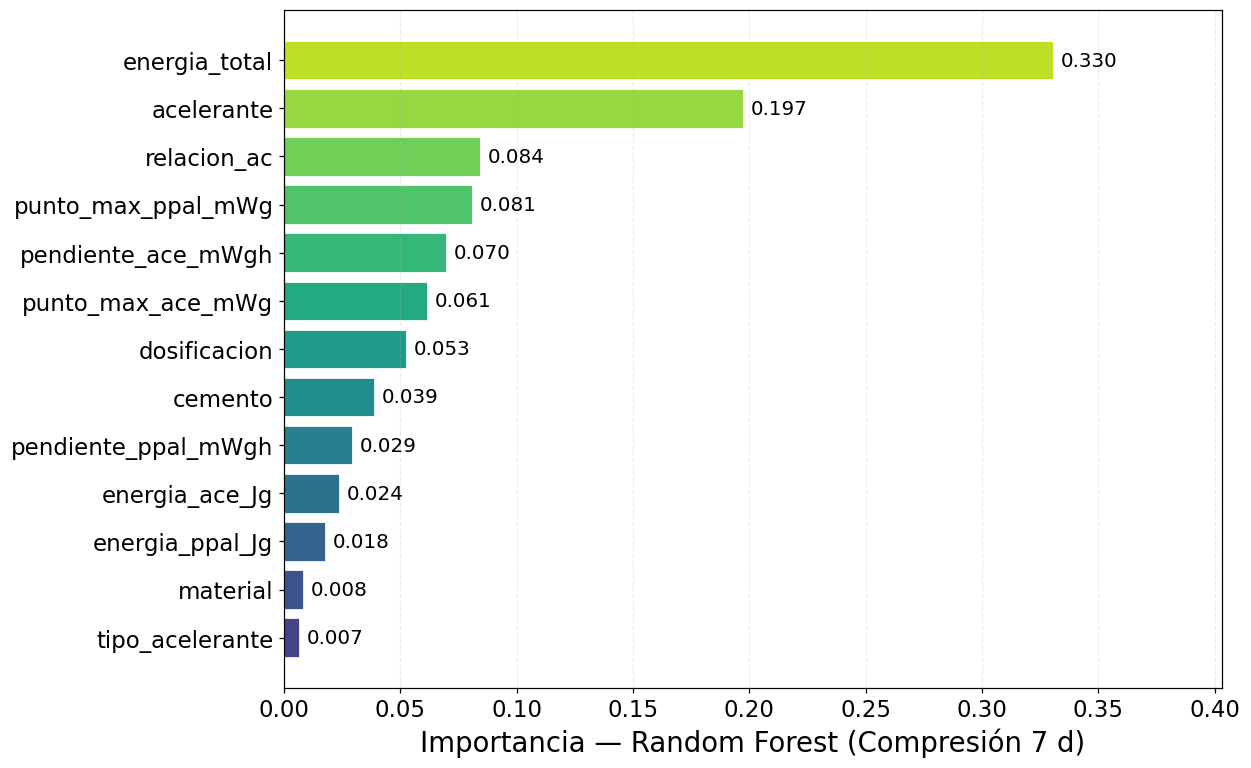

    figura guardada: figuras/fig_2_importancias_rf.pdf


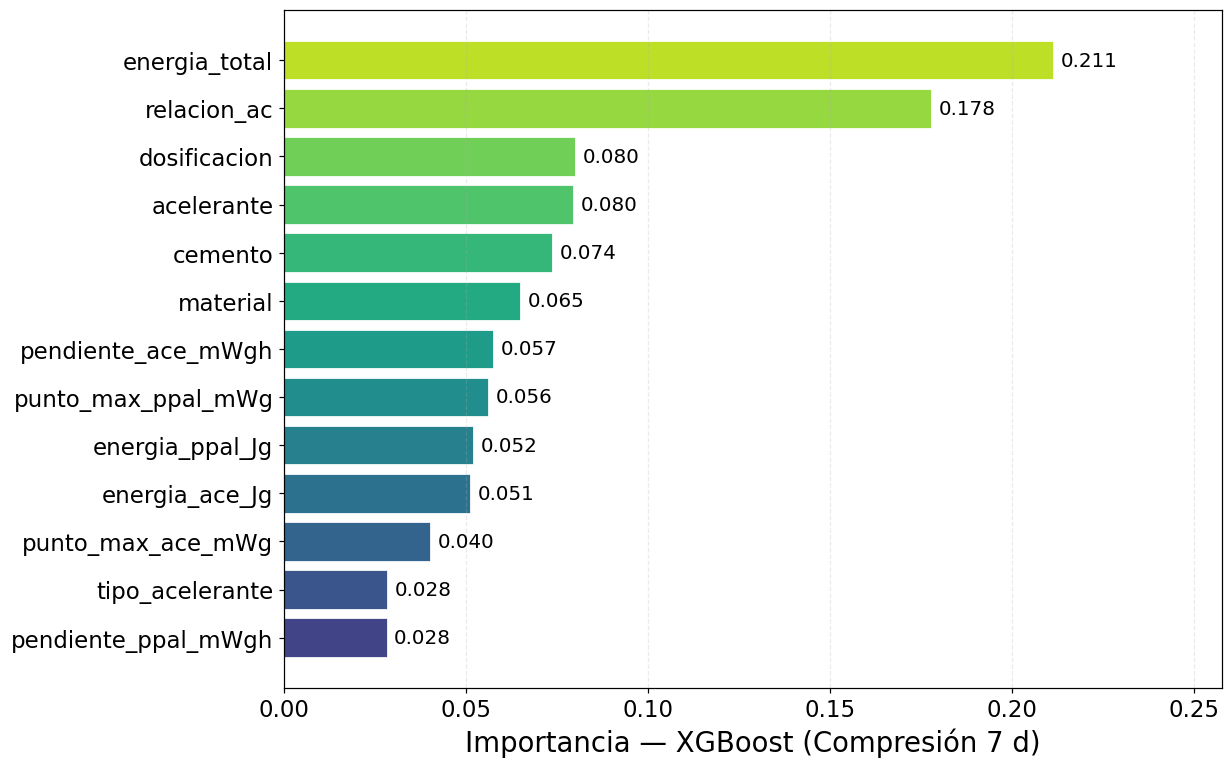

    figura guardada: figuras/fig_2_importancias_xgb.pdf

  Exportados: modelo_porpunto_rf.pkl, modelo_porpunto_xgb.pkl


In [4]:
# ==============================================================================
# CELDA 2 — MODELOS POR PUNTO TEMPORAL (Random Forest y XGBoost)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def ajustador_por_punto(modelo_base):
    def ajustar(tr, te):
        pred = np.full(len(te['y']), np.nan)
        for horas, _, serie in PUNTOS:
            m_tr = mascara_punto(tr, horas, serie)
            m_te = mascara_punto(te, horas, serie)
            if not m_te.any() or m_tr.sum() < CFG_MIN_ENTRENO_PUNTO:
                continue
            m = clone(modelo_base)
            m.fit(tr['X'][m_tr], tr['y'][m_tr])
            pred[m_te] = m.predict(te['X'][m_te])
        return pred
    return ajustar

# ── 1. Validación ───────────────────────────────────────────────────────────
print("=" * 78)
print("  CELDA 2 — MODELOS POR PUNTO TEMPORAL")
print("=" * 78)
registrar('RF-porPunto',
          para_cada_particion(ajustador_por_punto(RandomForestRegressor(**CFG_PARAMS_RF)),
                              etiqueta='RF-porPunto'))
registrar('XGB-porPunto',
          para_cada_particion(ajustador_por_punto(XGBRegressor(**CFG_PARAMS_XGB)),
                              etiqueta='XGB-porPunto'))

# ── 2. Tablas de resultados ─────────────────────────────────────────────────
METODOS_C2 = ['RF-porPunto', 'XGB-porPunto']
MET_PUNTO_C2, MEDIA_C2, PUNTOS_COMUNES_C2 = imprimir_tabla_por_punto(
    METODOS_C2, 'MODELOS POR PUNTO · R² y MAE de cada punto')
MASC_C2 = imprimir_tablas_mascaras(METODOS_C2, 'MODELOS POR PUNTO')

# ── 3. Modelos definitivos con el 100 % (para la app y las figuras) ─────────
MODELOS_PUNTO = {'Random Forest': {}, 'XGBoost': {}}
for horas, col, serie in PUNTOS:
    m = df[col].notna()
    X_col = X_IMP_APP[m.to_numpy()]
    y_col = df.loc[m, col].to_numpy(float)
    for etiqueta, modelo in [('Random Forest', RandomForestRegressor(**CFG_PARAMS_RF)),
                             ('XGBoost',       XGBRegressor(**CFG_PARAMS_XGB))]:
        mm = clone(modelo)
        mm.fit(X_col, y_col)
        MODELOS_PUNTO[etiqueta][col] = {
            'modelo': mm, 'horas': float(horas), 'serie': serie,
            'n': int(m.sum()), 'importancias': mm.feature_importances_,
        }
_sin_validar = [c for _, c, _ in PUNTOS if MET_PUNTO_C2['RF-porPunto'][c] is None]
print(f"\n  Modelos definitivos: {len(PUNTOS)} puntos x 2 algoritmos, "
      f"entrenados con el 100 % de las mezclas")
if _sin_validar:
    print(f"    sin métrica de validación (se exportan marcados): "
          f"{', '.join(_sin_validar)}")

# ── 4. Figuras ──────────────────────────────────────────────────────────────
EDADES_MEDIDAS = np.unique(T_ALL)

def _bloques_por_serie(etiqueta):
    d = MODELOS_PUNTO[etiqueta]
    bloques = []
    for serie in ['Penetración', 'Clavo', 'Compresión']:
        cols = [c for _, c, s in PUNTOS if s == serie]
        if not cols:
            continue
        b = {'serie': serie, 'horas': [], 'media_pred': [], 'std_pred': [],
             'media_real': [], 'n': []}
        for c in cols:
            m = df[c].notna()
            pred = d[c]['modelo'].predict(X_IMP_APP[m.to_numpy()])
            real = df.loc[m, c].to_numpy(float)
            b['horas'].append(d[c]['horas'])
            b['media_pred'].append(float(pred.mean()))
            b['std_pred'].append(float(pred.std()))
            b['media_real'].append(float(real.mean()))
            b['n'].append(int(m.sum()))
        bloques.append(b)
    return bloques

for etiqueta, archivo in [('Random Forest', 'fig_2_curva_por_punto_rf'),
                          ('XGBoost',       'fig_2_curva_por_punto_xgb')]:
    figura_curva_por_serie(
        _bloques_por_serie(etiqueta), archivo,
        f'{etiqueta} por punto temporal: curva con banda ±1σ',
        marcas_horas=EDADES_MEDIDAS)

def _puntos_medios(etiqueta):
    d = MODELOS_PUNTO[etiqueta]
    horas  = np.array([d[c]['horas'] for _, c, _ in PUNTOS], float)
    medias = np.array([float(d[c]['modelo']
                             .predict(X_IMP_APP[df[c].notna().to_numpy()]).mean())
                       for _, c, _ in PUNTOS])
    return horas, medias

_h_rf,  _v_rf  = _puntos_medios('Random Forest')
_h_xgb, _v_xgb = _puntos_medios('XGBoost')

figura_pchip(
    [('Random Forest', _h_rf,  _v_rf,  COLOR['RF-porPunto']),
     ('XGBoost',       _h_xgb, _v_xgb, COLOR['XGB-porPunto'])],
    'fig_2_curva_pchip',
    'Curva resistencia-tiempo suavizada (PCHIP) — RF vs XGBoost',
    reales=(DATOS_LAB['horas'].to_numpy(float),
            DATOS_LAB['media'].to_numpy(float)),
    marcas_horas=EDADES_MEDIDAS)

for etiqueta, archivo in [('Random Forest', 'fig_2_importancias_rf'),
                          ('XGBoost',       'fig_2_importancias_xgb')]:
    _ref = max(MODELOS_PUNTO[etiqueta], key=lambda c: MODELOS_PUNTO[etiqueta][c]['n'])
    _d_ref = MODELOS_PUNTO[etiqueta][_ref]
    figura_importancias(
        CFG_FEATURES, _d_ref['importancias'], archivo,
        f'{etiqueta}: variables importantes ({_d_ref["serie"]} '
        f'{etiqueta_tiempo(_d_ref["horas"])}, n={_d_ref["n"]})',
        etiqueta_eje=(f'Importancia — {etiqueta} '
                      f'({_d_ref["serie"]} {etiqueta_tiempo(_d_ref["horas"])})'))

# ── 5. Exportación ──────────────────────────────────────────────────────────
import joblib

def _paquete_por_punto(etiqueta):
    d = MODELOS_PUNTO[etiqueta]
    orden = [c for _, c, _ in PUNTOS]
    nombre_registro = 'RF-porPunto' if etiqueta == 'Random Forest' else 'XGB-porPunto'
    met = resumen_metricas(nombre_registro)
    met_punto = MET_PUNTO_C2[nombre_registro]
    return {
        'tipo': etiqueta, 'estrategia': 'por_punto',
        'resultados': {c: {'modelo': d[c]['modelo'], 'horas': d[c]['horas'],
                           'serie': d[c]['serie'],
                           'validado': met_punto[c] is not None,
                           'metricas': met_punto[c]} for c in orden},
        'orden': orden,
        'imputer': IMPUTADOR_APP, 'features_ok': CFG_FEATURES,
        'factorizacion': FACTORIZACION_APP, 'combos_validos': combos_validos,
        'datos_reales': DATOS_REALES_APP,
        'metricas': {k: v for k, v in met.items() if v is not None},
        'metricas_por_punto_mascara': {k: v for k, v in resumen_metricas_por_punto(nombre_registro).items()
                                       if v is not None},
        'r2_medio_puntos': MEDIA_C2[nombre_registro],
        'protocolo': f'{len(PRED[nombre_registro])} particiones 80/20 por mezcla',
    }

joblib.dump(_paquete_por_punto('Random Forest'), 'modelo_porpunto_rf.pkl')
joblib.dump(_paquete_por_punto('XGBoost'),       'modelo_porpunto_xgb.pkl')
print("\n  Exportados: modelo_porpunto_rf.pkl, modelo_porpunto_xgb.pkl")

  CELDA 2.B — MODELO ÚNICO CON EL TIEMPO COMO VARIABLE
  Monotonía en el modelo: no (se impone al dibujar)
  Objetivo: resistencia en MPa
    registrado: RF-conTiempo  (15 particiones)
    registrado: XGB-conTiempo  (15 particiones)

  MODELO ÚNICO CON EL TIEMPO · R² y MAE de cada punto
                                   |   RF-conTiempo    |   XGB-conTiempo   |     Base
      Edad Serie           n Part. |       R²      MAE |       R²      MAE |       R²
---------------------------------------------------------------------------------------
     3 min Penetración    27    14 |    0.018     0.16 |  -18.824     0.69 |   -0.443
     6 min Penetración    26    13 |   -0.539     0.17 |  -22.710     0.62 |   -0.816
    10 min Penetración    25    13 |   -0.331     0.17 |  -14.306     0.63 |   -0.541
    15 min Penetración    14     0 |        —        — |        —        — |        —
    20 min Penetración    13     4 |   -1.802     0.10 | -286.241     0.95 |   -0.301
    30 min Penetración

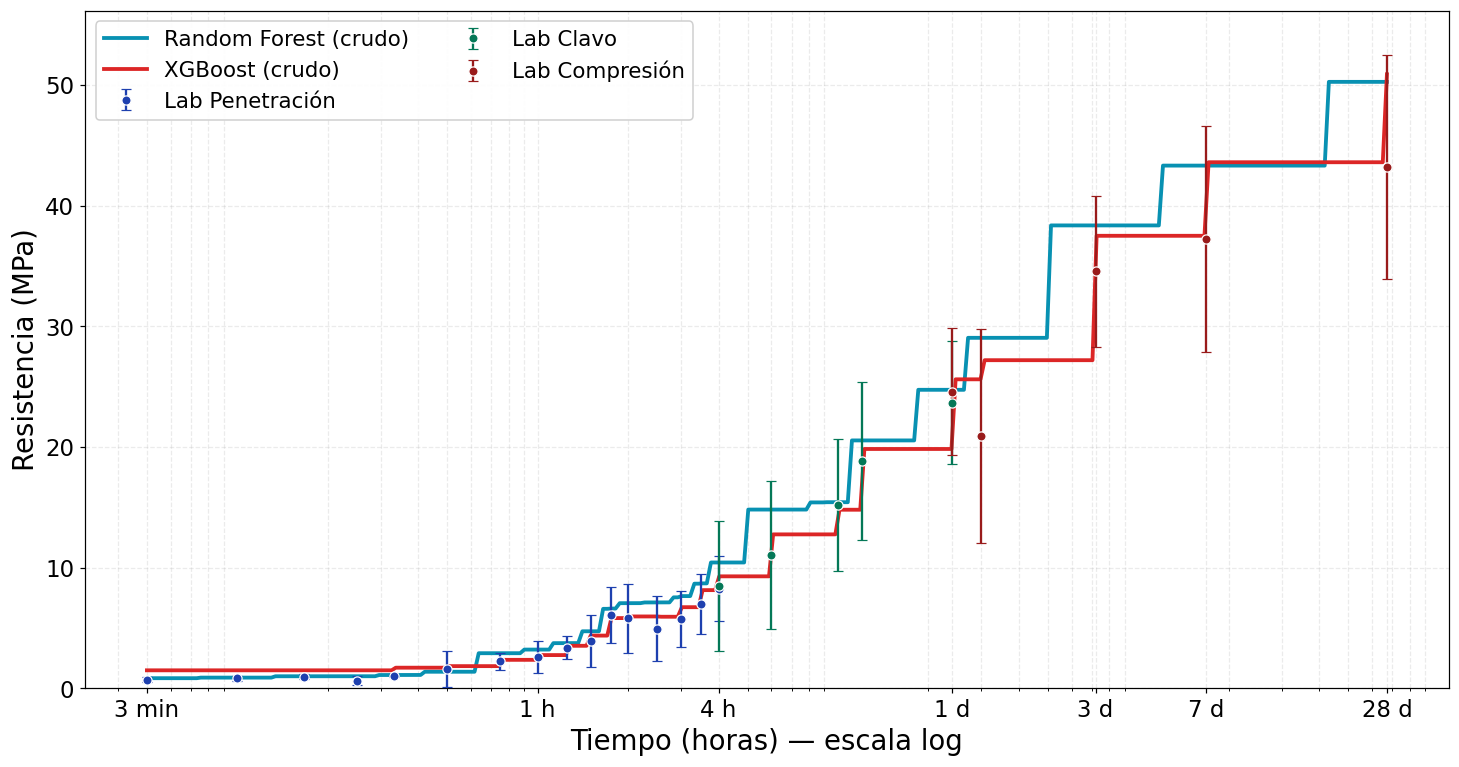

    figura guardada: figuras/fig_2B_curva_cruda.pdf


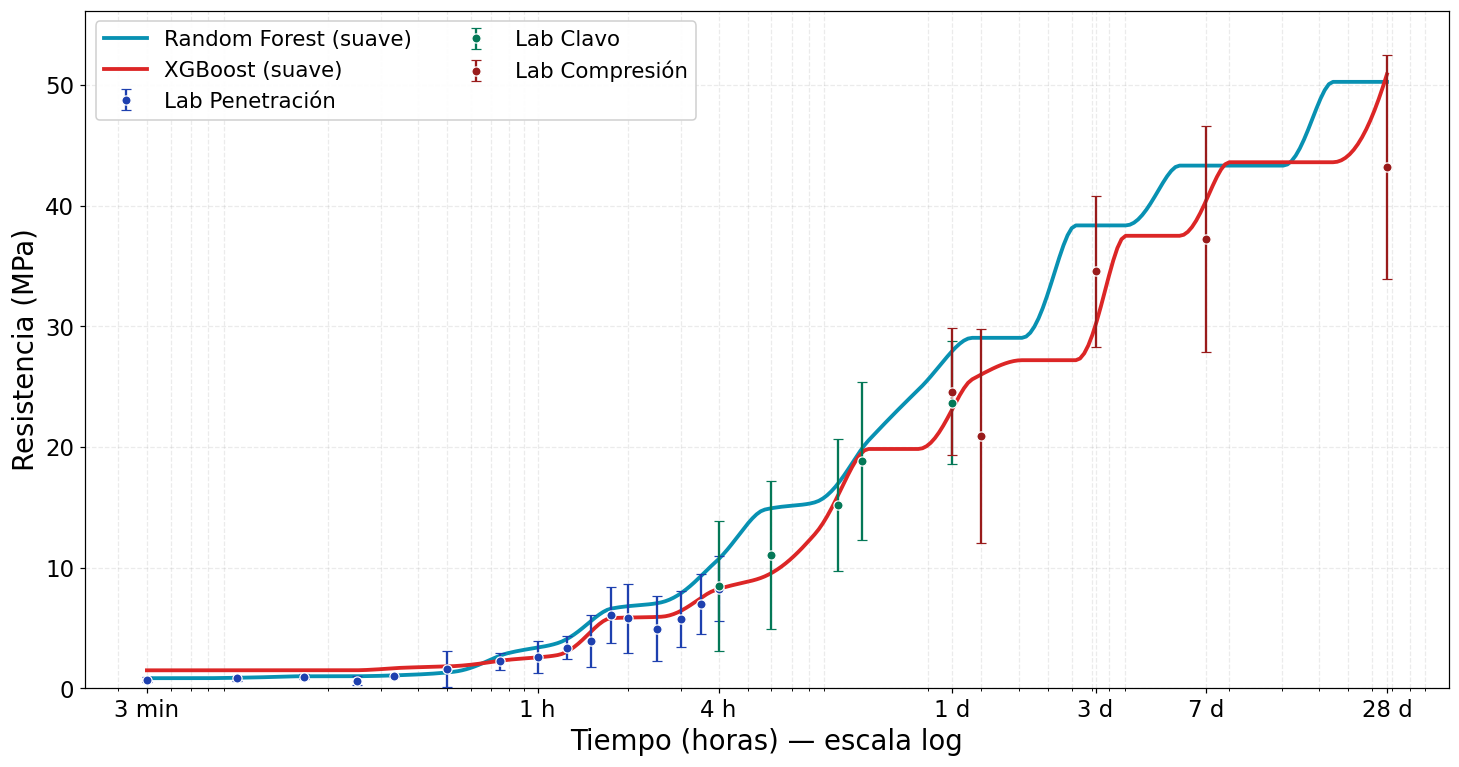

    figura guardada: figuras/fig_2B_curva_suave.pdf


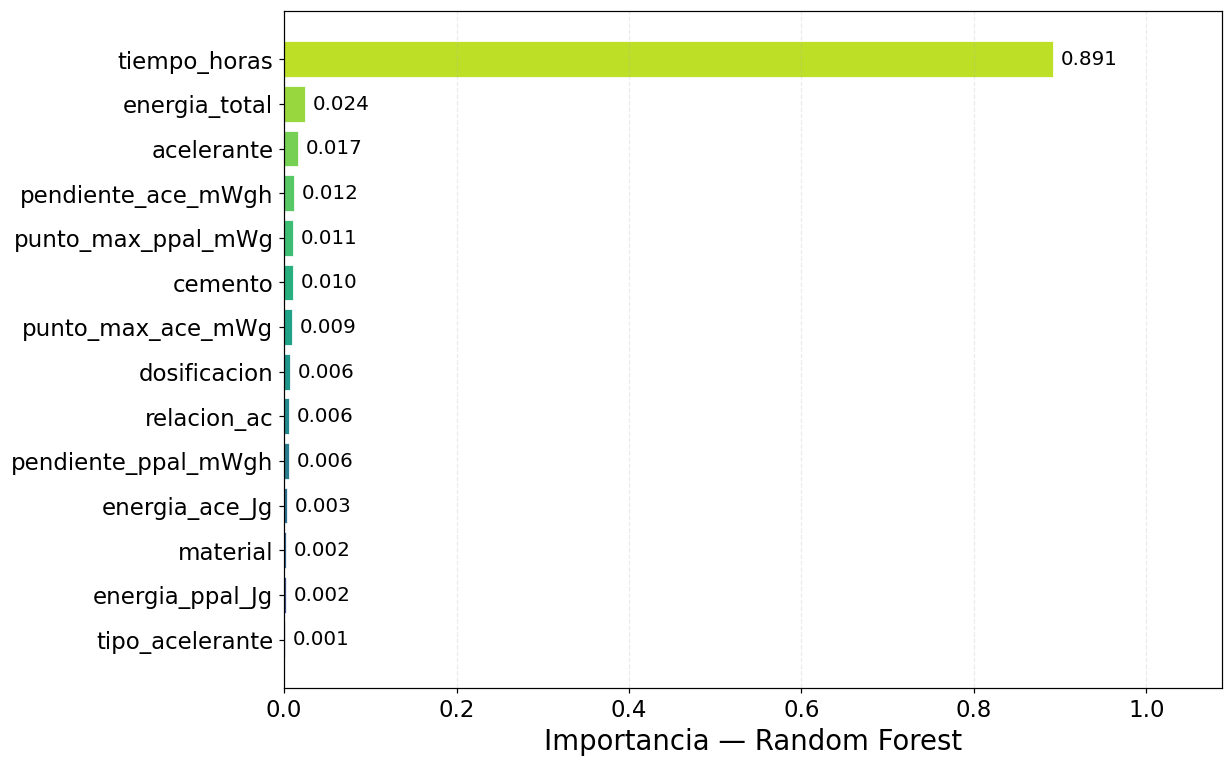

    figura guardada: figuras/fig_2B_importancias_rf.pdf


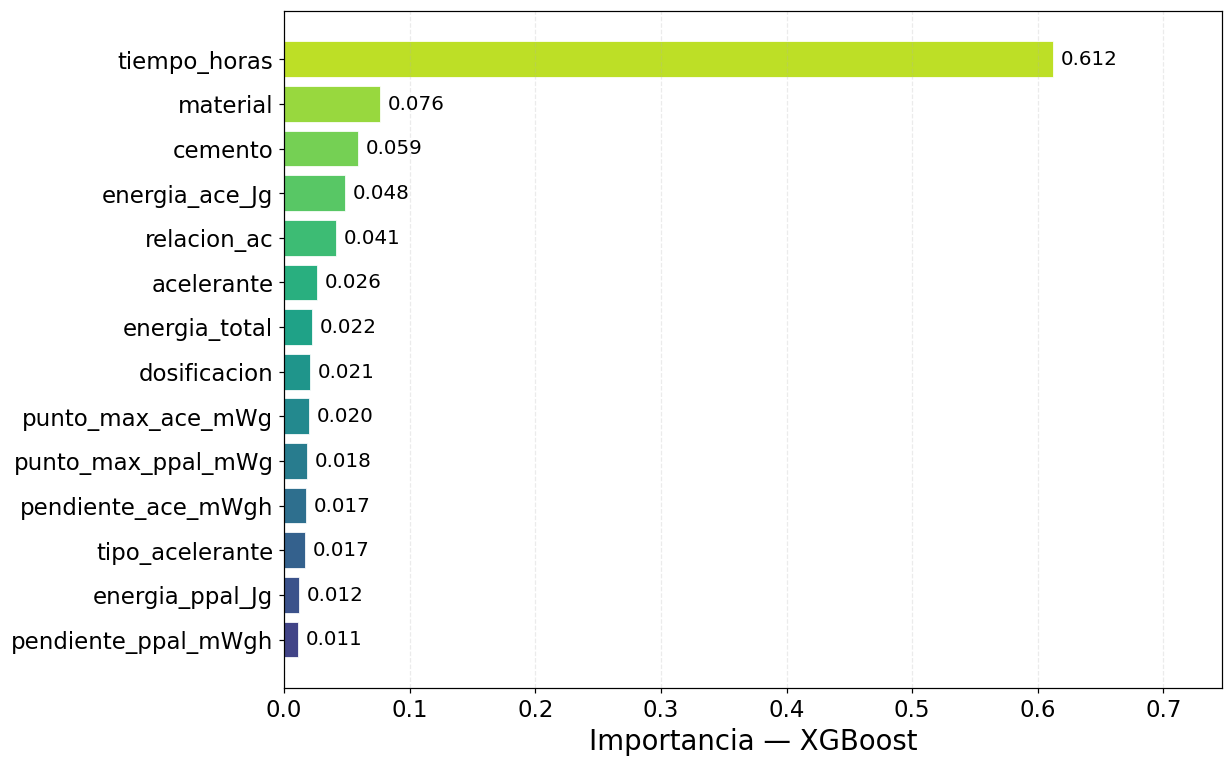

    figura guardada: figuras/fig_2B_importancias_xgb.pdf

  Exportados: modelo_hormigon_rf.pkl, modelo_hormigon_xgb.pkl (los que consume la aplicación)


In [5]:
# ==============================================================================
# CELDA 2.B — MODELO ÚNICO CON EL TIEMPO COMO VARIABLE
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

CFG_MONOTONIA_MODELO = False
CFG_N_SUAVIZADO      = 25
N_VARS = len(CFG_FEATURES) + 1
CFG_MONOTONIA = tuple([0] * (N_VARS - 1) + [1])

def construir_rf_unico():
    if not CFG_MONOTONIA_MODELO:
        return envolver_objetivo(RandomForestRegressor(**CFG_PARAMS_RF))
    try:
        return envolver_objetivo(RandomForestRegressor(monotonic_cst=list(CFG_MONOTONIA),
                                               **CFG_PARAMS_RF))
    except TypeError:
        print("    aviso: esta versión de scikit-learn no admite monotonic_cst; "
              "el Random Forest queda sin restricción")
        return envolver_objetivo(RandomForestRegressor(**CFG_PARAMS_RF))

def construir_xgb_unico():
    if not CFG_MONOTONIA_MODELO:
        return envolver_objetivo(XGBRegressor(**CFG_PARAMS_XGB))
    return envolver_objetivo(XGBRegressor(monotone_constraints=CFG_MONOTONIA, **CFG_PARAMS_XGB))

def ajustador_con_tiempo(constructor):
    def ajustar(tr, te):
        m = constructor()
        m.fit(np.column_stack([tr['X'], tr['t']]), tr['y'])
        return m.predict(np.column_stack([te['X'], te['t']]))
    return ajustar

# ── 1. Validación ───────────────────────────────────────────────────────────
print("=" * 78)
print("  CELDA 2.B — MODELO ÚNICO CON EL TIEMPO COMO VARIABLE")
print("=" * 78)
print(f"  Monotonía en el modelo: "
      f"{'sí (restricción)' if CFG_MONOTONIA_MODELO else 'no (se impone al dibujar)'}")
print(f"  Objetivo: {'log(1 + resistencia)' if CFG_OBJETIVO_LOG else 'resistencia en MPa'}")

registrar('RF-conTiempo',
          para_cada_particion(ajustador_con_tiempo(construir_rf_unico),
                              etiqueta='RF-conTiempo'))
registrar('XGB-conTiempo',
          para_cada_particion(ajustador_con_tiempo(construir_xgb_unico),
                              etiqueta='XGB-conTiempo'))

# ── 2. Tablas de resultados ─────────────────────────────────────────────────
METODOS_C2B = ['RF-conTiempo', 'XGB-conTiempo']
MET_PUNTO_C2B, MEDIA_C2B, PUNTOS_COMUNES_C2B = imprimir_tabla_por_punto(
    METODOS_C2B, 'MODELO ÚNICO CON EL TIEMPO · R² y MAE de cada punto')
print("  Aquí un ÚNICO modelo cubre todas las edades: el desglose dice en qué")
print("  tramo del endurecimiento acierta y en cuál no, no qué modelo se usó.")

MASC_C2B = imprimir_tablas_mascaras(METODOS_C2B, 'MODELO ÚNICO CON EL TIEMPO')

# ── Comparación con la Celda 2 (sólo entran los métodos ya ejecutados) ──
imprimir_comparacion_por_punto(
    ['RF-porPunto', 'XGB-porPunto', 'RF-conTiempo', 'XGB-conTiempo'],
    'COMPARACIÓN POR PUNTO · Celda 2 frente a Celda 2.B')

# ── 3. Modelos definitivos con el 100 % ─────────────────────────────────────
MODELO_UNICO = {}
MODELO_UNICO['Random Forest'] = construir_rf_unico().fit(X_APP_LARGO, Y_APP_LARGO)
MODELO_UNICO['XGBoost']       = construir_xgb_unico().fit(X_APP_LARGO, Y_APP_LARGO)
print(f"\n  Modelos definitivos entrenados con {len(Y_APP_LARGO)} ensayos "
      f"de {N_MEZCLAS_USADAS} mezclas")


def suavizar(valores, horas, n_puntos=CFG_N_SUAVIZADO):
    horas   = np.asarray(horas, float)
    valores = np.asarray(valores, float)
    idx   = np.linspace(0, len(horas) - 1, n_puntos, dtype=int)
    h_sub = horas[idx]
    v_sub = np.maximum.accumulate(valores[idx])
    return np.clip(PchipInterpolator(h_sub, v_sub)(horas), 0, None)


# ── 4. Figuras ──────────────────────────────────────────────────────────────
CRUDAS = {}
for etiqueta, clave in [('Random Forest', 'RF-conTiempo'), ('XGBoost', 'XGB-conTiempo')]:
    CRUDAS[etiqueta] = MODELO_UNICO[etiqueta].predict(X_CURVA)
    descensos = int((np.diff(CRUDAS[etiqueta]) < -1e-9).sum())
    print(f"    {etiqueta}: tramos decrecientes en la curva cruda = {descensos} "
          f"de {len(HORAS_EJE) - 1}")

figura_curva(
    [('Random Forest (crudo)', HORAS_EJE, CRUDAS['Random Forest'],
      COLOR['RF-conTiempo'], '-'),
     ('XGBoost (crudo)', HORAS_EJE, CRUDAS['XGBoost'],
      COLOR['XGB-conTiempo'], '-')],
    'fig_2B_curva_cruda')

figura_curva(
    [('Random Forest (suave)', HORAS_EJE, suavizar(CRUDAS['Random Forest'], HORAS_EJE),
      COLOR['RF-conTiempo'], '-'),
     ('XGBoost (suave)', HORAS_EJE, suavizar(CRUDAS['XGBoost'], HORAS_EJE),
      COLOR['XGB-conTiempo'], '-')],
    'fig_2B_curva_suave')

for etiqueta, archivo in [('Random Forest', 'fig_2B_importancias_rf'),
                          ('XGBoost',       'fig_2B_importancias_xgb')]:
    figura_importancias(NOMBRES_VARIABLES,
                        importancias_de(MODELO_UNICO[etiqueta]),
                        archivo,
                        f'{etiqueta}: importancia de variables (con el tiempo)',
                        etiqueta_eje=f'Importancia — {etiqueta}')

# ── 5. Exportación para la aplicación web ───────────────────────────────────
import joblib

def _paquete_unico(etiqueta, clave_registro):
    met = resumen_metricas(clave_registro)
    return {
        'tipo': etiqueta, 'estrategia': 'tiempo_como_variable',
        'modelo_unico': MODELO_UNICO[etiqueta],
        'imputer': IMPUTADOR_APP, 'features_ok': CFG_FEATURES,
        'nombres_variables': NOMBRES_VARIABLES,
        'medianas': MEDIANAS_APP,
        'factorizacion': FACTORIZACION_APP, 'combos_validos': combos_validos,
        'datos_reales': DATOS_REALES_APP,
        'metricas': {k: v for k, v in met.items() if v is not None},
        'metricas_por_punto_mascara': {k: v for k, v in resumen_metricas_por_punto(clave_registro).items()
                                       if v is not None},
        'r2_test': met['Global']['r2'] if met['Global'] else None,
        'r2_medio_puntos': MEDIA_C2B[clave_registro],
        'metricas_por_punto': MET_PUNTO_C2B[clave_registro],
        'protocolo': f'{len(PRED[clave_registro])} particiones 80/20 por mezcla',
        'monotonia_modelo': CFG_MONOTONIA_MODELO,
        'objetivo_log': CFG_OBJETIVO_LOG,
        'suavizado': {'metodo': 'submuestreo + maximum.accumulate + pchip',
                      'n_puntos': CFG_N_SUAVIZADO},
    }

joblib.dump(_paquete_unico('Random Forest', 'RF-conTiempo'), 'modelo_hormigon_rf.pkl')
joblib.dump(_paquete_unico('XGBoost',       'XGB-conTiempo'), 'modelo_hormigon_xgb.pkl')
print("\n  Exportados: modelo_hormigon_rf.pkl, modelo_hormigon_xgb.pkl "
      "(los que consume la aplicación)")

  CELDA 2.C — MODELOS POR TRAMO TEMPORAL
    Penetración    3 min – 4 h      345 ensayos
    Clavo            4 h – 1 d      229 ensayos
    Compresión       1 d – 28 d     362 ensayos
  Objetivo: resistencia en MPa
    registrado: RF-porTramo  (15 particiones)
    registrado: XGB-porTramo  (15 particiones)

  MODELOS POR TRAMO · R² y MAE de cada punto
                                   |    RF-porTramo    |   XGB-porTramo    |     Base
      Edad Serie           n Part. |       R²      MAE |       R²      MAE |       R²
---------------------------------------------------------------------------------------
     3 min Penetración    27    14 |    0.075     0.15 |   -0.705     0.20 |   -0.443
     6 min Penetración    26    13 |   -0.604     0.18 |   -1.515     0.20 |   -0.816
    10 min Penetración    25    13 |   -0.354     0.17 |   -1.314     0.20 |   -0.541
    15 min Penetración    14     0 |        —        — |        —        — |        —
    20 min Penetración    13     4 |   -1

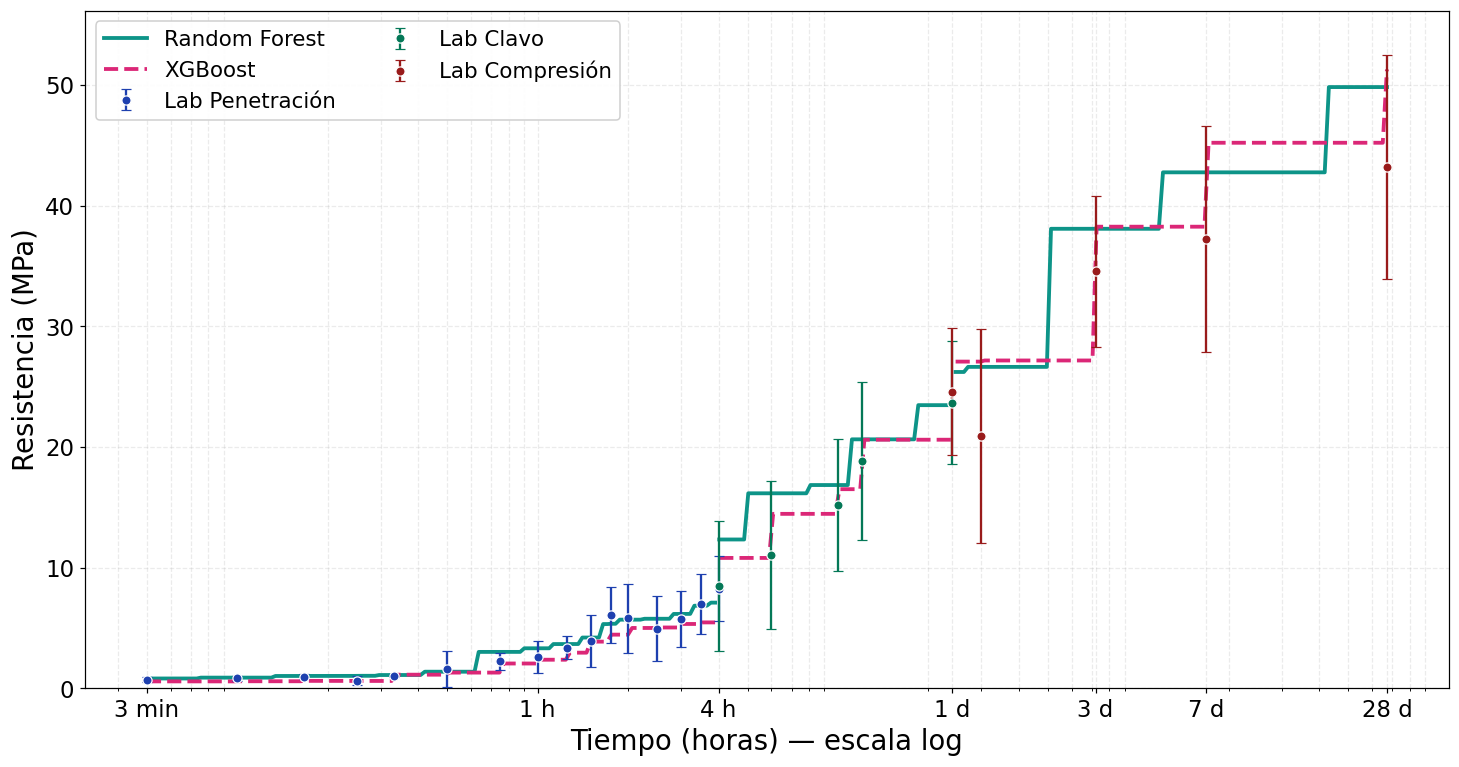

    figura guardada: figuras/fig_2C_curva_tramos.pdf


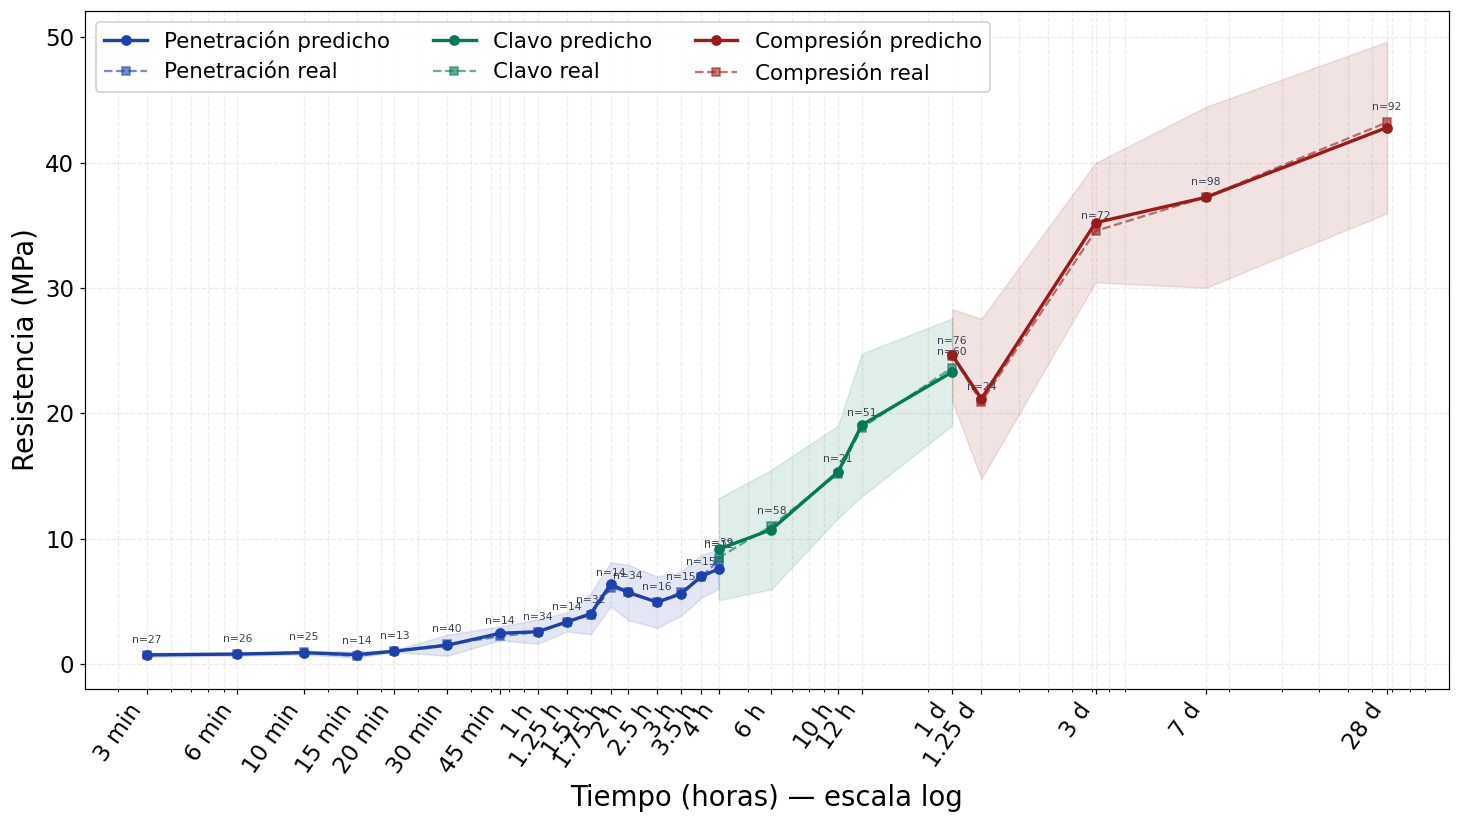

    figura guardada: figuras/fig_2C_curva_por_punto_rf.pdf


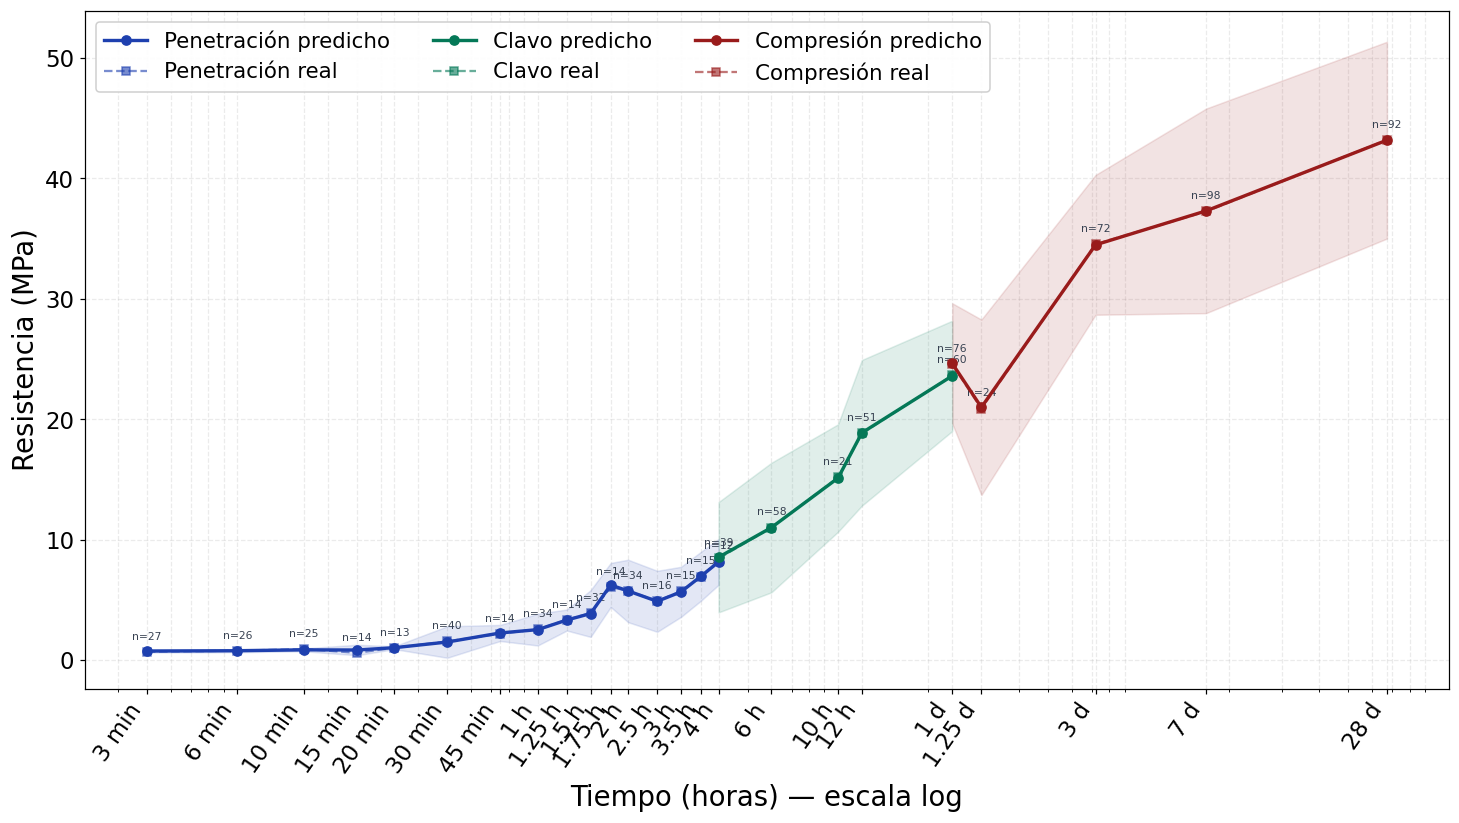

    figura guardada: figuras/fig_2C_curva_por_punto_xgb.pdf


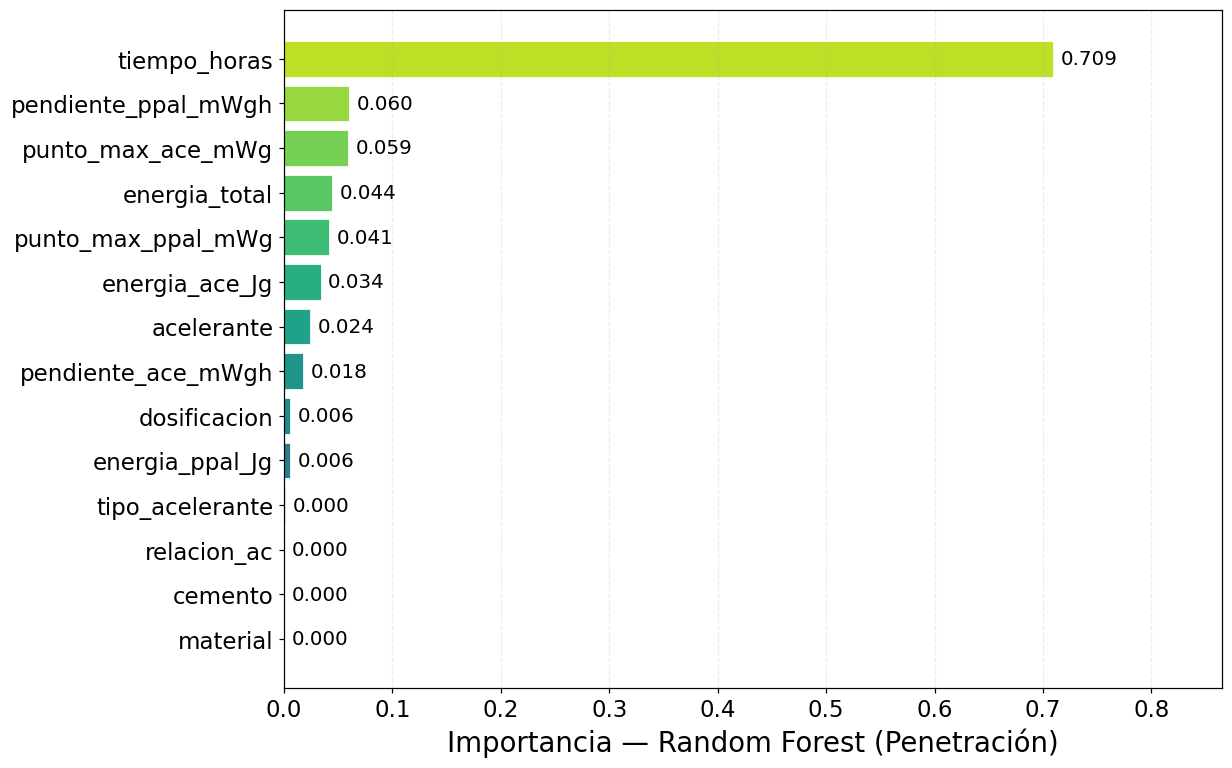

    figura guardada: figuras/fig_2C_importancias_rf_penetracion.pdf


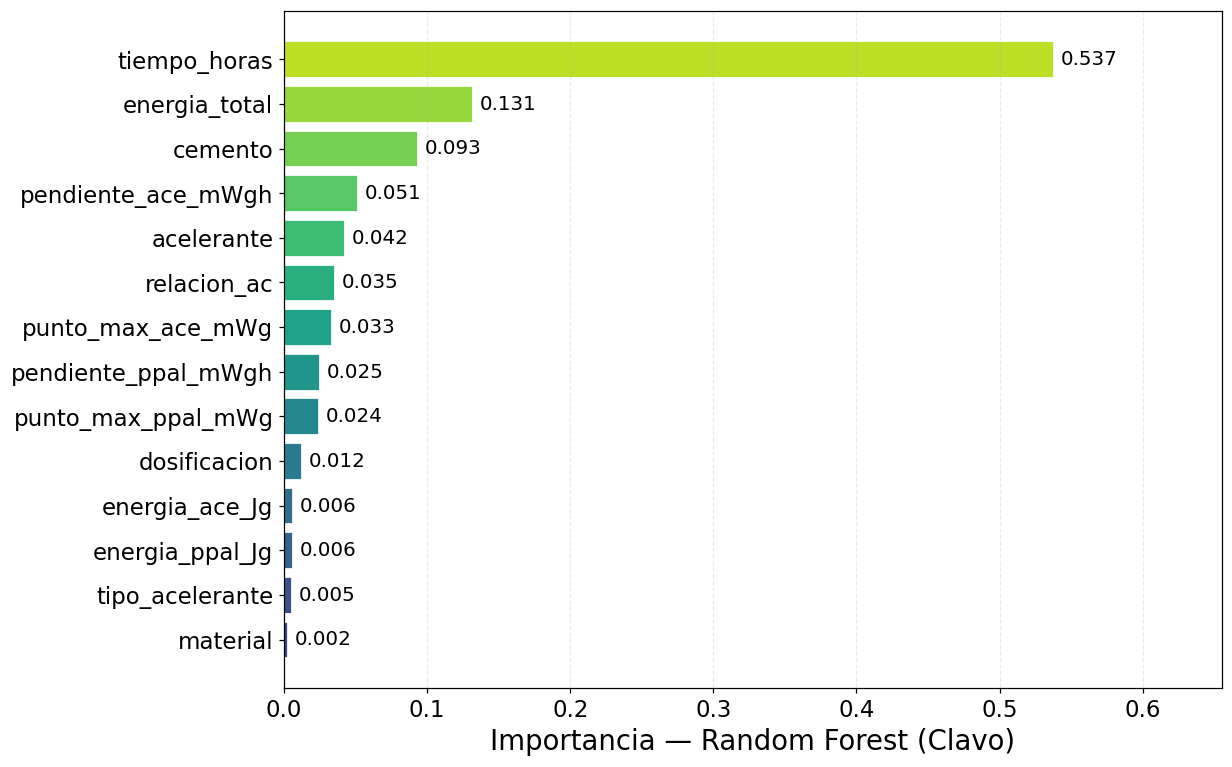

    figura guardada: figuras/fig_2C_importancias_rf_clavo.pdf


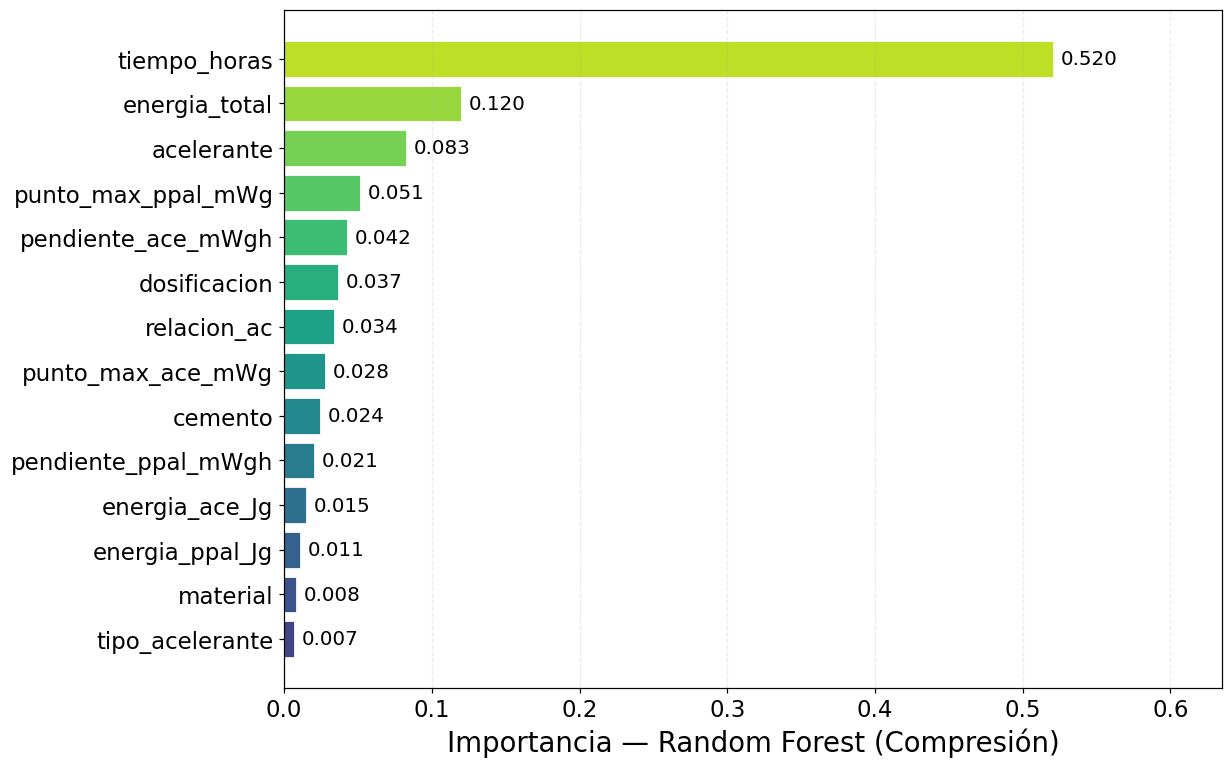

    figura guardada: figuras/fig_2C_importancias_rf_compresion.pdf


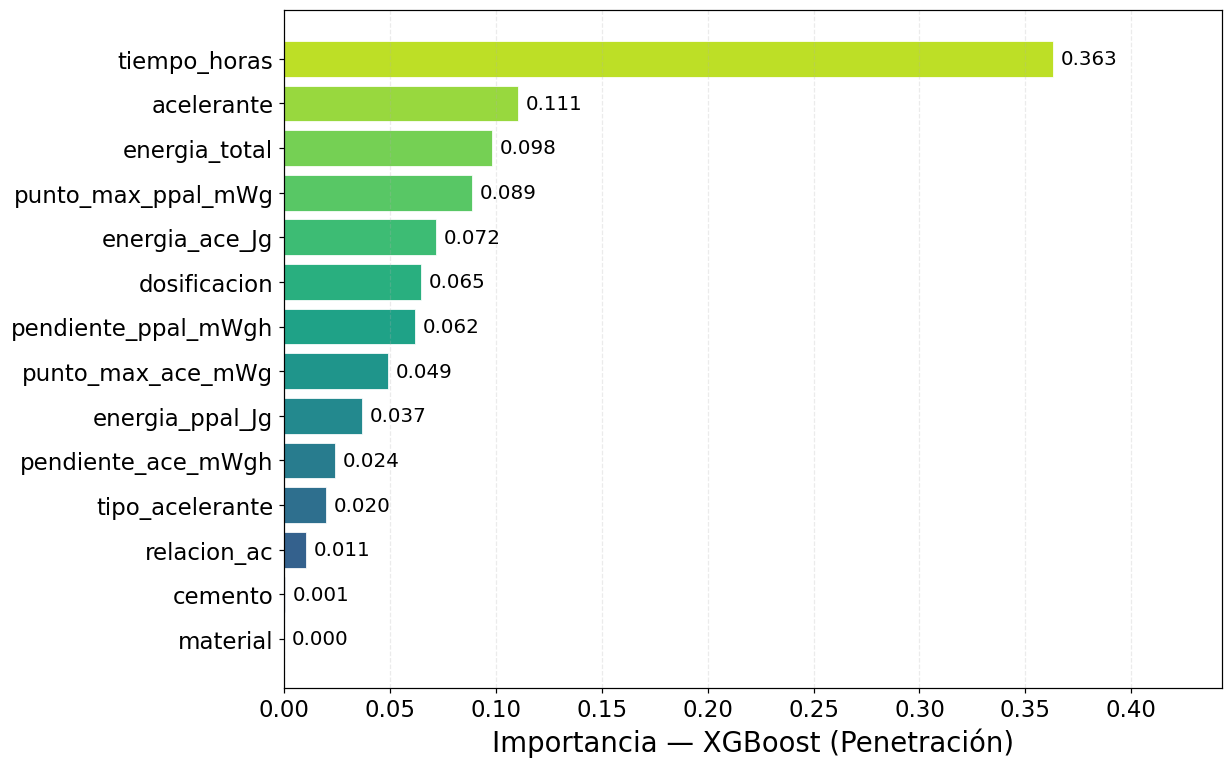

    figura guardada: figuras/fig_2C_importancias_xgb_penetracion.pdf


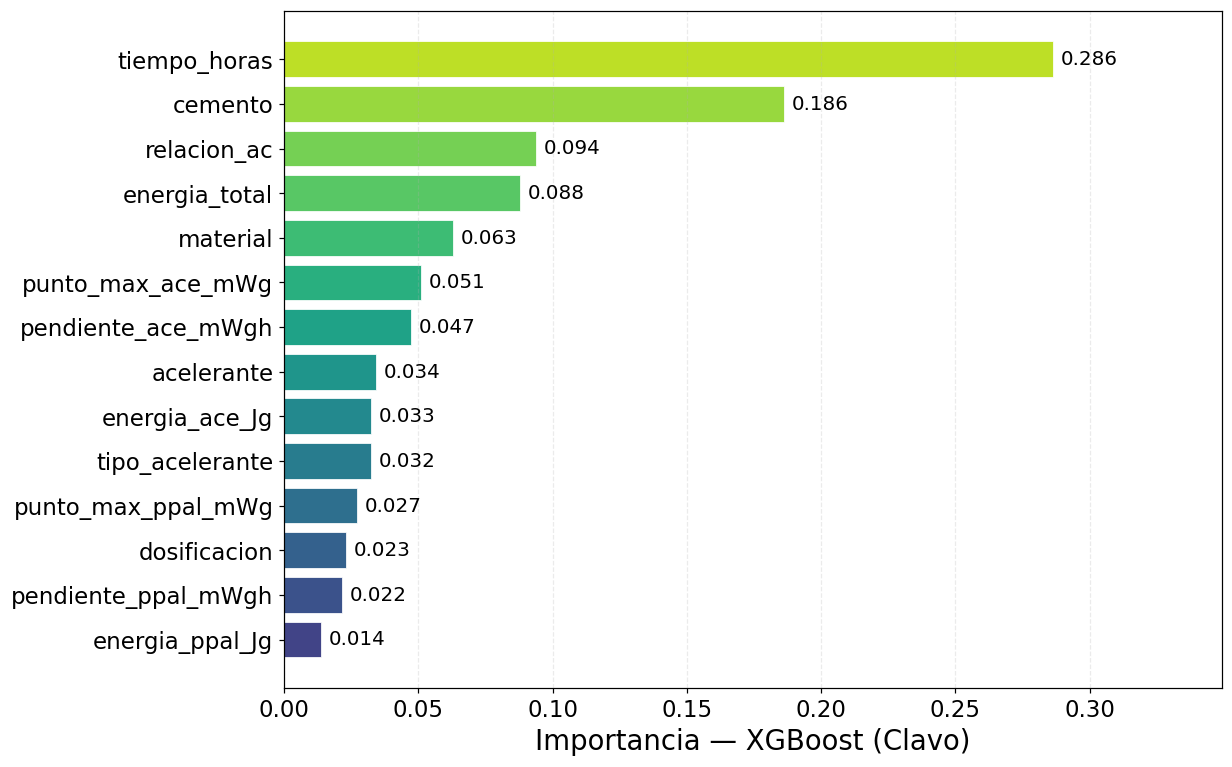

    figura guardada: figuras/fig_2C_importancias_xgb_clavo.pdf


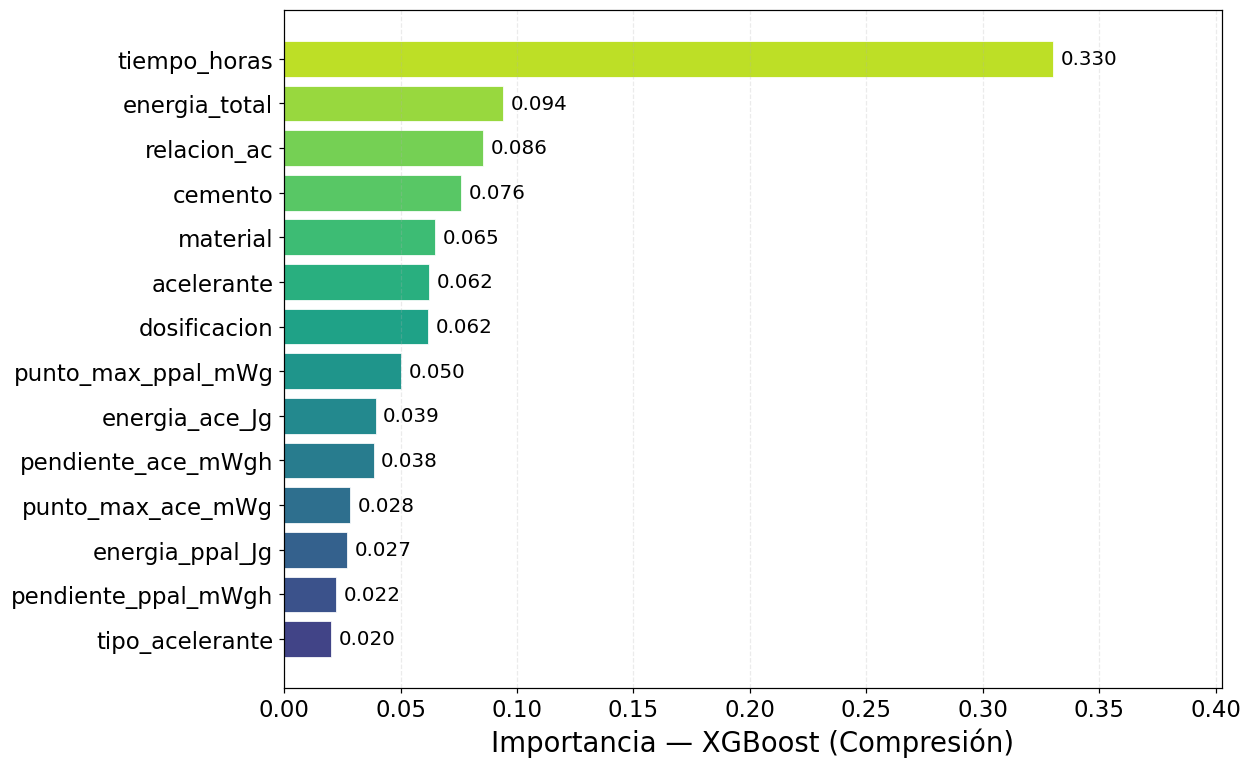

    figura guardada: figuras/fig_2C_importancias_xgb_compresion.pdf

  Exportados: modelo_portramo_rf.pkl, modelo_portramo_xgb.pkl


In [6]:
# ==============================================================================
# CELDA 2.C — MODELOS POR TRAMO TEMPORAL (Random Forest y XGBoost)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

TRAMOS = ['Penetración', 'Clavo', 'Compresión']

RANGO_TRAMO = {s: (min(h for h, _, f in PUNTOS if f == s),
                   max(h for h, _, f in PUNTOS if f == s))
               for s in TRAMOS if any(f == s for _, _, f in PUNTOS)}

def construir_rf_tramo():
    return envolver_objetivo(RandomForestRegressor(**CFG_PARAMS_RF))

def construir_xgb_tramo():
    return envolver_objetivo(XGBRegressor(**CFG_PARAMS_XGB))

def ajustador_por_tramo(constructor):
    def ajustar(tr, te):
        pred = np.full(len(te['y']), np.nan)
        for serie in RANGO_TRAMO:
            m_tr, m_te = tr['serie'] == serie, te['serie'] == serie
            if not m_te.any() or m_tr.sum() < CFG_MIN_ENTRENO_PUNTO:
                continue
            m = constructor()
            m.fit(np.column_stack([tr['X'][m_tr], tr['t'][m_tr]]), tr['y'][m_tr])
            pred[m_te] = m.predict(np.column_stack([te['X'][m_te], te['t'][m_te]]))
        return pred
    return ajustar

# ── 1. Validación ───────────────────────────────────────────────────────────
print("=" * 78)
print("  CELDA 2.C — MODELOS POR TRAMO TEMPORAL")
print("=" * 78)
for s, (h0, h1) in RANGO_TRAMO.items():
    print(f"    {s:<12} {etiqueta_tiempo(h0):>7} – {etiqueta_tiempo(h1):<7} "
          f"{int((S_ALL == s).sum()):>4} ensayos")
print(f"  Objetivo: {'log(1 + resistencia)' if CFG_OBJETIVO_LOG else 'resistencia en MPa'}")

registrar('RF-porTramo',
          para_cada_particion(ajustador_por_tramo(construir_rf_tramo),
                              etiqueta='RF-porTramo'))
registrar('XGB-porTramo',
          para_cada_particion(ajustador_por_tramo(construir_xgb_tramo),
                              etiqueta='XGB-porTramo'))

# ── 2. Tablas de resultados ─────────────────────────────────────────────────
METODOS_C2C = ['RF-porTramo', 'XGB-porTramo']
MET_PUNTO_C2C, MEDIA_C2C, PUNTOS_COMUNES_C2C = imprimir_tabla_por_punto(
    METODOS_C2C, 'MODELOS POR TRAMO · R² y MAE de cada punto')
print("  Un modelo por tramo cubre todas las edades de su familia: el desglose")
print("  dice en qué edades de cada tramo acierta y en cuáles no.")

MASC_C2C = imprimir_tablas_mascaras(METODOS_C2C, 'MODELOS POR TRAMO')
print("  En esta estrategia, cada columna de familia es exactamente el rendimiento")
print("  de uno de los tres modelos de su algoritmo.")

imprimir_comparacion_por_punto(
    ['RF-porPunto', 'XGB-porPunto', 'RF-conTiempo', 'XGB-conTiempo',
     'RF-porTramo', 'XGB-porTramo'],
    'COMPARACIÓN POR PUNTO · Celdas 2, 2.B y 2.C')

# ── 3. Modelos definitivos con el 100 % ─────────────────────────────────────
MODELOS_TRAMO = {'Random Forest': {}, 'XGBoost': {}}
for serie in RANGO_TRAMO:
    m = S_APP_LARGO == serie
    for etiqueta, constructor in [('Random Forest', construir_rf_tramo),
                                  ('XGBoost',       construir_xgb_tramo)]:
        MODELOS_TRAMO[etiqueta][serie] = {
            'modelo': constructor().fit(X_APP_LARGO[m], Y_APP_LARGO[m]),
            'horas_min': RANGO_TRAMO[serie][0], 'horas_max': RANGO_TRAMO[serie][1],
            'n_ensayos': int(m.sum()),
            'n_mezclas': int(len(np.unique(G_ALL[S_ALL == serie]))),
        }
print(f"\n  Modelos definitivos: {len(RANGO_TRAMO)} tramos x 2 algoritmos, "
      f"entrenados con el 100 % de las mezclas")

# ── 4. Figuras ──────────────────────────────────────────────────────────────
EDADES_MEDIDAS = np.unique(T_ALL)

def _curva_tramos(etiqueta):
    salida = []
    for serie, d in MODELOS_TRAMO[etiqueta].items():
        m = (HORAS_EJE >= d['horas_min'] - 1e-9) & (HORAS_EJE <= d['horas_max'] + 1e-9)
        salida.append((serie, HORAS_EJE[m], d['modelo'].predict(X_CURVA[m])))
    return salida

_curvas = []
for etiqueta, clave, estilo in [('Random Forest', 'RF-porTramo', '-'),
                                ('XGBoost',       'XGB-porTramo', '--')]:
    for k, (serie, h, v) in enumerate(_curva_tramos(etiqueta)):
        descensos = int((np.diff(v) < -1e-9).sum())
        print(f"    {etiqueta} · {serie}: tramos decrecientes en la curva cruda = "
              f"{descensos} de {len(h) - 1}")
        _curvas.append((etiqueta if k == 0 else '_nolegend_', h, v,
                        COLOR[clave], estilo))
figura_curva(_curvas, 'fig_2C_curva_tramos')

def _bloques_por_tramo(etiqueta):
    bloques = []
    for serie, d in MODELOS_TRAMO[etiqueta].items():
        b = {'serie': serie, 'horas': [], 'media_pred': [], 'std_pred': [],
             'media_real': [], 'n': []}
        for horas, col, s in PUNTOS:
            if s != serie:
                continue
            m = df[col].notna().to_numpy()
            Xp = np.column_stack([X_IMP_APP[m], np.full(int(m.sum()), horas)])
            pred = d['modelo'].predict(Xp)
            b['horas'].append(horas)
            b['media_pred'].append(float(pred.mean()))
            b['std_pred'].append(float(pred.std()))
            b['media_real'].append(float(df.loc[m, col].mean()))
            b['n'].append(int(m.sum()))
        bloques.append(b)
    return bloques

for etiqueta, archivo in [('Random Forest', 'fig_2C_curva_por_punto_rf'),
                          ('XGBoost',       'fig_2C_curva_por_punto_xgb')]:
    figura_curva_por_serie(
        _bloques_por_tramo(etiqueta), archivo,
        f'{etiqueta} por tramo temporal: curva con banda ±1σ',
        marcas_horas=EDADES_MEDIDAS)

_SLUG_TRAMO = {'Penetración': 'penetracion', 'Clavo': 'clavo', 'Compresión': 'compresion'}
for etiqueta, corto in [('Random Forest', 'rf'), ('XGBoost', 'xgb')]:
    for serie, d in MODELOS_TRAMO[etiqueta].items():
        figura_importancias(
            NOMBRES_VARIABLES, importancias_de(d['modelo']),
            f'fig_2C_importancias_{corto}_{_SLUG_TRAMO[serie]}',
            f"{etiqueta} por tramo: {serie} ({etiqueta_tiempo(d['horas_min'])}–"
            f"{etiqueta_tiempo(d['horas_max'])})",
            etiqueta_eje=f'Importancia — {etiqueta} ({serie})')

# ── 5. Exportación ──────────────────────────────────────────────────────────
import joblib

def _paquete_por_tramo(etiqueta, clave_registro):
    met = resumen_metricas(clave_registro)
    return {
        'tipo': etiqueta, 'estrategia': 'por_tramo',
        'modelos_tramo': {s: {k: v for k, v in d.items()}
                          for s, d in MODELOS_TRAMO[etiqueta].items()},
        'imputer': IMPUTADOR_APP, 'features_ok': CFG_FEATURES,
        'nombres_variables': NOMBRES_VARIABLES,
        'medianas': MEDIANAS_APP,
        'factorizacion': FACTORIZACION_APP, 'combos_validos': combos_validos,
        'datos_reales': DATOS_REALES_APP,
        'metricas': {k: v for k, v in met.items() if v is not None},
        'metricas_por_punto_mascara': {k: v for k, v in resumen_metricas_por_punto(clave_registro).items()
                                       if v is not None},
        'r2_medio_puntos': MEDIA_C2C[clave_registro],
        'metricas_por_punto': MET_PUNTO_C2C[clave_registro],
        'protocolo': f'{len(PRED[clave_registro])} particiones 80/20 por mezcla',
        'objetivo_log': CFG_OBJETIVO_LOG,
    }

joblib.dump(_paquete_por_tramo('Random Forest', 'RF-porTramo'), 'modelo_portramo_rf.pkl')
joblib.dump(_paquete_por_tramo('XGBoost',       'XGB-porTramo'), 'modelo_portramo_xgb.pkl')
print("\n  Exportados: modelo_portramo_rf.pkl, modelo_portramo_xgb.pkl")

  CELDA 3 — REGRESIONES SIMBÓLICAS


### Significado de las variables de las ecuaciones
*14 variables* (sin temperatura)

| Símbolo | Variable | Significado | Unidad |
|:--:|:--|:--|:--:|
| $M$ | `material` | Material / mortero base (categórica factorizada) | código |
| $AC$ | `relacion_ac` | Relación agua/cemento | — |
| $C$ | `cemento` | Tipo de cemento (categórica factorizada) | código |
| $A_{f}$ | `tipo_acelerante` | Familia de acelerante (categórica factorizada) | código |
| $A_{p}$ | `acelerante` | Producto acelerante (categórica factorizada) | código |
| $D$ | `dosificacion` | Dosificación de acelerante | % |
| $P_{ace}$ | `punto_max_ace_mWg` | Pico de flujo de calor — fase del acelerante | mW/g |
| $m_{ace}$ | `pendiente_ace_mWgh` | Pendiente de subida — fase del acelerante | mW/g·h |
| $E_{ace}$ | `energia_ace_Jg` | Energía liberada — fase del acelerante | J/g |
| $P_{ppal}$ | `punto_max_ppal_mWg` | Pico de flujo de calor — fase principal (C₃S) | mW/g |
| $m_{ppal}$ | `pendiente_ppal_mWgh` | Pendiente de subida — fase principal | mW/g·h |
| $E_{ppal}$ | `energia_ppal_Jg` | Energía liberada — fase principal | J/g |
| $E_{tot}$ | `energia_total` | Energía total de hidratación | J/g |
| $t$ | `tiempo_horas` | Edad de ensayo | h |


  A) REGRESIÓN SIMBÓLICA — gplearn
    registrado: gplearn  (3 particiones)

  Evolución del entrenamiento (partición 0) — una fila por generación:
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0     7.91      3.49435e+10       10          202.468          184.824      3.84s
   1     6.40       6.9224e+09        5           122.12          159.955      4.61s
   2     6.31      1.66244e+08        5          116.535          138.946      5.22s
   3     7.58      2.70189e+06       12          95.1231          108.796      4.88s
   4     8.60      4.36129e+08       21          87.3074          79.5708      4.50s
   5    12.34      1.28735e+11       22          66.2198          57.0066      4.46s
   6    15.26      2.42008e+16       18          62.5296          84.4311      4.29s
   7    19.

### gplearn — R²=0.851 ± 0.021 · MAE=4.84 MPa · 3 particiones
*Ecuación de la partición 0 · 25 nodos*  
*Con funciones protegidas de gplearn (la protección actúa en 28 ensayos de entrenamiento): $\operatorname{log}_p(x)=\ln|x| \text{ si } |x|>0{,}001;\ 0 \text{ si no}$*

<IPython.core.display.Math object>

...

**Codo** (eq 2) — 4 nodos · R² test=0.7429 · MAE test=6.26 MPa

<IPython.core.display.Math object>

**Elegida** (eq 4) — 6 nodos · R² test=0.8991 · MAE test=3.82 MPa

<IPython.core.display.Math object>


  Curvas sobre la mezcla típica:
    gplearn: 300/300 puntos definidos


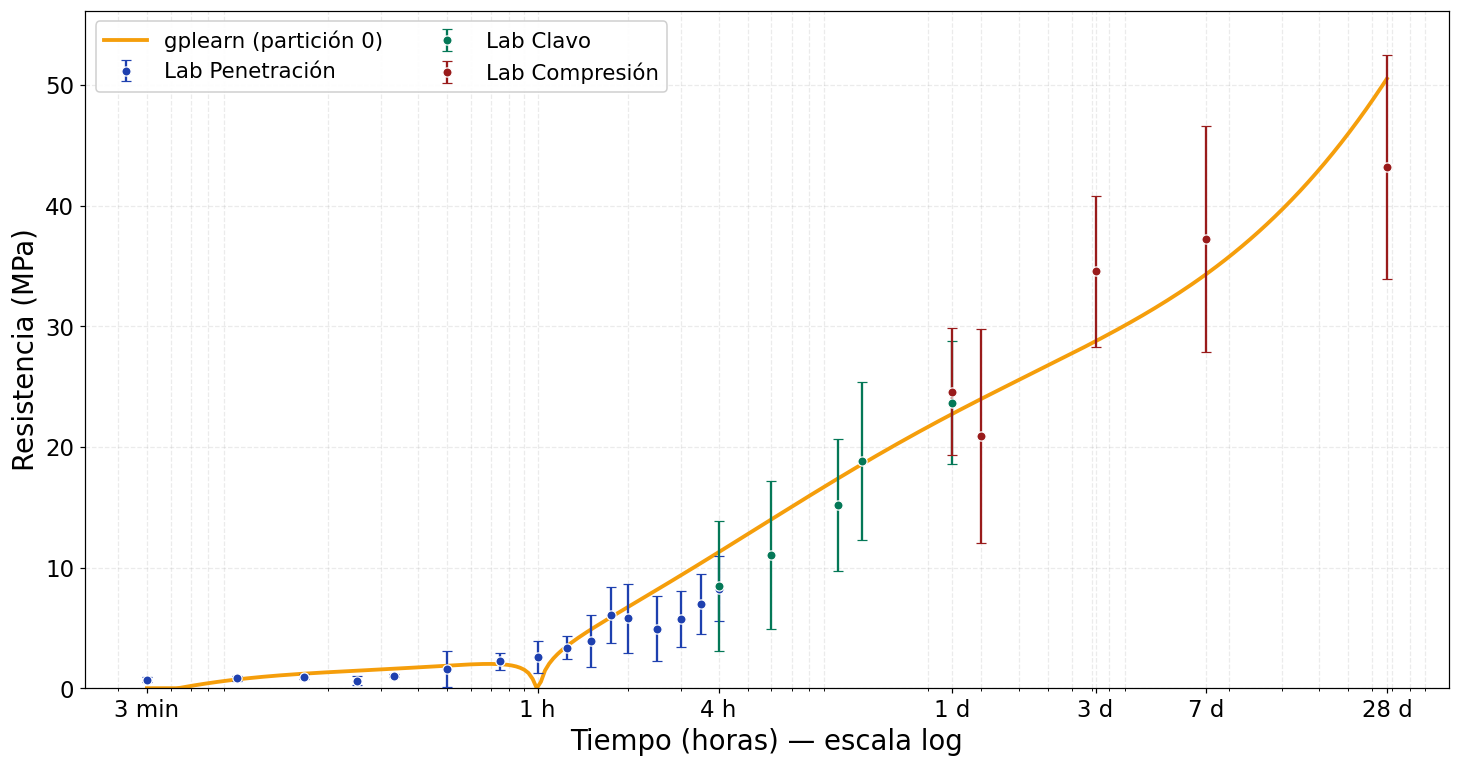

    figura guardada: figuras/fig_3_curva_gplearn.pdf
    LASSO: 300/300 puntos definidos


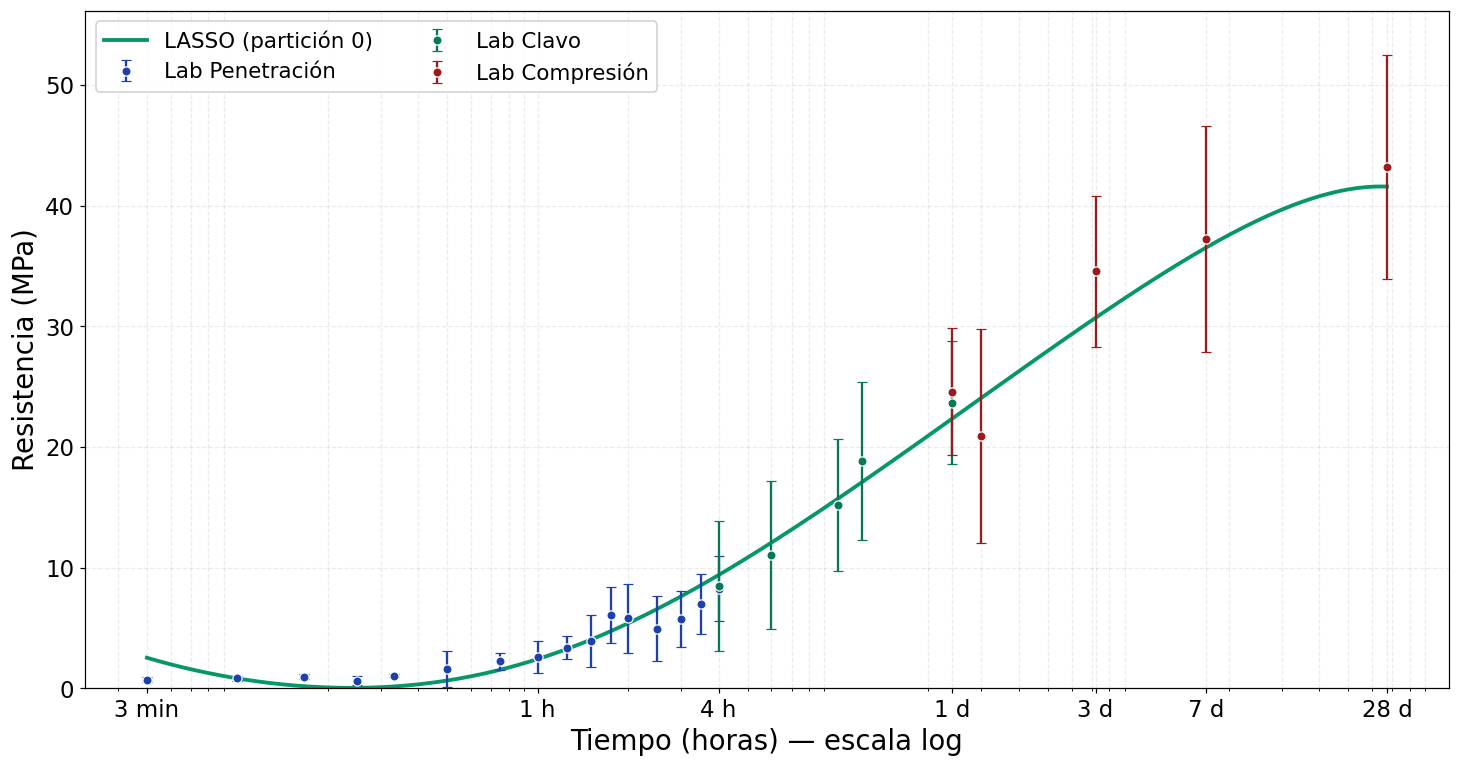

    figura guardada: figuras/fig_3_curva_lasso.pdf


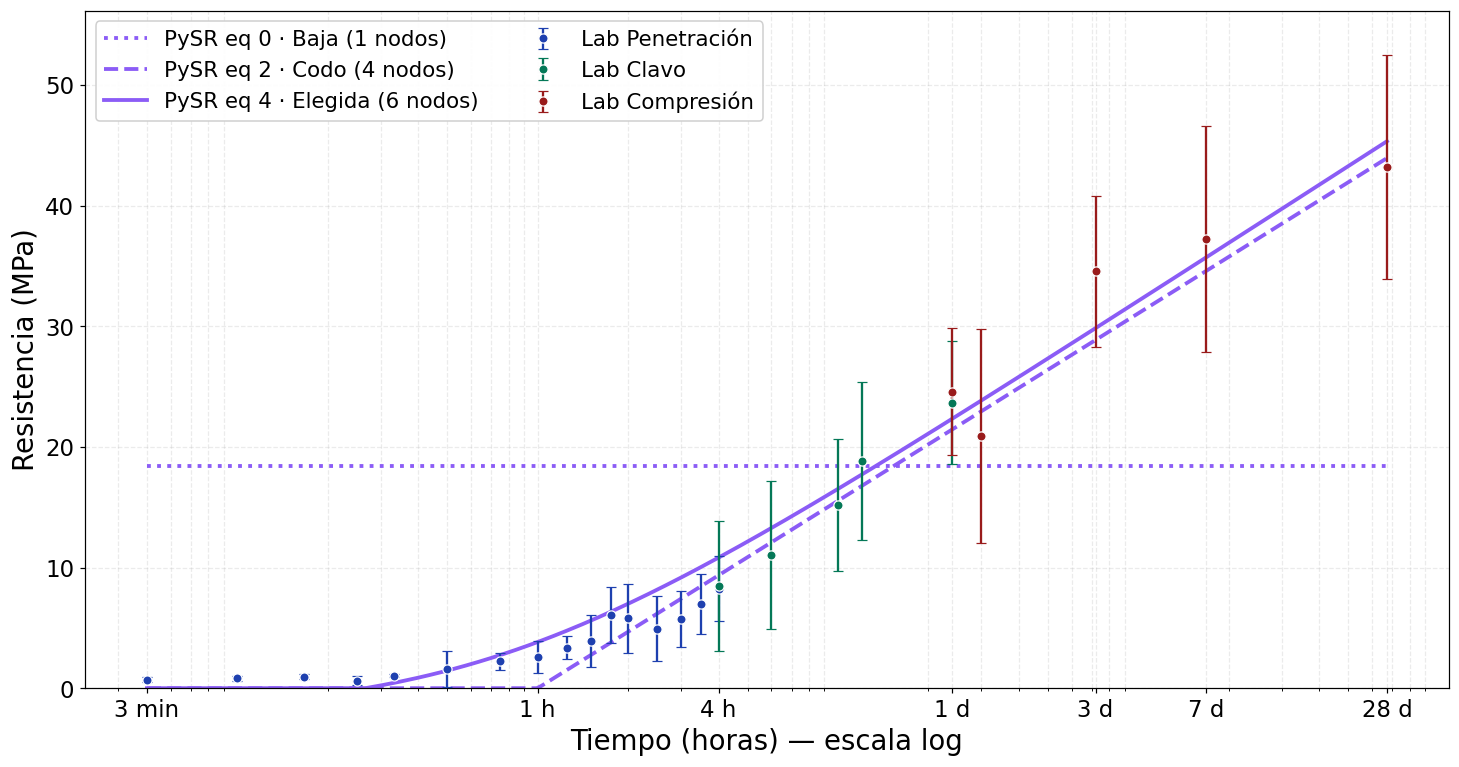

    figura guardada: figuras/fig_3_curva_pysr.pdf


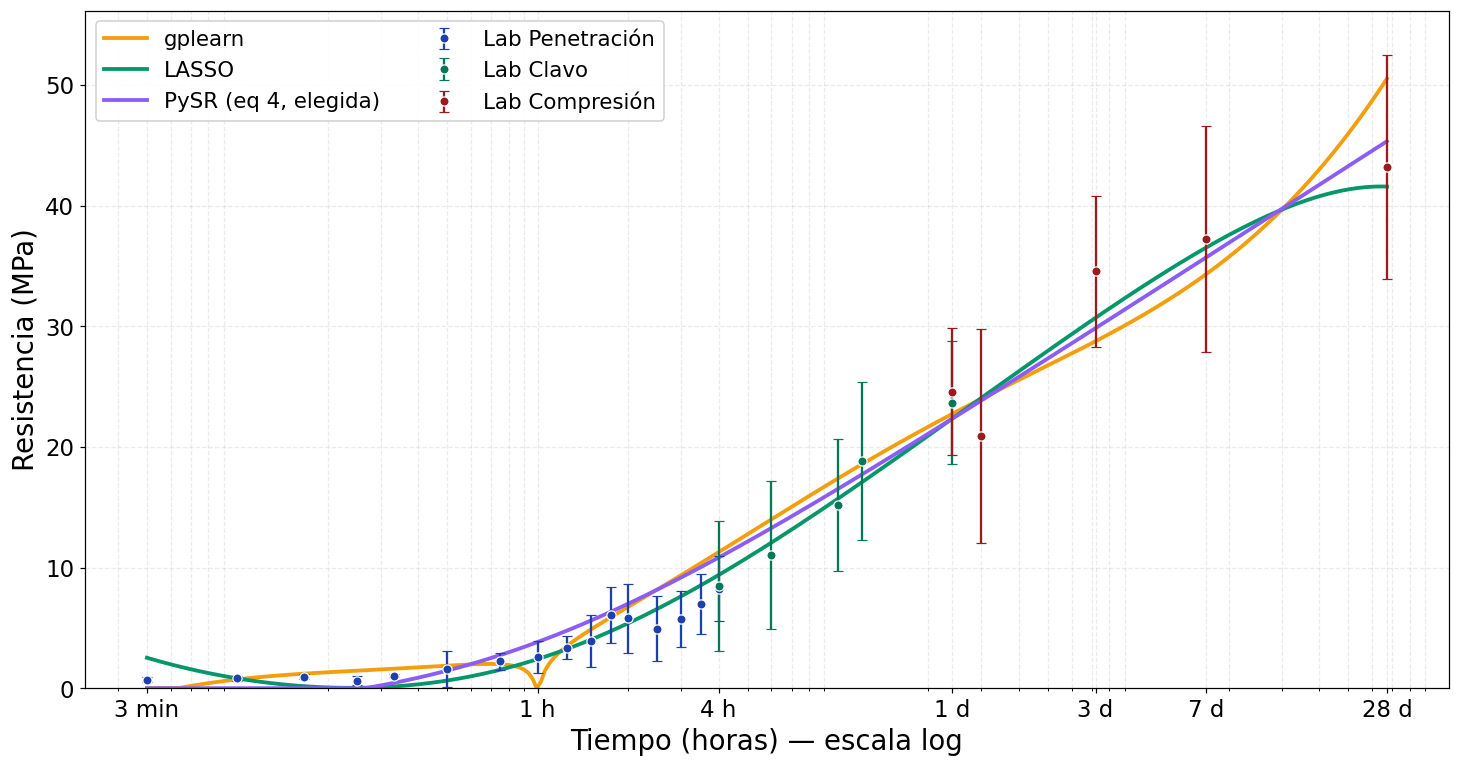

    figura guardada: figuras/fig_3_curvas_simbolicas.pdf

  VERIFICACIÓN · la ecuación mostrada (redondeada) reproduce la curva de la figura
  Ecuación                        dif. máx (MPa)  dif. relativa  dominio ≠  recortes a 0  resultado
------------------------------------------------------------------------------------------------
  gplearn                               1.42e-14         0.000%          0             9  OK
  LASSO                                  0.00631         0.015%          0             0  OK
  PySR eq 0 (Baja)                       0.00399         0.022%          0             0  OK
  PySR eq 2 (Codo)                       0.00199         0.005%          0            95  OK
  PySR eq 4 (Elegida)                    0.00189         0.004%          0            53  OK
  OK = diferencia ≤ 1% del máximo de la curva y la ecuación está definida exactamente
       donde lo está la curva. La diferencia que queda es el redondeo a 4 cifras.
  dominio ≠    = puntos de la

In [7]:
# ==============================================================================
# CELDA 3 — REGRESIONES SIMBÓLICAS (gplearn, LASSO, PySR)
# ==============================================================================

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

CFG_CIFRAS_ECUACION = 4
CFG_TOL_VERIFICACION = 0.01

SIMBOLOS = {
    'tiempo_horas': sp.Symbol('t'),        'material':            sp.Symbol('M'),
    'relacion_ac':  sp.Symbol('AC'),       'cemento':             sp.Symbol('C'),
    'tipo_acelerante': sp.Symbol('A_f'),   'acelerante':          sp.Symbol('A_p'),
    'dosificacion': sp.Symbol('D'),        'punto_max_ace_mWg':   sp.Symbol('P_ace'),
    'pendiente_ace_mWgh': sp.Symbol('m_ace'), 'energia_ace_Jg':   sp.Symbol('E_ace'),
    'punto_max_ppal_mWg': sp.Symbol('P_ppal'),
    'pendiente_ppal_mWgh': sp.Symbol('m_ppal'),
    'energia_ppal_Jg': sp.Symbol('E_ppal'), 'energia_total':      sp.Symbol('E_tot'),
    'punto_max_ace_C': sp.Symbol('T_ace'), 'punto_max_ppal_C':    sp.Symbol('T_ppal'),
    'energia_temp_Jg': sp.Symbol('E_temp'),
}

def _mostrar(texto_md, latex=None):
    try:
        from IPython.display import display, Markdown, Math
        display(Markdown(texto_md))
        if latex:
            display(Math(latex))
    except Exception:
        print(texto_md)
        if latex:
            print(latex)

def _curva_limpia(valores):
    v = np.asarray(valores, dtype=float)
    return np.where(np.isfinite(v), np.maximum(v, 0.0), np.nan)

# ── Funciones protegidas de gplearn como funciones sympy con nombre ─────────
_UMBRAL_GP = 0.001

class div_p(sp.Function):
    nargs = 2
    @classmethod
    def eval(cls, a, b):
        if a.is_Number and b.is_Number:
            return a / b if abs(float(b)) > _UMBRAL_GP else sp.Integer(1)
    def _latex(self, printer):
        return (r"\operatorname{div}_p\!\left(" + printer._print(self.args[0]) + r",\, "
                + printer._print(self.args[1]) + r"\right)")

class log_p(sp.Function):
    nargs = 1
    @classmethod
    def eval(cls, x):
        if x.is_Number:
            return sp.log(abs(x)) if abs(float(x)) > _UMBRAL_GP else sp.Integer(0)
    def _latex(self, printer):
        return r"\operatorname{log}_p\!\left(" + printer._print(self.args[0]) + r"\right)"

class inv_p(sp.Function):
    nargs = 1
    @classmethod
    def eval(cls, x):
        if x.is_Number:
            return 1 / x if abs(float(x)) > _UMBRAL_GP else sp.Integer(0)
    def _latex(self, printer):
        return r"\operatorname{inv}_p\!\left(" + printer._print(self.args[0]) + r"\right)"

_FUNCIONES_NUMPY = {
    'div_p': lambda a, b: np.where(np.abs(b) > _UMBRAL_GP, np.divide(a, b), 1.0),
    'log_p': lambda x: np.where(np.abs(x) > _UMBRAL_GP, np.log(np.abs(x)), 0.0),
    'inv_p': lambda x: np.where(np.abs(x) > _UMBRAL_GP, 1.0 / x, 0.0),
}
_MODULOS = [_FUNCIONES_NUMPY, 'numpy']
_DEF_PROTEGIDAS = {
    'div_p': r"\operatorname{div}_p(a,b)=a/b \text{ si } |b|>0{,}001;\ 1 \text{ si no}",
    'log_p': r"\operatorname{log}_p(x)=\ln|x| \text{ si } |x|>0{,}001;\ 0 \text{ si no}",
    'inv_p': r"\operatorname{inv}_p(x)=1/x \text{ si } |x|>0{,}001;\ 0 \text{ si no}",
}

# ── Herramientas de coherencia ──────────────────────────────────────────────
def _a_simbolos(expr):
    mapa = {s: SIMBOLOS[str(s)] for s in expr.free_symbols if str(s) in SIMBOLOS}
    return expr.xreplace(mapa)

def _redondear(expr, cifras=CFG_CIFRAS_ECUACION):
    return expr.xreplace({f: sp.Float(f, cifras) for f in expr.atoms(sp.Float)})

_VALORES_CURVA = {}
for _j, _col in enumerate(NOMBRES_VARIABLES):
    _VALORES_CURVA[SIMBOLOS.get(_col, sp.Symbol(_col))] = X_CURVA[:, _j]
    _VALORES_CURVA[sp.Symbol(_col)] = X_CURVA[:, _j]

def _evaluar(expr, X_con_t):
    valores = {}
    for j, col in enumerate(NOMBRES_VARIABLES):
        valores[SIMBOLOS.get(col, sp.Symbol(col))] = X_con_t[:, j]
        valores[sp.Symbol(col)] = X_con_t[:, j]
    libres = sorted(expr.free_symbols, key=str)
    f = sp.lambdify(libres, expr, modules=_MODULOS)
    with np.errstate(all='ignore'):
        return np.broadcast_to(
            np.asarray(f(*[valores[s] for s in libres]), dtype=float),
            (len(X_con_t),)).copy()

VERIFICACION_C3 = []
ECUACIONES_C3   = []

def verificar_ecuacion(nombre, expr, curva_figura):
    libres = sorted(expr.free_symbols, key=str)
    desconocidos = [str(s) for s in libres if s not in _VALORES_CURVA]
    fila = {'nombre': nombre, 'dif': np.nan, 'rel': np.nan, 'dominio': 0,
            'recortados': 0, 'ok': False, 'nota': ''}
    if desconocidos:
        fila['nota'] = f"símbolos sin valor: {desconocidos}"
        VERIFICACION_C3.append(fila)
        return fila
    f = sp.lambdify(libres, expr, modules=_MODULOS)
    with np.errstate(all='ignore'):
        crudo = np.broadcast_to(
            np.asarray(f(*[_VALORES_CURVA[s] for s in libres]), dtype=float),
            HORAS_EJE.shape)
    v = _curva_limpia(crudo)
    c = np.asarray(curva_figura, dtype=float)
    m = np.isfinite(v) & np.isfinite(c)
    fila['dominio']    = int((np.isfinite(v) != np.isfinite(c)).sum())
    fila['recortados'] = int((np.isfinite(crudo) & (crudo < 0)).sum())
    if m.any():
        fila['dif'] = float(np.max(np.abs(v[m] - c[m])))
        fila['rel'] = fila['dif'] / max(float(np.nanmax(np.abs(c[m]))), 1e-9)
    fila['ok'] = (np.isfinite(fila['rel']) and fila['rel'] <= CFG_TOL_VERIFICACION
                  and fila['dominio'] == 0)
    VERIFICACION_C3.append(fila)
    return fila

def _mostrar_ecuacion(nombre, titulo_md, expr, curva_figura):
    latex = r"R = " + sp.latex(expr)
    _mostrar(titulo_md, latex)
    ECUACIONES_C3.append((nombre, latex))
    return verificar_ecuacion(nombre, expr, curva_figura)

print("=" * 78)
print("  CELDA 3 — REGRESIONES SIMBÓLICAS")
print("=" * 78)

# ══════════════════════════════════════════════════════════════════════════════
# LEYENDA DE VARIABLES
# ══════════════════════════════════════════════════════════════════════════════
DESCRIPCIONES = {
    'material':            ('Material / mortero base (categórica factorizada)',  'código'),
    'relacion_ac':         ('Relación agua/cemento',                             '—'),
    'cemento':             ('Tipo de cemento (categórica factorizada)',          'código'),
    'tipo_acelerante':     ('Familia de acelerante (categórica factorizada)',    'código'),
    'acelerante':          ('Producto acelerante (categórica factorizada)',      'código'),
    'dosificacion':        ('Dosificación de acelerante',                        '%'),
    'punto_max_ace_mWg':   ('Pico de flujo de calor — fase del acelerante',      'mW/g'),
    'pendiente_ace_mWgh':  ('Pendiente de subida — fase del acelerante',         'mW/g·h'),
    'energia_ace_Jg':      ('Energía liberada — fase del acelerante',            'J/g'),
    'punto_max_ppal_mWg':  ('Pico de flujo de calor — fase principal (C₃S)',     'mW/g'),
    'pendiente_ppal_mWgh': ('Pendiente de subida — fase principal',              'mW/g·h'),
    'energia_ppal_Jg':     ('Energía liberada — fase principal',                 'J/g'),
    'energia_total':       ('Energía total de hidratación',                      'J/g'),
    'punto_max_ace_C':     ('Temperatura máxima — fase del acelerante',          '°C'),
    'punto_max_ppal_C':    ('Temperatura máxima — fase principal',               '°C'),
    'energia_temp_Jg':     ('Área de la curva de temperatura (energía térmica)', 'J/g'),
    'tiempo_horas':        ('Edad de ensayo',                                    'h'),
}

_filas_leyenda = []
for _col in NOMBRES_VARIABLES:
    if _col not in DESCRIPCIONES:
        continue
    _desc, _ud = DESCRIPCIONES[_col]
    _simb = sp.latex(SIMBOLOS.get(_col, sp.Symbol(_col.replace('_', ''))))
    _filas_leyenda.append(f"| ${_simb}$ | `{_col}` | {_desc} | {_ud} |")

_mostrar("### Significado de las variables de las ecuaciones\n"
         f"*{len(_filas_leyenda)} variables* "
         f"({'con' if CFG_INCLUIR_TEMPERATURA else 'sin'} temperatura)\n\n"
         "| Símbolo | Variable | Significado | Unidad |\n"
         "|:--:|:--|:--|:--:|\n" + "\n".join(_filas_leyenda))

_TR0 = FOLDS[0]['tr']
_TE0 = FOLDS[0]['te']

_X_CURVA_DF = pd.DataFrame(X_CURVA, columns=NOMBRES_VARIABLES)
_CURVA_TIPICA = {'t': HORAS_EJE, 'X': X_CURVA[:, :-1]}

# ══════════════════════════════════════════════════════════════════════════════
# A) gplearn
# ══════════════════════════════════════════════════════════════════════════════
from gplearn.genetic import SymbolicRegressor

def construir_gplearn(verbose=0):
    return SymbolicRegressor(
        population_size=500, generations=15,
        function_set=['add', 'sub', 'mul', 'div', 'sqrt', 'log', 'inv',
                      'sin', 'cos'],
        metric='mse', parsimony_coefficient=0.01,
        p_crossover=0.7, p_subtree_mutation=0.1, p_hoist_mutation=0.05,
        p_point_mutation=0.1, max_samples=0.9, verbose=verbose,
        random_state=42, n_jobs=1)

def ajustar_gplearn(tr, te):
    m = construir_gplearn()
    m.fit(np.column_stack([tr['X'], tr['t']]), tr['y'])
    return m.predict(np.column_stack([te['X'], te['t']]))

print("\n" + "=" * 70)
print("  A) REGRESIÓN SIMBÓLICA — gplearn")
print("=" * 70)
registrar('gplearn', para_cada_particion(ajustar_gplearn, n=CFG_N_PART_CARO,
                                         etiqueta='gplearn'))

print("\n  Evolución del entrenamiento (partición 0) — una fila por generación:")
_gp0 = construir_gplearn(verbose=1)
_gp0.fit(np.column_stack([_TR0['X'], _TR0['t']]), _TR0['y'])
assert np.allclose(_gp0.predict(np.column_stack([_TE0['X'], _TE0['t']])),
                   PRED['gplearn'][0], equal_nan=True), \
    "El programa de gplearn mostrado no es el de la partición 0 del registro"

_comun = {'add': lambda a, b: a + b, 'sub': lambda a, b: a - b,
          'mul': lambda a, b: a * b, 'sqrt': lambda a: sp.sqrt(sp.Abs(a)),
          'sin': sp.sin, 'cos': sp.cos}
_entorno_limpio = {**_comun, 'div': lambda a, b: a / b,
                   'log': lambda a: sp.log(sp.Abs(a)), 'inv': lambda a: 1 / a}
_entorno_fiel = {**_comun, 'div': div_p, 'log': log_p, 'inv': inv_p}
for _i, _nv in enumerate(NOMBRES_VARIABLES):
    _s = SIMBOLOS.get(_nv, sp.Symbol(_nv.replace('_', '')))
    _entorno_limpio[f'X{_i}'] = _s
    _entorno_fiel[f'X{_i}'] = _s


_prog = str(_gp0._program)
print(f"\n  Programa de la partición 0 (texto original de gplearn):\n    {_prog}")
import re as _re
_vars_gp = sorted({int(k) for k in _re.findall(r'X(\d+)', _prog)})
_cat_gp  = [NOMBRES_VARIABLES[k] for k in _vars_gp if NOMBRES_VARIABLES[k] in CFG_CATEG]
if _cat_gp:
    print(f"\n  ATENCIÓN: la ecuación opera con el CÓDIGO de variables categóricas "
          f"({', '.join(_cat_gp)}).")
    print("  Ese código es arbitrario (orden de aparición en el Excel): la fórmula")
    print("  cambiaría con sólo reordenar las categorías. Decirlo en la memoria.")
if 'sin' in _prog or 'cos' in _prog:
    print("\n  ATENCIÓN: la ecuación de la partición 0 contiene un término "
          "periódico (sin/cos).")
    print("  Implica resistencia oscilante con la edad. Válida sólo como ajuste "
          "dentro del")
    print("  rango medido (3 min – 28 d); no extrapolar.")

with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    _curva_gp = _curva_limpia(_gp0.predict(X_CURVA))

_d = resumen_metricas('gplearn')['Global']
_titulo = (f"### gplearn — R²={_d['r2']:.3f} ± {_d['r2_sd']:.3f} · "
           f"MAE={_d['mae']:.2f} MPa · {len(PRED['gplearn'])} particiones\n"
           f"*Ecuación de la partición 0 · {_gp0._program.length_} nodos*")
try:
    _Xtr0_t = np.column_stack([_TR0['X'], _TR0['t']])
    _ref_gp = _gp0.predict(_Xtr0_t)
    _limpia = sp.simplify(eval(_prog, {'__builtins__': None}, _entorno_limpio))
    _v_limpia = _evaluar(_limpia, _Xtr0_t)
    if np.allclose(_v_limpia, _ref_gp, rtol=1e-6, atol=1e-6):
        _expr_gp = _redondear(_limpia)
        print("    ecuación limpia: reproduce el modelo en todos los ensayos de "
              "entrenamiento")
    else:
        _n_prot = int((~np.isclose(_v_limpia, _ref_gp, rtol=1e-6, atol=1e-6)).sum())
        print(f"    la protección de gplearn actúa en {_n_prot} de {len(_ref_gp)} "
              f"ensayos de entrenamiento:")
        print("    se publica la ecuación FIEL, con las funciones protegidas con nombre")
        _expr_gp = _redondear(sp.simplify(
            eval(_prog, {'__builtins__': None}, _entorno_fiel)))
        _usadas = [n for n in _DEF_PROTEGIDAS if n in sp.srepr(_expr_gp)]
        _titulo += (f"  \n*Con funciones protegidas de gplearn (la protección actúa "
                    f"en {_n_prot} ensayos de entrenamiento): "
                    + '; '.join(f"${_DEF_PROTEGIDAS[n]}$" for n in _usadas) + "*")
    _mostrar_ecuacion('gplearn', _titulo, _expr_gp, _curva_gp)
except Exception as e:
    _mostrar(_titulo, r'\text{(expresión no convertible)}')
    print(f"    aviso al convertir la expresión de gplearn: {e}")
    VERIFICACION_C3.append({'nombre': 'gplearn', 'dif': np.nan, 'rel': np.nan,
                            'dominio': 0, 'recortados': 0, 'ok': False,
                            'nota': 'no convertible'})

# ══════════════════════════════════════════════════════════════════════════════
# B) LASSO sobre una base de términos construida a mano
# ══════════════════════════════════════════════════════════════════════════════
IDX_D = CFG_FEATURES.index('dosificacion')
IDX_P = CFG_FEATURES.index('punto_max_ppal_mWg')
IDX_A = CFG_FEATURES.index('punto_max_ace_mWg')
CFG_LASSO_FOLDS = 5

NOMBRES_TERMINOS = ['t', 'ln(t+1)', '1/t', 'sqrt(t)', 'D', 'P_ppal', 'P_ace',
                    'D*ln(t+1)', 'P_ppal*ln(t+1)', 'D*P_ppal', 'D/sqrt(t)']

def construir_terminos(d):
    t = d['t']; D = d['X'][:, IDX_D]; P = d['X'][:, IDX_P]; A = d['X'][:, IDX_A]
    return np.column_stack([t, np.log(t + 1), 1 / (t + 1e-5), np.sqrt(t),
                            D, P, A, D * np.log(t + 1), P * np.log(t + 1),
                            D * P, D / (np.sqrt(t) + 1e-5)])

def _cortes_por_mezcla(d):
    return list(GroupKFold(n_splits=CFG_LASSO_FOLDS)
                .split(d['X'], d['y'], groups=d['g']))

def _ajustar_lasso(tr):
    sc = StandardScaler().fit(construir_terminos(tr))
    Z = sc.transform(construir_terminos(tr))
    m = LassoCV(cv=_cortes_por_mezcla(tr), max_iter=20000,
                random_state=42).fit(Z, tr['y'])
    return sc, m, Z

def ajustar_lasso(tr, te):
    sc, m, _ = _ajustar_lasso(tr)
    return np.maximum(m.predict(sc.transform(construir_terminos(te))), 0)

print("\n" + "=" * 70)
print("  B) REGRESIÓN PARAMÉTRICA — LASSO")
print("=" * 70)
registrar('LASSO', para_cada_particion(ajustar_lasso, etiqueta='LASSO'))

_sc0, _lasso0, _X0 = _ajustar_lasso(_TR0)

# ── Camino de regularización (partición 0) ──────────────────────────────────
_mse_cv = _lasso0.mse_path_.mean(axis=1)
_, _coefs_camino, _ = lasso_path(_X0, _TR0['y'], alphas=_lasso0.alphas_,
                                 max_iter=20000)
_nz_camino = (np.abs(_coefs_camino) > 0).sum(axis=0)
_i_elegido = int(np.argmin(np.abs(_lasso0.alphas_ - _lasso0.alpha_)))

print("\n  Camino de regularización (PARTICIÓN 0) — validación interna por mezcla:")
print(f"    {'alpha':>10} {'MSE CV medio':>13} {'RMSE (MPa)':>11} {'términos ≠ 0':>14}")
print("    " + "-" * 52)
_paso = max(1, len(_lasso0.alphas_) // 10)
_filas_camino = sorted(set(range(0, len(_lasso0.alphas_), _paso)) | {_i_elegido})
for _k in _filas_camino:
    print(f"    {_lasso0.alphas_[_k]:>10.4f} {_mse_cv[_k]:>13.3f} "
          f"{np.sqrt(_mse_cv[_k]):>11.3f} {_nz_camino[_k]:>14}"
          + ("   ← elegido" if _k == _i_elegido else ""))

# ── Ecuación en escala original, con TODOS los términos no nulos ──
_coef = _lasso0.coef_ / _sc0.scale_
_intercepto = _lasso0.intercept_ - float(np.sum(_coef * _sc0.mean_))

_t, _D = SIMBOLOS['tiempo_horas'], SIMBOLOS['dosificacion']
_Pp, _Pa = SIMBOLOS['punto_max_ppal_mWg'], SIMBOLOS['punto_max_ace_mWg']
_MAPA = {'t': _t, 'ln(t+1)': sp.log(_t + 1), '1/t': 1 / _t, 'sqrt(t)': sp.sqrt(_t),
         'D': _D, 'P_ppal': _Pp, 'P_ace': _Pa,
         'D*ln(t+1)': _D * sp.log(_t + 1), 'P_ppal*ln(t+1)': _Pp * sp.log(_t + 1),
         'D*P_ppal': _D * _Pp, 'D/sqrt(t)': _D / sp.sqrt(_t)}

print(f"\n  Términos supervivientes (coeficientes en escala original, "
      f"{CFG_CIFRAS_ECUACION} cifras significativas):")
print(f"    {'intercepto':<18} {float(sp.Float(_intercepto, CFG_CIFRAS_ECUACION)):+.6g}")
_expr_lasso = sp.Float(_intercepto)
for _nt, _c, _cz in zip(NOMBRES_TERMINOS, _coef, _lasso0.coef_):
    if _cz != 0:
        print(f"    {_nt:<18} {float(sp.Float(_c, CFG_CIFRAS_ECUACION)):+.6g}")
        _expr_lasso += sp.Float(float(_c)) * _MAPA[_nt]
_n_nulos = int((_lasso0.coef_ == 0).sum())
print(f"    ({_n_nulos} de {len(NOMBRES_TERMINOS)} términos anulados por LASSO)")
_expr_lasso = _redondear(_expr_lasso)

with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    _curva_lasso = _curva_limpia(
        _lasso0.predict(_sc0.transform(construir_terminos(_CURVA_TIPICA))))

_d = resumen_metricas('LASSO')['Global']
_mostrar_ecuacion(
    'LASSO',
    f"### LASSO — R²={_d['r2']:.3f} ± {_d['r2_sd']:.3f} · "
    f"MAE={_d['mae']:.2f} MPa · {len(PRED['LASSO'])} particiones\n"
    f"*Ecuación de la partición 0 · alpha={_lasso0.alpha_:.4f} · "
    f"predicción recortada a 0 si sale negativa*",
    _expr_lasso, _curva_lasso)

# ══════════════════════════════════════════════════════════════════════════════
# C) PySR
# ══════════════════════════════════════════════════════════════════════════════
from pysr import PySRRegressor

def construir_pysr():
    return PySRRegressor(
        binary_operators=['+', '-', '*', '/'],
        unary_operators=['sqrt', 'log', 'exp', 'square', 'inv(x) = 1/x'],
        extra_sympy_mappings={'inv': lambda x: 1 / x},
        constraints={'/': (-1, 9), 'square': 9, 'exp': 9, 'inv': 9},
        select_k_features=10, niterations=50, populations=20, population_size=50,
        parsimony=0.01, maxsize=22, random_state=42,
        deterministic=True, procs=0, multithreading=False,
        batching=True, batch_size=50, verbosity=0, progress=False)

def ajustar_pysr(tr, te):
    m = construir_pysr()
    m.fit(pd.DataFrame(np.column_stack([tr['X'], tr['t']]), columns=NOMBRES_VARIABLES),
          tr['y'])
    return m.predict(pd.DataFrame(np.column_stack([te['X'], te['t']]),
                                  columns=NOMBRES_VARIABLES))

print("\n" + "=" * 70)
print("  C) REGRESIÓN SIMBÓLICA — PySR (varios minutos por partición)")
print("=" * 70)
registrar('PySR', para_cada_particion(ajustar_pysr, n=CFG_N_PART_CARO, etiqueta='PySR'))

_X_TR0_DF = pd.DataFrame(np.column_stack([_TR0['X'], _TR0['t']]),
                         columns=NOMBRES_VARIABLES)
_X_TE0_DF = pd.DataFrame(np.column_stack([_TE0['X'], _TE0['t']]),
                         columns=NOMBRES_VARIABLES)
_pysr0 = construir_pysr()
_pysr0.fit(_X_TR0_DF, _TR0['y'])

_EQ = _pysr0.equations_.reset_index(drop=True)
_n_eq = len(_EQ)
_complej = _EQ['complexity'].to_numpy()
_loss    = _EQ['loss'].to_numpy(float)
_score   = (_EQ['score'].to_numpy(float) if 'score' in _EQ.columns
            else np.full(_n_eq, np.nan))

_idx_elegida = int(np.flatnonzero(_pysr0.equations_.index == _pysr0.get_best().name)[0])
with np.errstate(all='ignore'):
    _p_def = np.asarray(_pysr0.predict(_X_TE0_DF), float)
    _p_idx = np.asarray(_pysr0.predict(_X_TE0_DF, index=_idx_elegida), float)
assert np.allclose(_p_def, _p_idx, equal_nan=True), \
    "No se ha identificado bien la ecuación con la que predice PySR"
assert np.allclose(_p_def, PRED['PySR'][0], equal_nan=True), \
    "La PySR de la partición 0 mostrada no coincide con la del registro"

# ── Frente de Pareto (partición 0) ──────────────────────────────────────────
_r2_pareto  = np.full(_n_eq, np.nan)
_mae_pareto = np.full(_n_eq, np.nan)
_n_finitos  = np.zeros(_n_eq, dtype=int)
for _i in range(_n_eq):
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        _p = np.asarray(_pysr0.predict(_X_TE0_DF, index=_i), dtype=float)
    _m = np.isfinite(_p)
    _n_finitos[_i] = int(_m.sum())
    if _m.sum() >= CFG_MIN_TEST_METRICA:
        _r2_pareto[_i]  = r2_score(_TE0['y'][_m], _p[_m])
        _mae_pareto[_i] = mean_absolute_error(_TE0['y'][_m], _p[_m])

_VALIDAS = np.flatnonzero(np.isfinite(_r2_pareto))
if len(_VALIDAS) == 0:
    raise RuntimeError(
        "Ninguna ecuación del frente de PySR es evaluable sobre el test de la "
        "partición 0. Revisa los operadores unarios o sube maxsize.")

_idx_baja = int(_VALIDAS[0])
_idx_codo = (int(_VALIDAS[np.nanargmax(_score[_VALIDAS])])
             if np.isfinite(_score[_VALIDAS]).any() else _idx_baja)

_etiquetas = {}
for _idx, _nombre in [(_idx_baja, 'Baja'), (_idx_codo, 'Codo'),
                      (_idx_elegida, 'Elegida')]:
    _etiquetas.setdefault(_idx, []).append(_nombre)
_ESTILO = {'Baja': ':', 'Codo': '--', 'Elegida': '-'}
SELECCION_PYSR = [(i, ' = '.join(n), _ESTILO[n[-1]]) for i, n in sorted(_etiquetas.items())]

_N_TEST0 = len(_TE0['y'])
print("\n  Frente de Pareto (PARTICIÓN 0) — todas las ecuaciones candidatas:")
print(f"    {'ID':<4}{'nodos':>6} {'pérdida tr.':>12} {'score tr.':>10} "
      f"{'R² test':>9} {'MAE test':>9} {'válidos':>9}  {'':<16} ecuación")
print("    " + "-" * 110)
for _i in range(_n_eq):
    _eq = str(_EQ.iloc[_i]['equation'])
    _eq = _eq[:40] + '...' if len(_eq) > 43 else _eq
    _c_r2  = f"{_r2_pareto[_i]:>9.4f}"  if np.isfinite(_r2_pareto[_i])  else f"{'—':>9}"
    _c_mae = f"{_mae_pareto[_i]:>9.2f}" if np.isfinite(_mae_pareto[_i]) else f"{'—':>9}"
    _c_sc  = f"{_score[_i]:>10.4f}"     if np.isfinite(_score[_i])      else f"{'—':>10}"
    _marca = ' = '.join(_etiquetas.get(_i, []))
    print(f"    {_i:<4}{int(_complej[_i]):>6} {_loss[_i]:>12.4g} {_c_sc} {_c_r2} "
          f"{_c_mae} {f'{_n_finitos[_i]}/{_N_TEST0}':>9}  {_marca:<16} {_eq}")
_n_rotas = int((_n_finitos < _N_TEST0).sum())
if _n_rotas:
    print(f"\n    {_n_rotas} de {_n_eq} ecuaciones no son evaluables en todo el "
          f"test (dominio de log/sqrt/inv).")
print(f"    '—' = menos de {CFG_MIN_TEST_METRICA} puntos válidos; no se evalúa.")
print("    R² y MAE de test: descriptivos, NO se usan para elegir.")

# ── Curvas y ecuaciones de las finalistas ──
_curvas_pysr = {}
for _idx, _, _ in SELECCION_PYSR:
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        _curvas_pysr[_idx] = _curva_limpia(_pysr0.predict(_X_CURVA_DF, index=_idx))

_d = resumen_metricas('PySR')['Global']
_mostrar(f"### PySR — R²={_d['r2']:.3f} ± {_d['r2_sd']:.3f} · "
         f"MAE={_d['mae']:.2f} MPa · {len(PRED['PySR'])} particiones\n"
         f"*Las métricas corresponden a la ecuación 'Elegida' (la que PySR usa "
         f"para predecir). Finalistas de la partición 0, entre las "
         f"{len(_VALIDAS)} evaluables de {_n_eq}.*")
for _idx, _nombre, _ in SELECCION_PYSR:
    _titulo = (f"**{_nombre}** (eq {_idx}) — {int(_complej[_idx])} nodos · "
               f"R² test={_r2_pareto[_idx]:.4f} · MAE test={_mae_pareto[_idx]:.2f} MPa")
    try:
        _expr_p = _redondear(_a_simbolos(sp.simplify(_pysr0.sympy(index=_idx))))
        _mostrar_ecuacion(f'PySR eq {_idx} ({_nombre})', _titulo, _expr_p,
                          _curvas_pysr[_idx])
    except Exception as e:
        _mostrar(_titulo, r'\text{(expresión no convertible)}')
        print(f"    aviso al convertir la ecuación {_idx} de PySR: {e}")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURAS — una curva por método, sin scatter
# ══════════════════════════════════════════════════════════════════════════════
print("\n  Curvas sobre la mezcla típica:")
print(f"    gplearn: {int(np.isfinite(_curva_gp).sum())}/{len(HORAS_EJE)} "
      f"puntos definidos")
figura_curva([('gplearn (partición 0)', HORAS_EJE, _curva_gp,
               COLOR['gplearn'], '-')], 'fig_3_curva_gplearn')

print(f"    LASSO: {int(np.isfinite(_curva_lasso).sum())}/{len(HORAS_EJE)} "
      f"puntos definidos")
figura_curva([('LASSO (partición 0)', HORAS_EJE, _curva_lasso,
               COLOR['LASSO'], '-')], 'fig_3_curva_lasso')

figura_curva(
    [(f'PySR eq {i} · {n} ({int(_complej[i])} nodos)',
      HORAS_EJE, _curvas_pysr[i], COLOR['PySR'], estilo)
     for i, n, estilo in SELECCION_PYSR],
    'fig_3_curva_pysr')

figura_curva(
    [('gplearn', HORAS_EJE, _curva_gp,    COLOR['gplearn'], '-'),
     ('LASSO',   HORAS_EJE, _curva_lasso, COLOR['LASSO'],   '-'),
     (f'PySR (eq {_idx_elegida}, elegida)', HORAS_EJE, _curvas_pysr[_idx_elegida],
      COLOR['PySR'], '-')],
    'fig_3_curvas_simbolicas')

# ══════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN: ECUACIÓN MOSTRADA ↔ CURVA DIBUJADA
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 96)
print("  VERIFICACIÓN · la ecuación mostrada (redondeada) reproduce la curva de la figura")
print("=" * 96)
print(f"  {'Ecuación':<30} {'dif. máx (MPa)':>15} {'dif. relativa':>14} "
      f"{'dominio ≠':>10} {'recortes a 0':>13}  resultado")
print("-" * 96)
for _v in VERIFICACION_C3:
    _dif = f"{_v['dif']:.3g}" if np.isfinite(_v['dif']) else '—'
    _rel = f"{_v['rel']:.3%}" if np.isfinite(_v['rel']) else '—'
    print(f"  {_v['nombre']:<30} {_dif:>15} {_rel:>14} {_v['dominio']:>10} "
          f"{_v['recortados']:>13}  {'OK' if _v['ok'] else 'REVISAR'}"
          + (f"  ({_v['nota']})" if _v['nota'] else ''))
print("=" * 96)
print(f"  OK = diferencia ≤ {CFG_TOL_VERIFICACION:.0%} del máximo de la curva y la "
      f"ecuación está definida exactamente")
print("       donde lo está la curva. La diferencia que queda es el redondeo a "
      f"{CFG_CIFRAS_ECUACION} cifras.")
print("  dominio ≠    = puntos de la curva donde una está definida y la otra no")
print("                 (típico de las funciones protegidas de gplearn).")
print("  recortes a 0 = puntos en que la ecuación da un valor negativo y la figura")
print("                 lo dibuja como 0. Si hay alguno, dilo en el pie de figura.")

# ══════════════════════════════════════════════════════════════════════════════
# TABLAS DE MÁSCARAS (R² y MAE, agrupados y medios por punto)
# ══════════════════════════════════════════════════════════════════════════════
METODOS_C3 = ['gplearn', 'LASSO', 'PySR']
MASC_C3 = imprimir_tablas_mascaras(METODOS_C3, 'MÉTODOS SIMBÓLICOS')
print("  Las ecuaciones publicadas salen de la partición 0; estas cifras "
      "promedian todas.")
print("  PySR: métricas de la ecuación 'Elegida' de cada partición.")

# ══════════════════════════════════════════════════════════════════════════════
# LaTeX PARA LA MEMORIA — exactamente las ecuaciones mostradas y verificadas
# ══════════════════════════════════════════════════════════════════════════════
print("\n  Ecuaciones en LaTeX (copiar tal cual; son las verificadas arriba):")
for _nombre, _latex in ECUACIONES_C3:
    print(f"\n  % {_nombre} — partición 0")
    print(r"  \begin{equation}")
    print(f"    {_latex}")
    print(r"  \end{equation}")

  CELDA 4 — COMPROBACIÓN DE LAS FÓRMULAS
    OK    FHP: en t = tau, R = R_max/e  (definición de tau)
    OK    FHP: R -> R_max cuando t -> infinito
    OK    Knudsen parabólico: R(t0 + t50) = R_inf/2  (definición de t50)
    OK    Knudsen lineal: R(t0 + t50) = R_inf/2
    OK    Knudsen: R = 0 para t <= t0
    OK    Schindler-Folliard: alpha(t = tau) = alpha_u/e
    OK    de Schutter-Taerwe: R = 0 por debajo de alpha0 y R = R_ref en alpha = 1
    OK    Anidamiento: SF+dS-T con alpha0 = 0, a = 1 es FHP con R_max = R_ref*alpha_u
    OK    Mills (1966): alpha_u(a/c = 0,40) = 1,031·0,40/(0,194+0,40) = 0,6943
    OK    CE-21: beta_cc(28 d) = 1, así que R(672 h) = R_28
    OK    CE-21: s = 0,20 / 0,25 / 0,38 para cemento R / N / S
    OK    CE-21: no se evalúa por debajo de 1 día
  12 comprobaciones superadas.
  CELDA 4 — MODELOS FÍSICOS, NORMA, CLASES J Y LÍNEAS BASE
    registrado: Base: media global  (15 particiones)
    registrado: Freiesleben H-P  (15 particiones)
    registrado: Knudsen

**Freiesleben Hansen y Pedersen**

<IPython.core.display.Math object>

**Knudsen parabólico** (dispersión, control por difusión)

<IPython.core.display.Math object>

**Schindler–Folliard + de Schutter–Taerwe** (dos etapas)

<IPython.core.display.Math object>

**Norma CE-21** (cemento R, válida para t ≥ 1 día)

<IPython.core.display.Math object>


------------------------------------------------------------------------------
  Verificación · la ecuación mostrada (redondeada) reproduce la curva de la figura
------------------------------------------------------------------------------
    Freiesleben H-P      dif. máx = 0.00845 MPa (0.019%)   dominio ≠ 0   OK
    Knudsen parabólico   dif. máx = 0.000601 MPa (0.001%)   dominio ≠ 0   OK
    SF + de Schutter     dif. máx = 0.0108 MPa (0.025%)   dominio ≠ 0   OK
    Norma CE-21          dif. máx = 0.00754 MPa (0.017%)   dominio ≠ 0   OK
    OK = diferencia ≤ 1 % del máximo de la curva; lo que queda es el redondeo.

------------------------------------------------------------------------------
  Tabla LaTeX de parámetros (copiar a Overleaf)
------------------------------------------------------------------------------
\begin{table}[htbp]
  \centering
  \caption{Constantes de los modelos físicos de caja blanca, ajustadas con el 100\,\% de los ensayos. Las incertidumbres son la raíz de

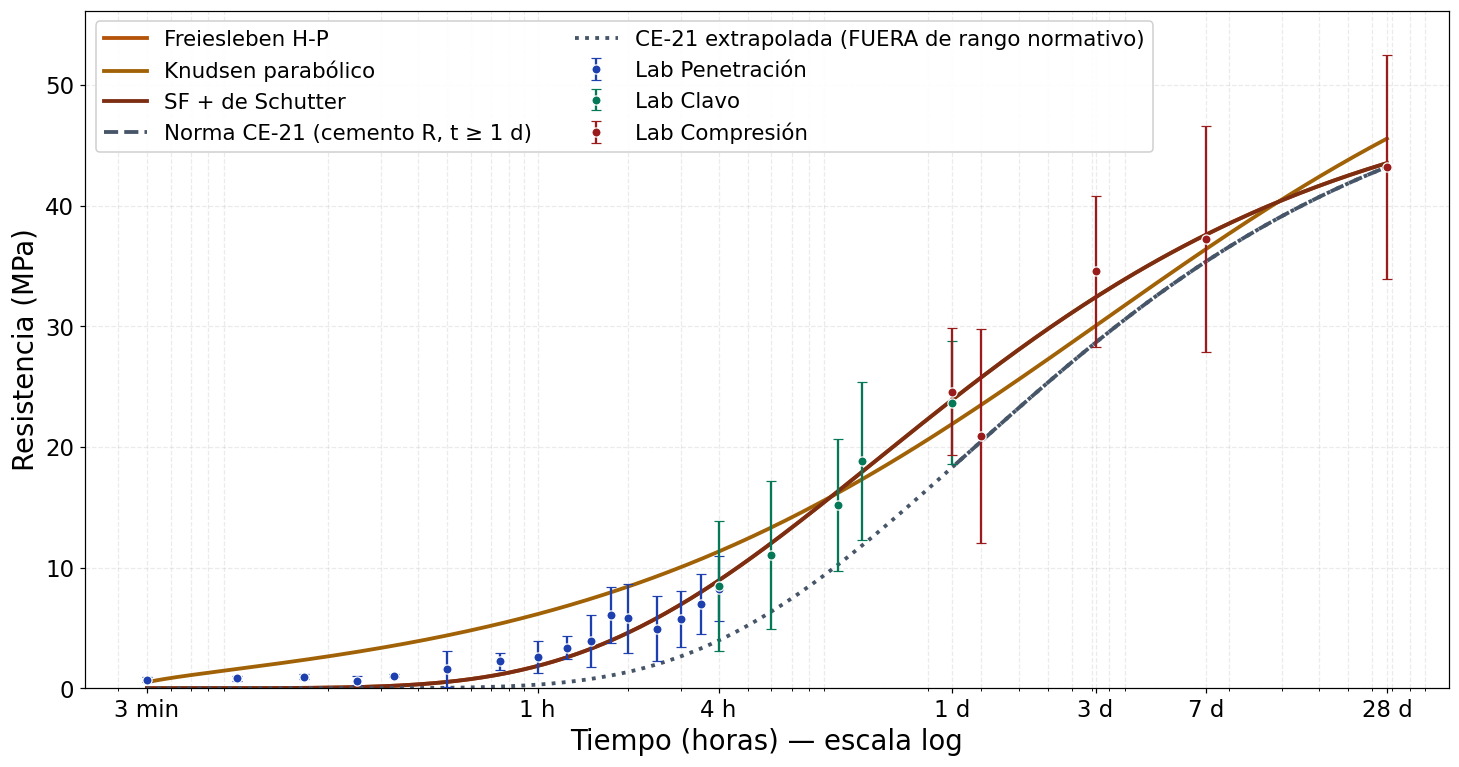

    figura guardada: figuras/fig_4_curvas_fisicas.pdf
    AVISO figura de hidratación: alpha_0 = 0, así que alpha(t) no es única;
    la curva dibujada es una de las infinitas equivalentes. Dilo en el pie.


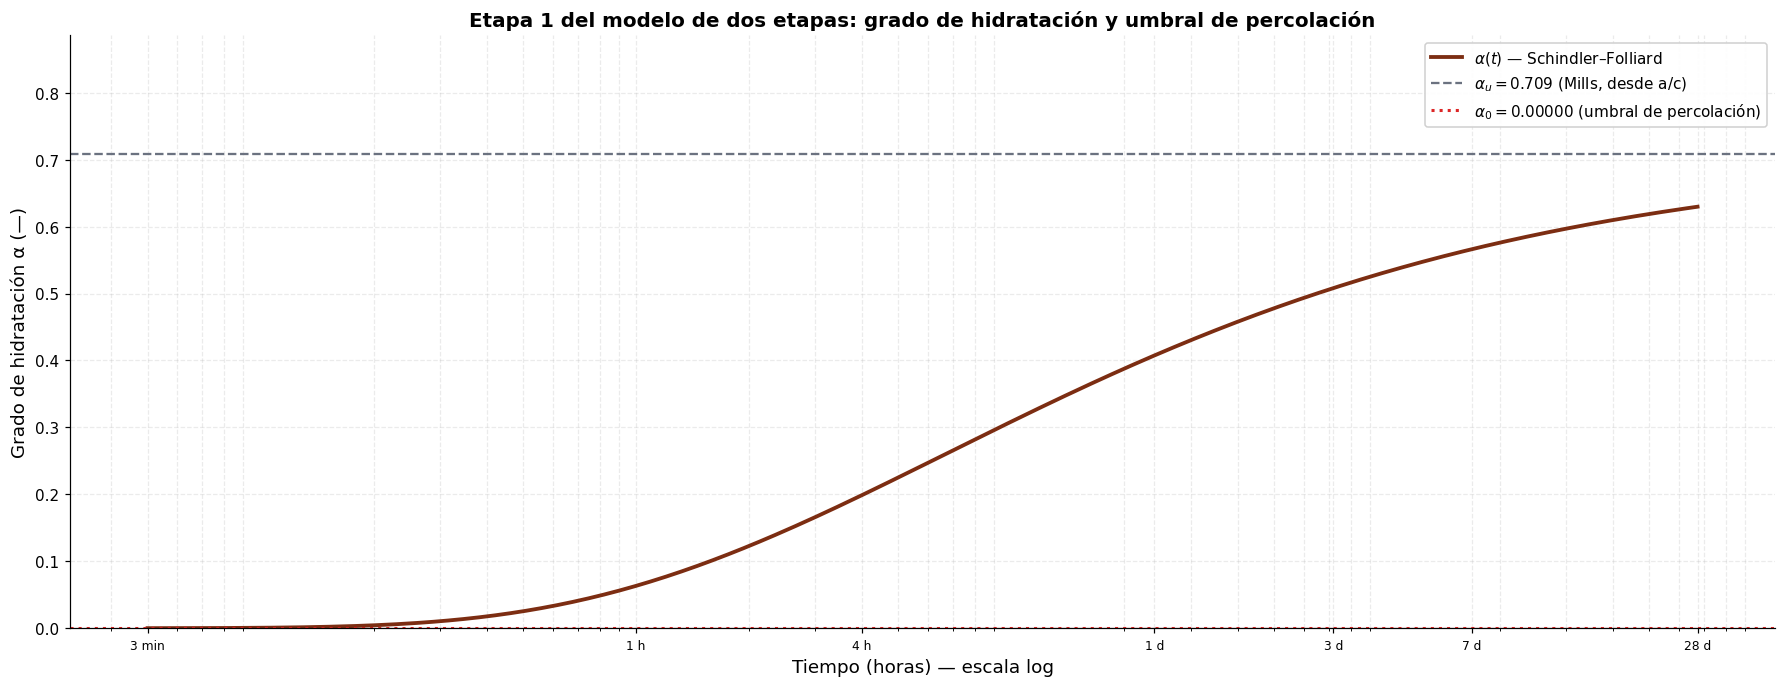

    figura guardada: figuras/fig_4_grado_hidratacion.pdf


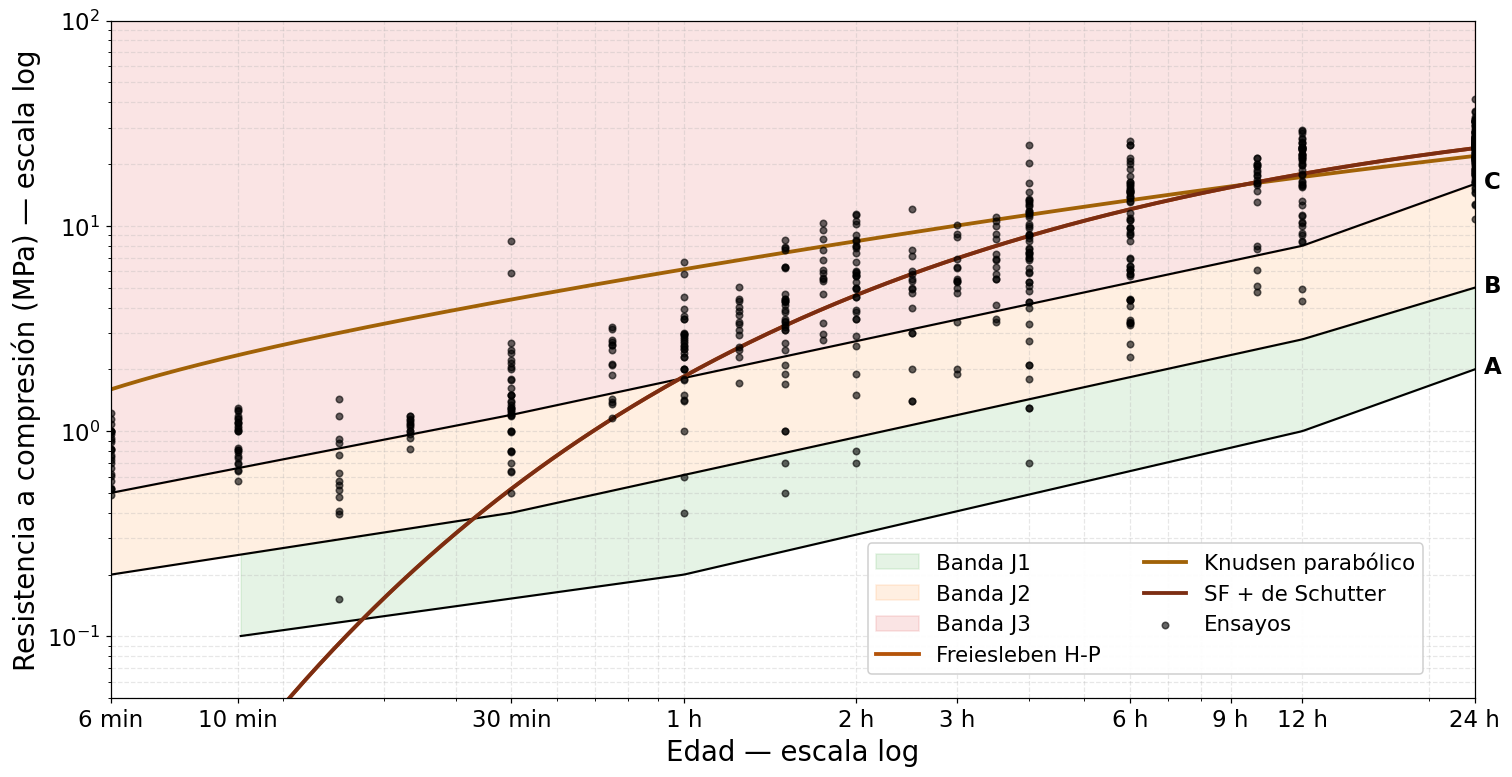

    figura guardada: figuras/fig_4_clases_J.pdf


In [8]:
# ==============================================================================
# CELDA 4 — MODELOS FÍSICOS, NORMA CE-21, CLASES J Y LÍNEAS BASE
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── Interruptores de configuración ──────────────────────────────────────────
INCLUIR_KNUDSEN_LINEAL   = False
DST_ANCLAR_R28           = False
DST_ALPHA_U_MILLS        = True
DST_ALPHA_U_FIJO         = 0.75
CE21_MOSTRAR_FUERA_RANGO = True
EXTRAPOLAR_CURVA_A       = False

COEF_S_CE21 = {'R': 0.20, 'N': 0.25, 'S': 0.38}


def _mostrar(texto_md, latex=None):
    try:
        from IPython.display import display, Markdown, Math
        display(Markdown(texto_md))
        if latex:
            display(Math(latex))
    except Exception:
        print(texto_md)
        if latex:
            print(latex)


# ══════════════════════════════════════════════════════════════════════════
#  MODELOS
# ══════════════════════════════════════════════════════════════════════════

def modelo_fhp(t, R_max, tau, beta):
    return R_max * np.exp(-(tau / np.maximum(t, 1e-6)) ** beta)


def modelo_knudsen_parabolico(t, R_inf, t50, t0):
    dt = np.maximum(np.asarray(t, dtype=float) - t0, 0.0)
    raiz = np.sqrt(dt)
    return R_inf * raiz / (np.sqrt(t50) + raiz)


def modelo_knudsen_lineal(t, R_inf, t50, t0):
    dt = np.maximum(np.asarray(t, dtype=float) - t0, 0.0)
    return R_inf * dt / (t50 + dt)


def modelo_sf(t, tau, beta, alpha_u):
    return alpha_u * np.exp(-(tau / np.maximum(t, 1e-6)) ** beta)


def modelo_dst(alpha, R_ref, alpha0, a):
    base = (alpha - alpha0) / np.maximum(1.0 - alpha0, 1e-9)
    return R_ref * np.power(np.clip(base, 0.0, None), a)


def modelo_sf_dst(t, R_ref, tau, beta, alpha0, a, alpha_u):
    return modelo_dst(modelo_sf(t, tau, beta, alpha_u), R_ref, alpha0, a)


def modelo_ce21(horas, R_28, tipo=CFG_TIPO_CEMENTO, forzar_fuera_rango=False):
    s = COEF_S_CE21[tipo]
    dias = np.asarray(horas, dtype=float) / 24.0
    with np.errstate(divide='ignore', invalid='ignore'):
        beta_todo = np.exp(s * (1.0 - np.sqrt(28.0 / np.maximum(dias, 1e-9))))
        beta = beta_todo if forzar_fuera_rango else np.where(dias >= 1.0, beta_todo, np.nan)
    return R_28 * beta


# ══════════════════════════════════════════════════════════════════════════
#  COMPROBACIONES DE LAS FÓRMULAS
# ══════════════════════════════════════════════════════════════════════════
def _comprobar_formulas():
    t = np.logspace(-2, 3, 60)
    pruebas = [
        ("FHP: en t = tau, R = R_max/e  (definición de tau)",
         np.isclose(modelo_fhp(2.0, 30.0, 2.0, 0.7), 30.0 / np.e)),
        ("FHP: R -> R_max cuando t -> infinito",
         np.isclose(modelo_fhp(1e9, 30.0, 2.0, 0.7), 30.0, rtol=1e-3)),
        ("Knudsen parabólico: R(t0 + t50) = R_inf/2  (definición de t50)",
         np.isclose(modelo_knudsen_parabolico(0.05 + 3.0, 40.0, 3.0, 0.05), 20.0)),
        ("Knudsen lineal: R(t0 + t50) = R_inf/2",
         np.isclose(modelo_knudsen_lineal(0.05 + 3.0, 40.0, 3.0, 0.05), 20.0)),
        ("Knudsen: R = 0 para t <= t0",
         float(modelo_knudsen_parabolico(0.04, 40.0, 3.0, 0.05)) == 0.0),
        ("Schindler-Folliard: alpha(t = tau) = alpha_u/e",
         np.isclose(modelo_sf(2.0, 2.0, 0.7, 0.8), 0.8 / np.e)),
        ("de Schutter-Taerwe: R = 0 por debajo de alpha0 y R = R_ref en alpha = 1",
         float(modelo_dst(0.05, 50.0, 0.1, 1.5)) == 0.0
         and np.isclose(modelo_dst(1.0, 50.0, 0.1, 1.5), 50.0)),
        ("Anidamiento: SF+dS-T con alpha0 = 0, a = 1 es FHP con R_max = R_ref*alpha_u",
         np.allclose(modelo_sf_dst(t, 50.0, 2.0, 0.7, 0.0, 1.0, 0.8),
                     modelo_fhp(t, 50.0 * 0.8, 2.0, 0.7))),
        ("Mills (1966): alpha_u(a/c = 0,40) = 1,031·0,40/(0,194+0,40) = 0,6943",
         np.isclose(1.031 * 0.40 / (0.194 + 0.40), 0.6943, atol=1e-4)),
        ("CE-21: beta_cc(28 d) = 1, así que R(672 h) = R_28",
         np.isclose(float(modelo_ce21(672.0, 40.0)), 40.0)),
        ("CE-21: s = 0,20 / 0,25 / 0,38 para cemento R / N / S",
         COEF_S_CE21 == {'R': 0.20, 'N': 0.25, 'S': 0.38}),
        ("CE-21: no se evalúa por debajo de 1 día",
         bool(np.isnan(modelo_ce21(12.0, 40.0)))),
    ]
    fallos = [d for d, ok in pruebas if not ok]
    for d, ok in pruebas:
        print(f"    {'OK   ' if ok else 'FALLO'} {d}")
    assert not fallos, f"Fórmulas que no cumplen su definición: {fallos}"
    return len(pruebas)

print("=" * 78)
print("  CELDA 4 — COMPROBACIÓN DE LAS FÓRMULAS")
print("=" * 78)
print(f"  {_comprobar_formulas()} comprobaciones superadas.")


# ══════════════════════════════════════════════════════════════════════════
#  AJUSTE
# ══════════════════════════════════════════════════════════════════════════

_ERRORES_AJUSTE = (RuntimeError, ValueError)

def _ajustar_curva(funcion, t, y, p0, limites, con_cov=False):
    popt, pcov = curve_fit(funcion, t, y, p0=p0, bounds=limites, maxfev=40000)
    return (popt, pcov) if con_cov else popt


def _avisar_limites(nombre, popt, limites, etiquetas):
    inf, sup = (np.asarray(l, float) for l in limites)
    for p, a, b, e in zip(popt, inf, sup, etiquetas):
        tol = 1e-3 * max(abs(b - a), 1e-12)
        if p <= a + tol or p >= b - tol:
            lado = 'inferior' if p <= a + tol else 'superior'
            print(f"    AVISO {nombre}: {e} = {p:.4g} está en su límite {lado} "
                  f"({a if lado == 'inferior' else b:.4g}); lo decide la cota.")


CFG_COTA_R_INF = 0.3

def _limites_knudsen(t, y):
    R = float(np.max(y))
    t_min = float(np.min(t[t > 0])) if np.any(t > 0) else 0.1
    t0_sup = max(1e-4, 0.9 * t_min)
    p0 = [R * 1.5, float(np.median(t)), min(t0_sup * 0.5, 0.05)]
    lim = ([R * CFG_COTA_R_INF, 1e-3, 0.0], [R * 4.0, 1e4, t0_sup])
    return p0, lim


_IDX_AC = CFG_FEATURES.index('relacion_ac') if 'relacion_ac' in CFG_FEATURES else None

def _alpha_u(tr):
    if not DST_ALPHA_U_MILLS or _IDX_AC is None:
        return float(DST_ALPHA_U_FIJO)
    _, primera = np.unique(tr['g'], return_index=True)
    wc = float(np.nanmean(tr['X'][primera, _IDX_AC]))
    if not np.isfinite(wc) or wc <= 0:
        return float(DST_ALPHA_U_FIJO)
    return float(np.clip(1.031 * wc / (0.194 + wc), 0.05, 1.0))


def _r28_entrenamiento(tr):
    m = np.isclose(tr['t'], 672.0)
    return float(tr['y'][m].mean()) if m.sum() >= 3 else None


_LIM_DST = ([0.4, 1e-3, 0.05, 0.0, 0.2], [6.0, 500.0, 5.0, 0.30, 5.0])

def _ajuste_sf_dst(t, y, alpha_u, R_ancla=None, con_cov=False):
    R = float(np.max(y))
    if R_ancla is None:
        def f(tt, R_ref, tau, beta, alpha0, a):
            return modelo_sf_dst(tt, R_ref, tau, beta, alpha0, a, alpha_u)
        p0  = [R * 1.3, 1.0, 0.5, 0.01, 1.0]
        lim = ([R * _LIM_DST[0][0]] + _LIM_DST[0][1:],
               [R * _LIM_DST[1][0]] + _LIM_DST[1][1:])
        popt, pcov = _ajustar_curva(f, t, y, p0, lim, con_cov=True)
        if con_cov:
            return popt, 5, np.sqrt(np.diag(pcov)), lim
        return popt, 5

    def g(tt, tau, beta, alpha0, a):
        return modelo_sf_dst(tt, R_ancla, tau, beta, alpha0, a, alpha_u)
    p0  = [1.0, 0.5, 0.01, 1.0]
    lim = (_LIM_DST[0][1:], _LIM_DST[1][1:])
    popt, pcov = _ajustar_curva(g, t, y, p0, lim, con_cov=True)
    popt_c = np.concatenate([[R_ancla], popt])
    if con_cov:
        err = np.concatenate([[0.0], np.sqrt(np.diag(pcov))])
        return popt_c, 4, err, ([R_ancla] + list(lim[0]), [R_ancla] + list(lim[1]))
    return popt_c, 4


def _sin_convergencia(te):
    return np.full(len(te['y']), np.nan)


def ajustar_fhp(tr, te):
    R = tr['y'].max()
    try:
        p = _ajustar_curva(modelo_fhp, tr['t'], tr['y'], [R * 1.5, 1.0, 0.5],
                           ([R * CFG_COTA_R_INF, 1e-3, 0.05], [R * 4.0, 50.0, 5.0]))
    except _ERRORES_AJUSTE:
        return _sin_convergencia(te)
    return modelo_fhp(te['t'], *p)


def ajustar_knudsen_parabolico(tr, te):
    p0, lim = _limites_knudsen(tr['t'], tr['y'])
    try:
        p = _ajustar_curva(modelo_knudsen_parabolico, tr['t'], tr['y'], p0, lim)
    except _ERRORES_AJUSTE:
        return _sin_convergencia(te)
    return modelo_knudsen_parabolico(te['t'], *p)


def ajustar_knudsen_lineal(tr, te):
    p0, lim = _limites_knudsen(tr['t'], tr['y'])
    try:
        p = _ajustar_curva(modelo_knudsen_lineal, tr['t'], tr['y'], p0, lim)
    except _ERRORES_AJUSTE:
        return _sin_convergencia(te)
    return modelo_knudsen_lineal(te['t'], *p)


def ajustar_sf_dst(tr, te):
    au = _alpha_u(tr)
    R28 = _r28_entrenamiento(tr) if DST_ANCLAR_R28 else None
    try:
        popt, _ = _ajuste_sf_dst(tr['t'], tr['y'], au, R28)
    except _ERRORES_AJUSTE:
        return _sin_convergencia(te)
    return modelo_sf_dst(te['t'], *popt, au)


def ajustar_ce21(tr, te):
    R28 = _r28_entrenamiento(tr)
    if R28 is None:
        return _sin_convergencia(te)
    return modelo_ce21(te['t'], R28)


def base_media_global(tr, te):
    return np.full(len(te['y']), tr['y'].mean())


# ══════════════════════════════════════════════════════════════════════════
#  CLASES J  (CE-21 Anejo 9, fig. A9.7.2.3.2 / UNE-EN 14487-1)
# ══════════════════════════════════════════════════════════════════════════
CURVAS_J = {
    'A': {'t': [10/60,        1.0, 12.0, 24.0], 'R': [0.1, 0.2, 1.0,  2.0]},
    'B': {'t': [ 6/60, 30/60, 12.0, 24.0],      'R': [0.2, 0.4, 2.8,  5.0]},
    'C': {'t': [ 6/60, 30/60, 12.0, 24.0],      'R': [0.5, 1.2, 8.0, 16.0]},
}
ETIQUETAS_J = ['< J1', 'J1', 'J2', 'J3']


def curva_J(nombre, horas):
    d = CURVAS_J[nombre]
    t_ref = np.asarray(d['t'], dtype=float)
    R_ref = np.asarray(d['R'], dtype=float)
    h = np.atleast_1d(np.asarray(horas, dtype=float))
    out = np.full(h.shape, np.nan)

    t_min = t_ref[0]
    if nombre == 'A' and EXTRAPOLAR_CURVA_A:
        t_min = CURVAS_J['B']['t'][0]
    valido = (h >= t_min) & (h <= t_ref[-1]) & (h > 0)
    if valido.any():
        out[valido] = 10.0 ** np.interp(np.log10(h[valido]),
                                        np.log10(t_ref), np.log10(R_ref))
    return out


def clasificar_J(horas, resistencia):
    h = np.atleast_1d(np.asarray(horas, dtype=float))
    R = np.atleast_1d(np.asarray(resistencia, dtype=float))
    A, B, C = curva_J('A', h), curva_J('B', h), curva_J('C', h)

    etiquetas = np.full(h.shape, 'n/d', dtype=object)
    for i in range(len(h)):
        if not np.isfinite(R[i]) or not np.isfinite(B[i]):
            continue
        if R[i] >= C[i]:
            etiquetas[i] = 'J3'
        elif R[i] >= B[i]:
            etiquetas[i] = 'J2'
        elif np.isfinite(A[i]):
            etiquetas[i] = 'J1' if R[i] >= A[i] else '< J1'
    return etiquetas


def matriz_confusion_J(horas, y_real, y_pred, titulo='Clases J'):
    real = clasificar_J(horas, y_real)
    pred = clasificar_J(horas, y_pred)
    usable = np.array([(a in ETIQUETAS_J) and (b in ETIQUETAS_J)
                       for a, b in zip(real, pred)])
    n_total, n_usable = len(real), int(usable.sum())
    print(f"\n  {titulo}")
    if n_usable == 0:
        print("    sin puntos clasificables (todas las edades fuera de 6 min - 24 h)")
        return None
    idx = {e: j for j, e in enumerate(ETIQUETAS_J)}
    M = np.zeros((len(ETIQUETAS_J), len(ETIQUETAS_J)), dtype=int)
    for a, b in zip(real[usable], pred[usable]):
        M[idx[a], idx[b]] += 1
    print(f"    puntos clasificables: {n_usable} de {n_total}"
          f"   |   acierto simple: {np.trace(M) / n_usable:6.1%}"
          f"   |   equilibrado: "
          f"{_acierto_equilibrado(real[usable], pred[usable]):6.1%}")
    print(' ' * 14 + ''.join(f"{e:>7}" for e in ETIQUETAS_J) + '   (predicho)')
    for j, e in enumerate(ETIQUETAS_J):
        print(f"    real {e:<7}" + ''.join(f"{v:>7d}" for v in M[j]))
    return M


def _acierto_equilibrado(real, pred):
    clases = [c for c in ETIQUETAS_J if np.any(real == c)]
    return float(np.mean([np.mean(pred[real == c] == c) for c in clases]))


def acierto_J_particiones(nombre):
    if nombre not in PRED:
        return None
    aciertos, equilibrados, tamanos = [], [], []
    for i, p in enumerate(PRED[nombre]):
        te = FOLDS[i]['te']
        real = clasificar_J(te['t'], te['y'])
        pred = clasificar_J(te['t'], p)
        ok = np.array([(a in ETIQUETAS_J) and (b in ETIQUETAS_J)
                       for a, b in zip(real, pred)])
        if ok.sum() < CFG_MIN_TEST_METRICA:
            continue
        aciertos.append(float(np.mean(real[ok] == pred[ok])))
        equilibrados.append(_acierto_equilibrado(real[ok], pred[ok]))
        tamanos.append(int(ok.sum()))
    if not aciertos:
        return None
    return dict(acierto=float(np.mean(aciertos)), sd=float(np.std(aciertos)),
                equilibrado=float(np.mean(equilibrados)),
                equilibrado_sd=float(np.std(equilibrados)),
                n=int(np.mean(tamanos)), particiones=len(aciertos))


def _aicc(y, y_pred, k):
    m = np.isfinite(y) & np.isfinite(y_pred)
    n = int(m.sum())
    if n <= k + 1:
        return np.nan
    rss = float(np.sum((y[m] - y_pred[m]) ** 2))
    if rss <= 0:
        return -np.inf
    return n * np.log(rss / n) + 2 * k + (2 * k * (k + 1)) / (n - k - 1)


# ══════════════════════════════════════════════════════════════════════════
#  EVALUACIÓN POR PARTICIONES
# ══════════════════════════════════════════════════════════════════════════
print("=" * 78)
print("  CELDA 4 — MODELOS FÍSICOS, NORMA, CLASES J Y LÍNEAS BASE")
print("=" * 78)

MODELOS_CELDA4 = [
    ('Base: media global',  base_media_global),
    ('Freiesleben H-P',     ajustar_fhp),
    ('Knudsen parabólico',  ajustar_knudsen_parabolico),
    ('SF + de Schutter',    ajustar_sf_dst),
    ('Norma CE-21',         ajustar_ce21),
]
if INCLUIR_KNUDSEN_LINEAL:
    MODELOS_CELDA4.insert(3, ("Knudsen lineal", ajustar_knudsen_lineal))

for _nombre, _fn in MODELOS_CELDA4:
    registrar(_nombre, para_cada_particion(_fn, etiqueta=_nombre))
registrar('Base: sólo tiempo', PRED_BASE_PUNTO)

METODOS_C4 = ['Base: media global', 'Base: sólo tiempo'] + \
             [n for n, _ in MODELOS_CELDA4 if n != 'Base: media global']
MODELOS_CELDA4 = [(n, None) for n in METODOS_C4]

MASC_C4 = imprimir_tablas_mascaras(METODOS_C4, 'MODELOS FÍSICOS Y BASES', con_base=False)
print("  Estos modelos sólo miran el reloj: a cada edad predicen lo mismo para todas")
print("  las mezclas. Su R² medio por punto no puede superar, salvo por azar, al de")
print("  'Base: sólo tiempo' (la media de cada edad): mide cuánto se aleja su curva")
print("  de esa media, no capacidad de distinguir mezclas.")
print("  Norma CE-21: sólo definida desde 1 día; '—' en penetración y clavo.")


# ══════════════════════════════════════════════════════════════════════════
#  ACIERTO DE CLASE J SOBRE MEZCLAS NO VISTAS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "-" * 90)
print("  Clases J — acierto sobre mezclas NO VISTAS (mismas particiones)")
print("-" * 90)
_et_real = clasificar_J(T_ALL, Y_ALL)
_et_real = _et_real[np.isin(_et_real, ETIQUETAS_J)]
_mayoritaria = max(ETIQUETAS_J, key=lambda c: np.sum(_et_real == c))
_frac_may = float(np.mean(_et_real == _mayoritaria))
print("  Reparto real de clases (todos los ensayos clasificables): "
      + ', '.join(f"{c} {np.sum(_et_real == c)}" for c in ETIQUETAS_J))
print(f"  Referencia: decir siempre '{_mayoritaria}' acierta el {_frac_may:.1%} "
      f"(equilibrado: {1 / sum(np.any(_et_real == c) for c in ETIQUETAS_J):.1%}).")
print(f"\n    {'Método':<20} {'acierto simple':>18} {'acierto equilibrado':>22} "
      f"{'n/part.':>8} {'part.':>6}")
for nombre, _ in MODELOS_CELDA4:
    d = acierto_J_particiones(nombre)
    if d is None:
        print(f"    {nombre:<20} sin puntos clasificables suficientes")
    else:
        print(f"    {nombre:<20} {d['acierto']:>9.1%} ± {d['sd']:>5.1%} "
              f"{d['equilibrado']:>13.1%} ± {d['equilibrado_sd']:>5.1%} "
              f"{d['n']:>8} {d['particiones']:>6}")
print("    Rango clasificable: 6 min - 24 h. Fuera de él el diagrama no define clase.")
print("    Acierto simple      = % de ensayos con la clase correcta. Lo infla la")
print(f"                          clase mayoritaria ({_mayoritaria}).")
print("    Acierto equilibrado = media del acierto dentro de cada clase real: la")
print("                          cifra que dice si el modelo DISTINGUE clases.")


# ══════════════════════════════════════════════════════════════════════════
#  CONSTANTES DEFINITIVAS (ajuste con el 100 % de los ensayos)
# ══════════════════════════════════════════════════════════════════════════
_R = Y_ALL.max()
print("\n" + "-" * 78)
print("  Comprobación de límites de los ajustes al 100 %")
print("-" * 78)

_LIM_FHP = ([_R * CFG_COTA_R_INF, 1e-3, 0.05], [_R * 4.0, 50.0, 5.0])
POPT_FHP, PCOV_FHP = curve_fit(
    modelo_fhp, T_ALL, Y_ALL, p0=[_R * 1.5, 1.0, 0.5],
    bounds=_LIM_FHP, maxfev=40000)
ERR_FHP = np.sqrt(np.diag(PCOV_FHP))
_avisar_limites('Freiesleben H-P', POPT_FHP, _LIM_FHP, ['R_max', 'tau', 'beta'])

_p0_k, _lim_k = _limites_knudsen(T_ALL, Y_ALL)
POPT_KNU_PAR, PCOV_KNU_PAR = curve_fit(
    modelo_knudsen_parabolico, T_ALL, Y_ALL, p0=_p0_k, bounds=_lim_k, maxfev=40000)
ERR_KNU_PAR = np.sqrt(np.diag(PCOV_KNU_PAR))
_avisar_limites('Knudsen parabólico', POPT_KNU_PAR, _lim_k, ['R_inf', 't50', 't0'])

if INCLUIR_KNUDSEN_LINEAL:
    POPT_KNU_LIN, PCOV_KNU_LIN = curve_fit(
        modelo_knudsen_lineal, T_ALL, Y_ALL, p0=_p0_k, bounds=_lim_k, maxfev=40000)
    ERR_KNU_LIN = np.sqrt(np.diag(PCOV_KNU_LIN))
    _avisar_limites('Knudsen lineal', POPT_KNU_LIN, _lim_k, ['R_inf', 't50', 't0'])

_WC_GLOBAL = float(np.mean(X_IMP_APP[MEZCLAS_USADAS, _IDX_AC])) if _IDX_AC is not None else np.nan
ALPHA_U_GLOBAL = (float(np.clip(1.031 * _WC_GLOBAL / (0.194 + _WC_GLOBAL), 0.05, 1.0))
                  if (DST_ALPHA_U_MILLS and np.isfinite(_WC_GLOBAL))
                  else float(DST_ALPHA_U_FIJO))

_fila28 = DATOS_LAB[(DATOS_LAB['serie'] == 'Compresión') & np.isclose(DATOS_LAB['horas'], 672.0)]
assert len(_fila28) == 1, "No se encuentra la media de laboratorio de compresión a 28 d"
R_28_LAB = float(_fila28['media'].iloc[0])

_R28_ANCLA = R_28_LAB if DST_ANCLAR_R28 else None
POPT_DST, K_DST, ERR_DST, _LIM_DST_FINAL = _ajuste_sf_dst(
    T_ALL, Y_ALL, ALPHA_U_GLOBAL, _R28_ANCLA, con_cov=True)
_avisar_limites('SF + de Schutter', POPT_DST, _LIM_DST_FINAL,
                ['R_ref', 'tau', 'beta', 'alpha_0', 'a'])

DST_SIN_UMBRAL = bool(POPT_DST[3] <= 1e-3 * _LIM_DST[1][3])
DST_NO_IDENTIF = [bool(e > abs(p)) for p, e in zip(POPT_DST, ERR_DST)]
if DST_SIN_UMBRAL:
    print("    SF + de Schutter: alpha_0 = 0 -> el ajuste COINCIDE con FHP y "
          "R_ref, tau y a no")
    print("      son identificables por separado (se marcan 'n.i.' en la tabla "
          "LaTeX).")
print("    (sin más avisos: ningún otro parámetro está en su límite)")

print("\n" + "-" * 78)
print("  Constantes ajustadas con el 100 % de los ensayos (para la memoria)")
print("-" * 78)
print(f"    Freiesleben H-P      R_max={POPT_FHP[0]:.2f}±{ERR_FHP[0]:.2f}  "
      f"tau={POPT_FHP[1]:.3f}±{ERR_FHP[1]:.3f} h  "
      f"beta={POPT_FHP[2]:.4f}±{ERR_FHP[2]:.4f}")
print(f"    Knudsen parabólico   R_inf={POPT_KNU_PAR[0]:.2f}±{ERR_KNU_PAR[0]:.2f}  "
      f"t50={POPT_KNU_PAR[1]:.3f}±{ERR_KNU_PAR[1]:.3f} h  "
      f"t0={POPT_KNU_PAR[2]:.4f}±{ERR_KNU_PAR[2]:.4f} h")
if INCLUIR_KNUDSEN_LINEAL:
    print(f"    Knudsen lineal       R_inf={POPT_KNU_LIN[0]:.2f}±{ERR_KNU_LIN[0]:.2f}  "
          f"t50={POPT_KNU_LIN[1]:.3f}±{ERR_KNU_LIN[1]:.3f} h  "
          f"t0={POPT_KNU_LIN[2]:.4f}±{ERR_KNU_LIN[2]:.4f} h")
print(f"    SF + de Schutter     R_ref={POPT_DST[0]:.2f}±{ERR_DST[0]:.2f}  "
      f"tau={POPT_DST[1]:.3f}±{ERR_DST[1]:.3f} h  beta={POPT_DST[2]:.4f}±{ERR_DST[2]:.4f}")
print(f"                         alpha_0={POPT_DST[3]:.5f}±{ERR_DST[3]:.5f}  "
      f"a={POPT_DST[4]:.4f}±{ERR_DST[4]:.4f}  "
      f"alpha_u={ALPHA_U_GLOBAL:.4f} (fijado, no ajustado)")
_R_ASINT_DST = float(modelo_dst(ALPHA_U_GLOBAL, POPT_DST[0], POPT_DST[3], POPT_DST[4]))
print(f"                         resistencia asintótica real = R(alpha_u) = "
      f"{_R_ASINT_DST:.2f} MPa (R_ref es la de alpha = 1)")
print(f"    Norma CE-21          R_28={R_28_LAB:.2f} MPa  "
      f"s={COEF_S_CE21[CFG_TIPO_CEMENTO]} (cemento {CFG_TIPO_CEMENTO})")
if DST_SIN_UMBRAL:
    print("\n    Umbral de percolación: NO detectado (alpha_0 = 0, en su límite inferior).")
else:
    print(f"\n    Umbral de percolación ajustado: alpha_0 = {POPT_DST[3]:.5f}"
          f"  ->  hidratación necesaria antes de la primera resistencia medible.")


# ══════════════════════════════════════════════════════════════════════════
#  ¿PAGAN SU COSTE alpha_0 Y a?  (modelos anidados: FHP ⊂ SF+dS-T)
# ══════════════════════════════════════════════════════════════════════════
_pred_fhp = modelo_fhp(T_ALL, *POPT_FHP)
_pred_par = modelo_knudsen_parabolico(T_ALL, *POPT_KNU_PAR)
_pred_dst = modelo_sf_dst(T_ALL, *POPT_DST, ALPHA_U_GLOBAL)

_tabla_aicc = [('Freiesleben H-P', _aicc(Y_ALL, _pred_fhp, 3), 3),
               ('Knudsen parabólico', _aicc(Y_ALL, _pred_par, 3), 3),
               ('SF + de Schutter', _aicc(Y_ALL, _pred_dst, K_DST), K_DST)]
if INCLUIR_KNUDSEN_LINEAL:
    _pred_lin = modelo_knudsen_lineal(T_ALL, *POPT_KNU_LIN)
    _tabla_aicc.insert(2, ('Knudsen lineal', _aicc(Y_ALL, _pred_lin, 3), 3))

print("\n" + "-" * 78)
print("  Selección de modelo por AICc (ajuste con el 100 % de los ensayos)")
print("-" * 78)
_mejor = min(a for _, a, _ in _tabla_aicc if np.isfinite(a))
for _n, _a, _k in _tabla_aicc:
    print(f"    {_n:<20} k={_k}   AICc = {_a:10.2f}   Delta = {_a - _mejor:8.2f}")
_d_anidado = _tabla_aicc[0][1] - _tabla_aicc[-1][1]
print(f"\n    FHP está ANIDADO en SF + de Schutter (alpha_0 = 0, para cualquier a).")
print(f"    Delta AICc (FHP - SF+dS-T) = {_d_anidado:.2f}")
if DST_SIN_UMBRAL:
    print("    El ajuste da alpha_0 = 0: SF+dS-T reproduce EXACTAMENTE la curva de FHP")
    print("    y el Delta es sólo la penalización por sus parámetros extra. Con esta")
    print("    base de datos NO se detecta umbral de percolación: la resistencia es")
    print("    medible desde el primer ensayo (3 min), coherente con el uso de")
    print("    acelerante. Es un resultado reportable, no un fallo del ajuste.")
elif abs(_d_anidado) < 2:
    print("    |Delta| < 2: los datos NO permiten separar ambos modelos. El umbral")
    print("    de percolación no es detectable con esta base de datos. Dilo así.")
elif _d_anidado > 0:
    print("    SF + de Schutter mejora a FHP pese al castigo por parámetros extra:")
    print("    el umbral de percolación aporta información real.")
else:
    print("    FHP es preferible: los dos parámetros extra no se pagan. Es un")
    print("    resultado legítimo y reportable, no un fallo del ajuste.")
print("    AVISO: este AICc se calcula sobre el ajuste al 100 %, no sobre las")
print("    particiones. Mide parsimonia del ajuste, NO generalización. La cifra")
print("    de generalización es la tabla de R²/MAE de arriba.")


# ══════════════════════════════════════════════════════════════════════════
#  MATRICES DE CONFUSIÓN J CON EL AJUSTE AL 100 % (descriptivas)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "-" * 78)
print("  Clases J — ajuste con el 100 % de los datos (OPTIMISTA, descriptivo)")
print("-" * 78)
matriz_confusion_J(T_ALL, Y_ALL, _pred_fhp, 'Freiesleben H-P')
matriz_confusion_J(T_ALL, Y_ALL, _pred_par, 'Knudsen parabólico')
matriz_confusion_J(T_ALL, Y_ALL, _pred_dst, 'SF + de Schutter')


# ══════════════════════════════════════════════════════════════════════════
#  EXPRESIONES Y TABLA PARA LA MEMORIA
# ══════════════════════════════════════════════════════════════════════════
def _red(x, formato):
    return float(format(float(x), formato))

_EQ_FHP = dict(R_max=_red(POPT_FHP[0], '.2f'), tau=_red(POPT_FHP[1], '.3f'),
               beta=_red(POPT_FHP[2], '.3f'))
_EQ_KNU = dict(R_inf=_red(POPT_KNU_PAR[0], '.2f'), t50=_red(POPT_KNU_PAR[1], '.3f'),
               t0=_red(POPT_KNU_PAR[2], '.4f'))
_EQ_DST = dict(R_ref=_red(POPT_DST[0], '.2f'), tau=_red(POPT_DST[1], '.3f'),
               beta=_red(POPT_DST[2], '.3f'), alpha0=_red(POPT_DST[3], '.5f'),
               a=_red(POPT_DST[4], '.3f'), alpha_u=_red(ALPHA_U_GLOBAL, '.4f'))
_EQ_CE21 = dict(R_28=_red(R_28_LAB, '.1f'), s=COEF_S_CE21[CFG_TIPO_CEMENTO])

_mostrar("**Freiesleben Hansen y Pedersen**",
         rf"R(t) = {_EQ_FHP['R_max']:.2f}\,\exp\left[-\left(\frac{{{_EQ_FHP['tau']:.3f}}}{{t}}"
         rf"\right)^{{{_EQ_FHP['beta']:.3f}}}\right]")
_mostrar("**Knudsen parabólico** (dispersión, control por difusión)",
         rf"R(t) = {_EQ_KNU['R_inf']:.2f}\,"
         rf"\frac{{\sqrt{{t - {_EQ_KNU['t0']:.4f}}}}}"
         rf"{{\sqrt{{{_EQ_KNU['t50']:.3f}}} + \sqrt{{t - {_EQ_KNU['t0']:.4f}}}}}")
_mostrar("**Schindler–Folliard + de Schutter–Taerwe** (dos etapas)",
         rf"\alpha(t) = {_EQ_DST['alpha_u']:.4f}\,\exp\left[-\left("
         rf"\frac{{{_EQ_DST['tau']:.3f}}}{{t}}\right)^{{{_EQ_DST['beta']:.3f}}}\right]"
         rf"\qquad R(t) = {_EQ_DST['R_ref']:.2f}\left("
         rf"\frac{{\alpha(t) - {_EQ_DST['alpha0']:.5f}}}{{1 - {_EQ_DST['alpha0']:.5f}}}"
         rf"\right)^{{{_EQ_DST['a']:.3f}}}")
_mostrar(f"**Norma CE-21** (cemento {CFG_TIPO_CEMENTO}, válida para t ≥ 1 día)",
         rf"R(t) = {_EQ_CE21['R_28']:.1f}\,\exp\left[{_EQ_CE21['s']}"
         rf"\left(1-\sqrt{{28/t_{{\text{{días}}}}}}\right)\right]")

# ── Verificación: ecuación mostrada ↔ curva de la figura ──
_VERIF_C4 = [
    ('Freiesleben H-P', modelo_fhp(HORAS_EJE, *POPT_FHP),
     modelo_fhp(HORAS_EJE, _EQ_FHP['R_max'], _EQ_FHP['tau'], _EQ_FHP['beta'])),
    ('Knudsen parabólico', modelo_knudsen_parabolico(HORAS_EJE, *POPT_KNU_PAR),
     modelo_knudsen_parabolico(HORAS_EJE, _EQ_KNU['R_inf'], _EQ_KNU['t50'], _EQ_KNU['t0'])),
    ('SF + de Schutter', modelo_sf_dst(HORAS_EJE, *POPT_DST, ALPHA_U_GLOBAL),
     modelo_sf_dst(HORAS_EJE, _EQ_DST['R_ref'], _EQ_DST['tau'], _EQ_DST['beta'],
                   _EQ_DST['alpha0'], _EQ_DST['a'], _EQ_DST['alpha_u'])),
    ('Norma CE-21', modelo_ce21(HORAS_EJE, R_28_LAB),
     modelo_ce21(HORAS_EJE, _EQ_CE21['R_28'])),
]
print("\n" + "-" * 78)
print("  Verificación · la ecuación mostrada (redondeada) reproduce la curva de la figura")
print("-" * 78)
for _n, _curva, _ecuacion in _VERIF_C4:
    _m = np.isfinite(_curva) & np.isfinite(_ecuacion)
    _dif = float(np.max(np.abs(_curva[_m] - _ecuacion[_m])))
    _rel = _dif / max(float(np.max(np.abs(_curva[_m]))), 1e-9)
    _dom = int((np.isfinite(_curva) != np.isfinite(_ecuacion)).sum())
    print(f"    {_n:<20} dif. máx = {_dif:.3g} MPa ({_rel:.3%})   dominio ≠ {_dom}   "
          f"{'OK' if (_rel <= 0.01 and _dom == 0) else 'REVISAR'}")
print("    OK = diferencia ≤ 1 % del máximo de la curva; lo que queda es el redondeo.")


def _inc_dst(i, formato):
    if DST_SIN_UMBRAL and DST_NO_IDENTIF[i] and i != 3:
        return 'n.i.'
    return format(ERR_DST[i], formato)


def tabla_latex_parametros_fisicos(etiqueta='tab:param_fisicos'):
    filas = [
        ('Freiesleben H-P', 3,
         [(r'$R_{max}$', f'{POPT_FHP[0]:.2f}', 'MPa', f'{ERR_FHP[0]:.2f}'),
          (r'$\tau$',     f'{POPT_FHP[1]:.3f}', 'h',   f'{ERR_FHP[1]:.3f}'),
          (r'$\beta$',    f'{POPT_FHP[2]:.4f}', '--',  f'{ERR_FHP[2]:.4f}')]),
        ('Knudsen parabólico', 3,
         [(r'$R_{\infty}$', f'{POPT_KNU_PAR[0]:.2f}', 'MPa', f'{ERR_KNU_PAR[0]:.2f}'),
          (r'$t_{50}$',     f'{POPT_KNU_PAR[1]:.3f}', 'h',   f'{ERR_KNU_PAR[1]:.3f}'),
          (r'$t_{0}$',      f'{POPT_KNU_PAR[2]:.4f}', 'h',   f'{ERR_KNU_PAR[2]:.4f}')]),
        ('SF + de Schutter', K_DST,
         [(r'$R_{ref}$',    f'{POPT_DST[0]:.2f}',  'MPa', _inc_dst(0, '.2f')),
          (r'$\tau$',       f'{POPT_DST[1]:.3f}',  'h',   _inc_dst(1, '.3f')),
          (r'$\beta$',      f'{POPT_DST[2]:.4f}',  '--',  _inc_dst(2, '.4f')),
          (r'$\alpha_{0}$', f'{POPT_DST[3]:.5f}',  '--',  _inc_dst(3, '.5f')),
          (r'$a$',          f'{POPT_DST[4]:.4f}',  '--',  _inc_dst(4, '.4f')),
          (r'$\alpha_{u}$', f'{ALPHA_U_GLOBAL:.4f}', '--', 'fijado')]),
    ]
    titulo = ('Constantes de los modelos físicos de caja blanca, ajustadas con el '
              '100\\,\\% de los ensayos. Las incertidumbres son la raíz de la '
              'diagonal de la matriz de covarianza del ajuste. $\\alpha_u$ no se '
              'ajusta: se calcula a partir de la relación agua/cemento media. '
              'n.i. = no identificable: con $\\alpha_0 = 0$ el modelo de dos '
              'etapas se reduce al de Freiesleben Hansen y Pedersen y sólo la '
              'combinación de $R_{ref}$, $\\tau$ y $a$ queda determinada.')
    L = [r'\begin{table}[htbp]', r'  \centering',
         rf'  \caption{{{titulo}}}', rf'  \label{{{etiqueta}}}', r'  \small',
         r'  \begin{tabular}{llrrl}', r'    \toprule',
         r'    \textbf{Modelo} & \textbf{Parámetro} & \textbf{Valor} & '
         r'\textbf{Inc.} & \textbf{Unidad} \\', r'    \midrule']
    for nombre, k, params in filas:
        for j, (sim, val, uni, inc) in enumerate(params):
            col0 = rf'{nombre} ($k={k}$)' if j == 0 else ''
            L.append(rf'    {col0} & {sim} & {val} & {inc} & {uni} \\')
        L.append(r'    \midrule')
    L[-1] = r'    \bottomrule'
    L += [r'  \end{tabular}', r'\end{table}']
    return '\n'.join(L)

print("\n" + "-" * 78)
print("  Tabla LaTeX de parámetros (copiar a Overleaf)")
print("-" * 78)
print(tabla_latex_parametros_fisicos())


# ══════════════════════════════════════════════════════════════════════════
#  FIGURAS
# ══════════════════════════════════════════════════════════════════════════
_series = [
    ('Freiesleben H-P', HORAS_EJE, modelo_fhp(HORAS_EJE, *POPT_FHP),
     COLOR['Freiesleben H-P'], '-'),
    ('Knudsen parabólico', HORAS_EJE,
     modelo_knudsen_parabolico(HORAS_EJE, *POPT_KNU_PAR), COLOR['Knudsen parabólico'], '-'),
    ('SF + de Schutter', HORAS_EJE,
     modelo_sf_dst(HORAS_EJE, *POPT_DST, ALPHA_U_GLOBAL), COLOR['SF + de Schutter'], '-'),
    (f'Norma CE-21 (cemento {CFG_TIPO_CEMENTO}, t ≥ 1 d)',
     HORAS_EJE, modelo_ce21(HORAS_EJE, R_28_LAB), COLOR['Norma CE-21'], '--'),
]
if INCLUIR_KNUDSEN_LINEAL:
    _series.insert(2, ('Knudsen lineal', HORAS_EJE,
                       modelo_knudsen_lineal(HORAS_EJE, *POPT_KNU_LIN),
                       COLOR['Knudsen lineal'], '-'))
if CE21_MOSTRAR_FUERA_RANGO:
    _series.append(('CE-21 extrapolada (FUERA de rango normativo)', HORAS_EJE,
                    modelo_ce21(HORAS_EJE, R_28_LAB, forzar_fuera_rango=True),
                    COLOR['Norma CE-21'], ':'))
figura_curva(_series, 'fig_4_curvas_fisicas')


def figura_grado_hidratacion(archivo='fig_4_grado_hidratacion', figsize=(20.0, 7.0)):
    if DST_SIN_UMBRAL:
        print("    AVISO figura de hidratación: alpha_0 = 0, así que alpha(t) no es "
              "única;")
        print("    la curva dibujada es una de las infinitas equivalentes. Dilo en "
              "el pie.")
    fig, ax = plt.subplots(figsize=figsize)
    a = modelo_sf(HORAS_EJE, POPT_DST[1], POPT_DST[2], ALPHA_U_GLOBAL)
    ax.plot(HORAS_EJE, a, '-', color=COLOR['SF + de Schutter'], lw=2.5,
            label=r'$\alpha(t)$ — Schindler–Folliard')
    ax.axhline(ALPHA_U_GLOBAL, color='#6B7280', ls='--', lw=1.5,
               label=rf'$\alpha_u = {ALPHA_U_GLOBAL:.3f}$ (Mills, desde a/c)')
    ax.axhline(POPT_DST[3], color='#DC2626', ls=':', lw=2.0,
               label=rf'$\alpha_0 = {POPT_DST[3]:.5f}$ (umbral de percolación)')
    ax.fill_between(HORAS_EJE, 0, POPT_DST[3], color='#DC2626', alpha=0.08)
    ax.set_xscale('log')
    ax.set_xticks([3/60, 1, 4, 24, 72, 168, 672])
    ax.set_xticklabels(['3 min', '1 h', '4 h', '1 d', '3 d', '7 d', '28 d'], fontsize=8)
    ax.set_xlabel('Tiempo (horas) — escala log', fontsize=12)
    ax.set_ylabel('Grado de hidratación α (—)', fontsize=12)
    ax.set_ylim(0, min(1.0, ALPHA_U_GLOBAL * 1.25))
    ax.set_title('Etapa 1 del modelo de dos etapas: grado de hidratación y umbral '
                 'de percolación', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.92)
    ax.grid(True, which='both')
    guardar_figura(fig, archivo)

figura_grado_hidratacion()


def figura_clases_J(archivo='fig_4_clases_J', figsize=None):
    e = ESTILO_CURVA
    t_eje = np.logspace(np.log10(6/60), np.log10(24.0), 400)
    fig, ax = plt.subplots(figsize=figsize or e['figsize'])

    A, B, C = curva_J('A', t_eje), curva_J('B', t_eje), curva_J('C', t_eje)
    ax.fill_between(t_eje, A, B, alpha=0.12, color='tab:green',  label='Banda J1')
    ax.fill_between(t_eje, B, C, alpha=0.12, color='tab:orange', label='Banda J2')
    ax.fill_between(t_eje, C, 100, alpha=0.12, color='tab:red',  label='Banda J3')
    for etq, arr in (('A', A), ('B', B), ('C', C)):
        ax.plot(t_eje, arr, color='k', lw=1.4)
        ax.annotate(etq, (t_eje[-1], arr[-1]), textcoords='offset points',
                    xytext=(6, -3), fontsize=e['fs_marcas'], fontweight='bold')

    _curvas = [('Freiesleben H-P', modelo_fhp(t_eje, *POPT_FHP)),
               ('Knudsen parabólico', modelo_knudsen_parabolico(t_eje, *POPT_KNU_PAR)),
               ('SF + de Schutter', modelo_sf_dst(t_eje, *POPT_DST, ALPHA_U_GLOBAL))]
    for etq, vals in _curvas:
        ax.plot(t_eje, vals, lw=e['lw'] + 0.3, color=COLOR[etq], label=etq)

    m = (T_ALL >= 6/60) & (T_ALL <= 24.0)
    ax.scatter(T_ALL[m], Y_ALL[m], s=e['ms'] ** 2 / 2, color='k', zorder=5, alpha=0.6,
               label='Ensayos')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(6/60, 24.0); ax.set_ylim(0.05, 100)
    ticks = [6/60, 10/60, 30/60, 1, 2, 3, 6, 9, 12, 24]
    ax.set_xticks(ticks)
    ax.set_xticklabels(['6 min', '10 min', '30 min', '1 h', '2 h', '3 h',
                        '6 h', '9 h', '12 h', '24 h'], fontsize=e['fs_marcas'])
    ax.tick_params(axis='y', labelsize=e['fs_marcas'])
    ax.set_xlabel('Edad — escala log', fontsize=e['fs_eje'])
    ax.set_ylabel('Resistencia a compresión (MPa) — escala log', fontsize=e['fs_eje'])
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=e['fs_leyenda'], ncol=2, loc='lower right',
              bbox_to_anchor=(0.97, 0.02), framealpha=0.92)
    titulo_figura(ax, 'Clases de resistencia inicial J (CE-21, Anejo 9, fig. A9.7.2.3.2)',
            e['fs_titulo'])
    guardar_figura(fig, archivo)
figura_clases_J()

  CELDA 5 — COMPARATIVA FINAL · particiones 80/20 agrupadas por mezcla
  14 métodos · imputación ajustada dentro de cada partición
  Modelos con el tiempo (2.B, 2.C) entrenados sobre la resistencia en MPa

  COMPARATIVA FINAL · R² agrupado frente a R² medio por punto
                             |           Global            |         Penetración         |            Clavo            |         Compresión         
  Método               Part. |       R² agrupado  R² medio |       R² agrupado  R² medio |       R² agrupado  R² medio |       R² agrupado  R² medio
----------------------------------------------------------------------------------------------------------------------------------------------------
  Base: sólo tiempo       15 |     0.865 ± 0.025    -0.507 |     0.525 ± 0.153    -0.681 |     0.408 ± 0.144    -0.327 |     0.439 ± 0.063    -0.306
  Norma CE-21             15 |     0.332 ± 0.074   -1.055* |                 —         — |    -1.769 ± 1.617   -1.769* |     0.280 ± 0.0

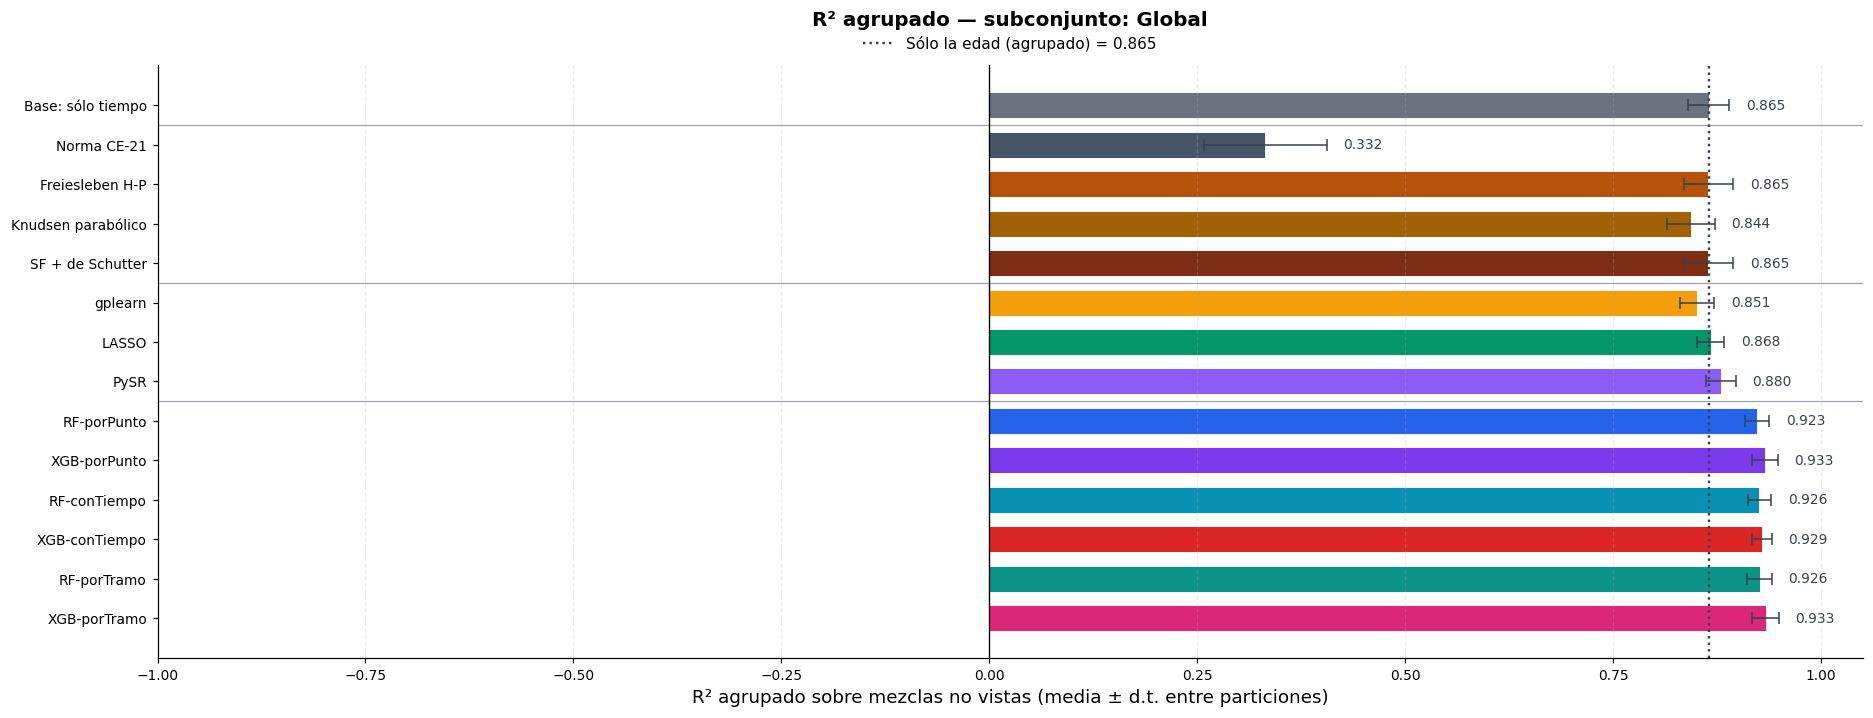

    figura guardada: figuras/fig_5_r2_agrupado_global.pdf


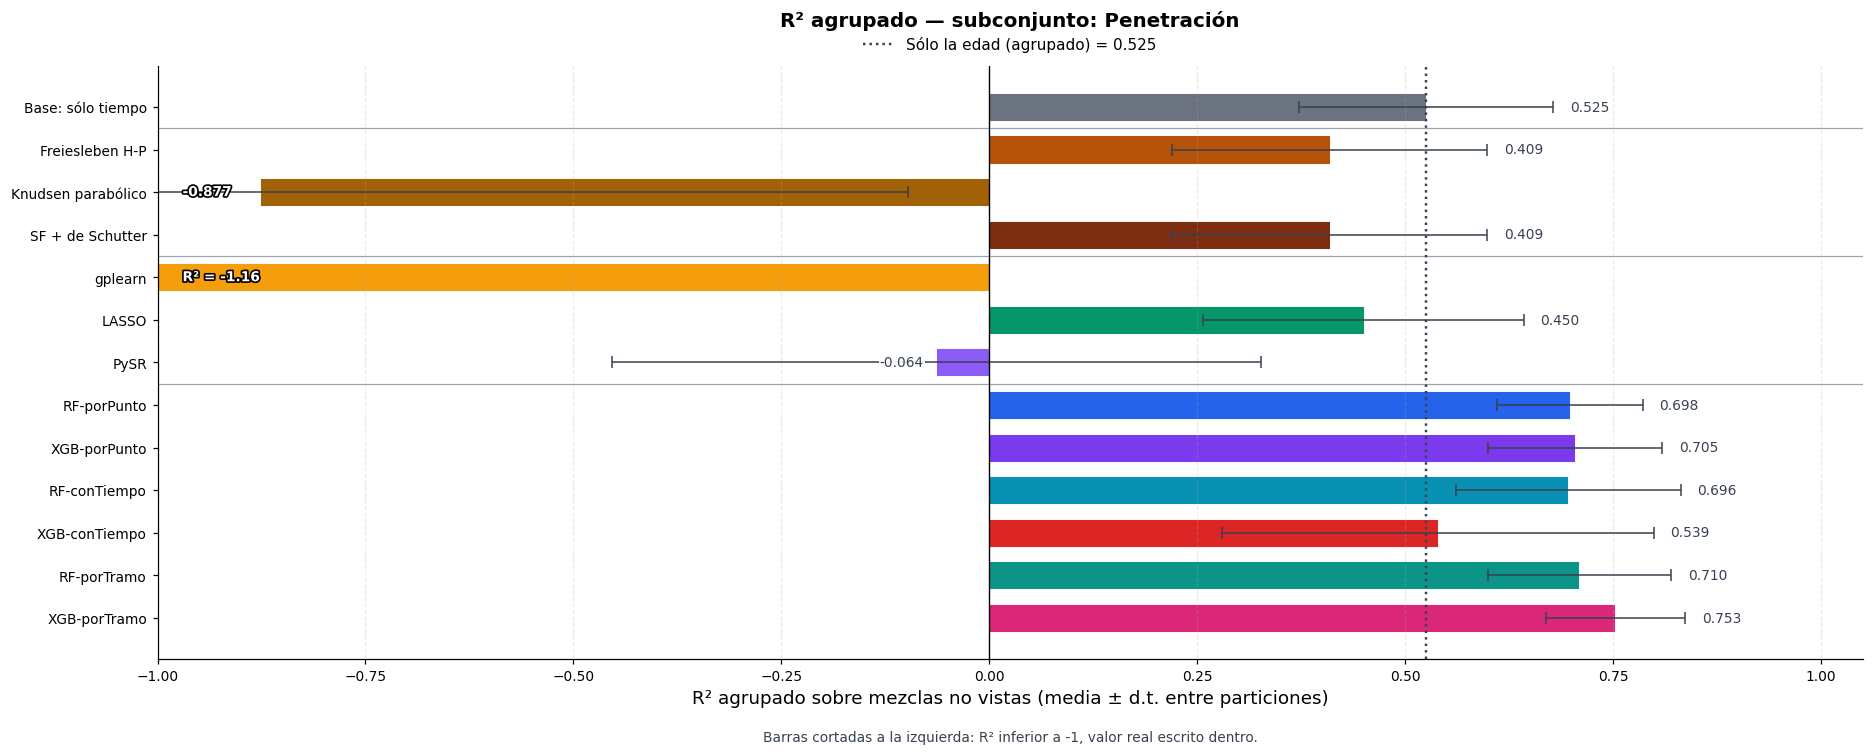

    figura guardada: figuras/fig_5_r2_agrupado_penetracion.pdf


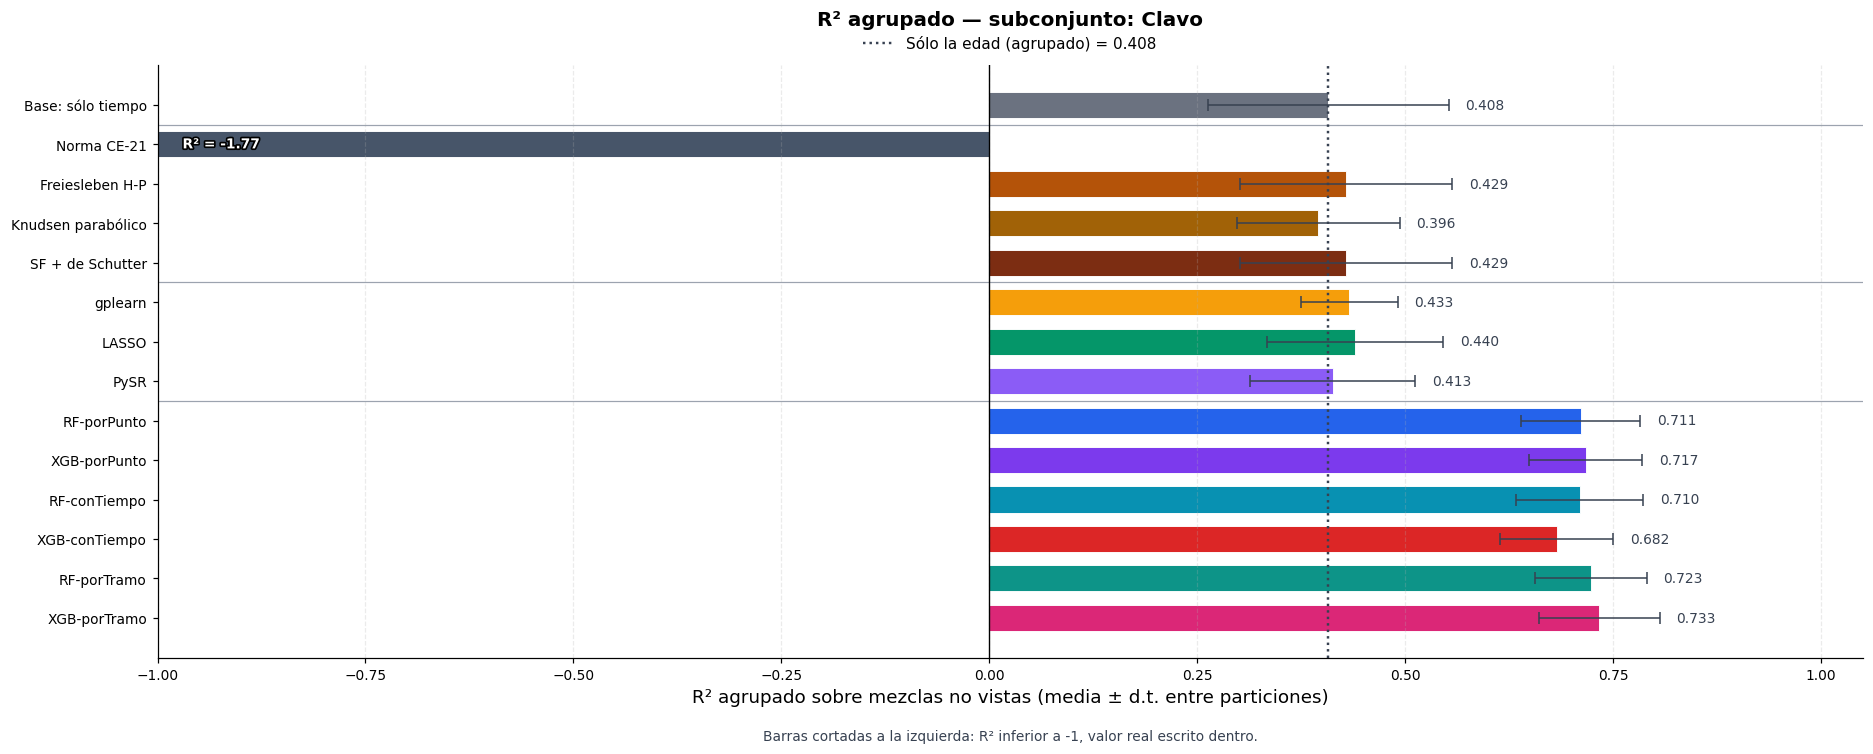

    figura guardada: figuras/fig_5_r2_agrupado_clavo.pdf


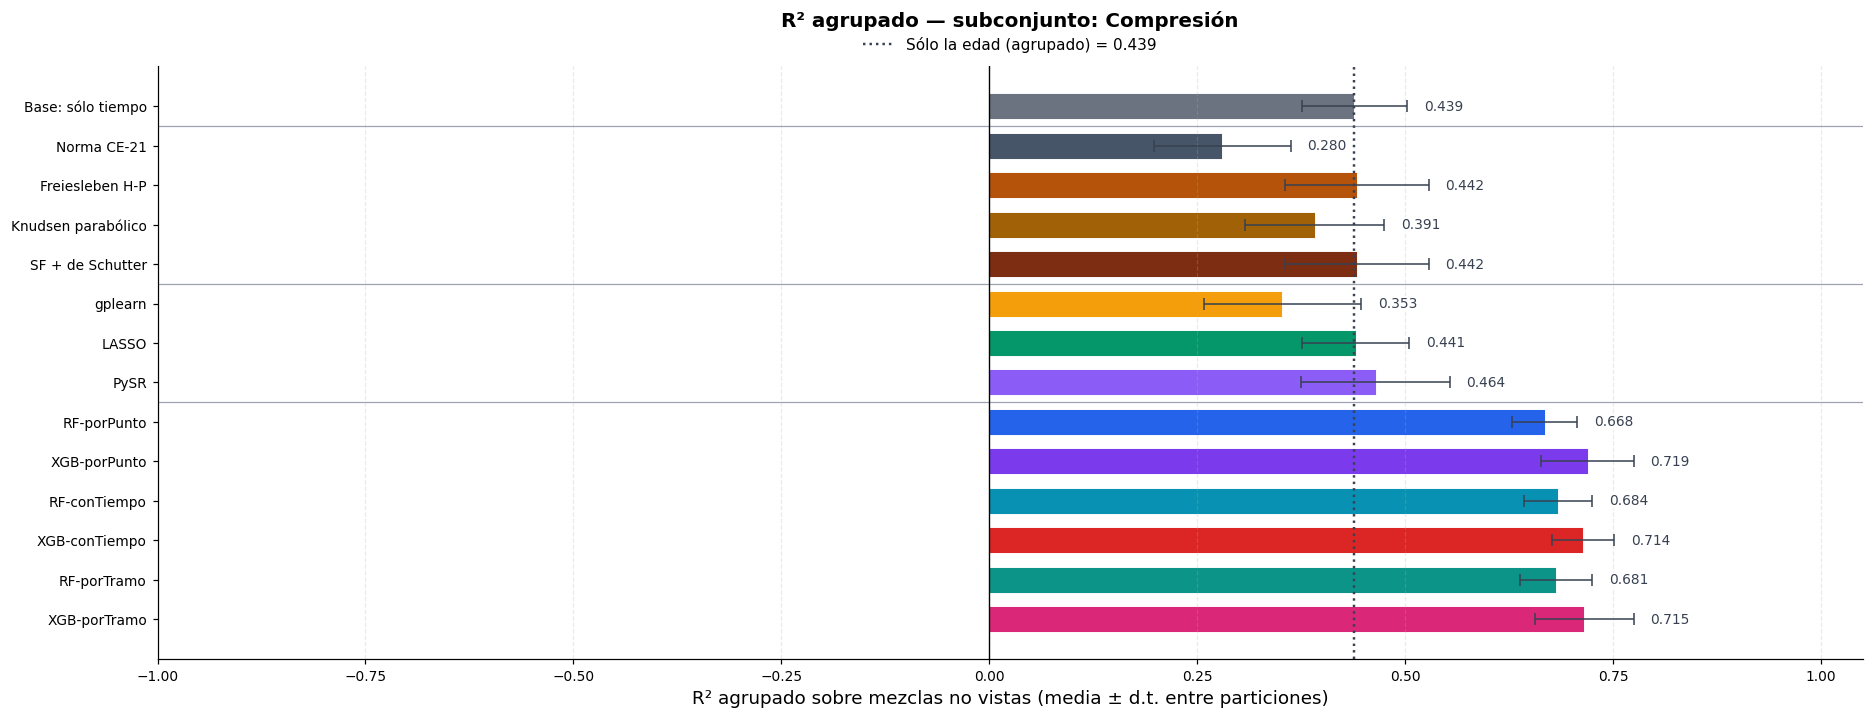

    figura guardada: figuras/fig_5_r2_agrupado_compresion.pdf


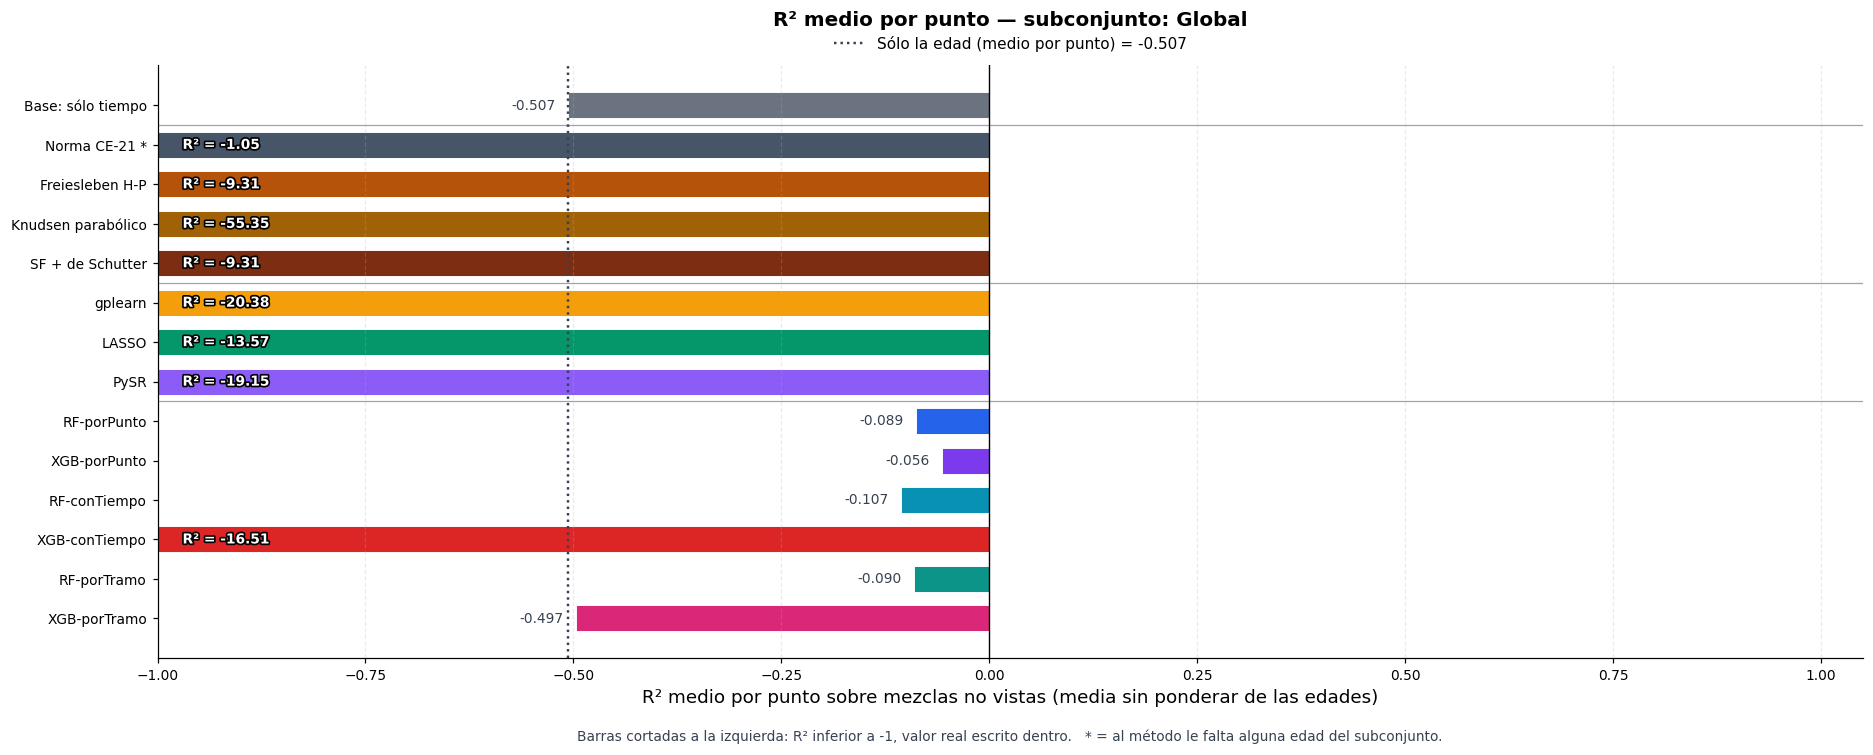

    figura guardada: figuras/fig_5_r2_medio_global.pdf


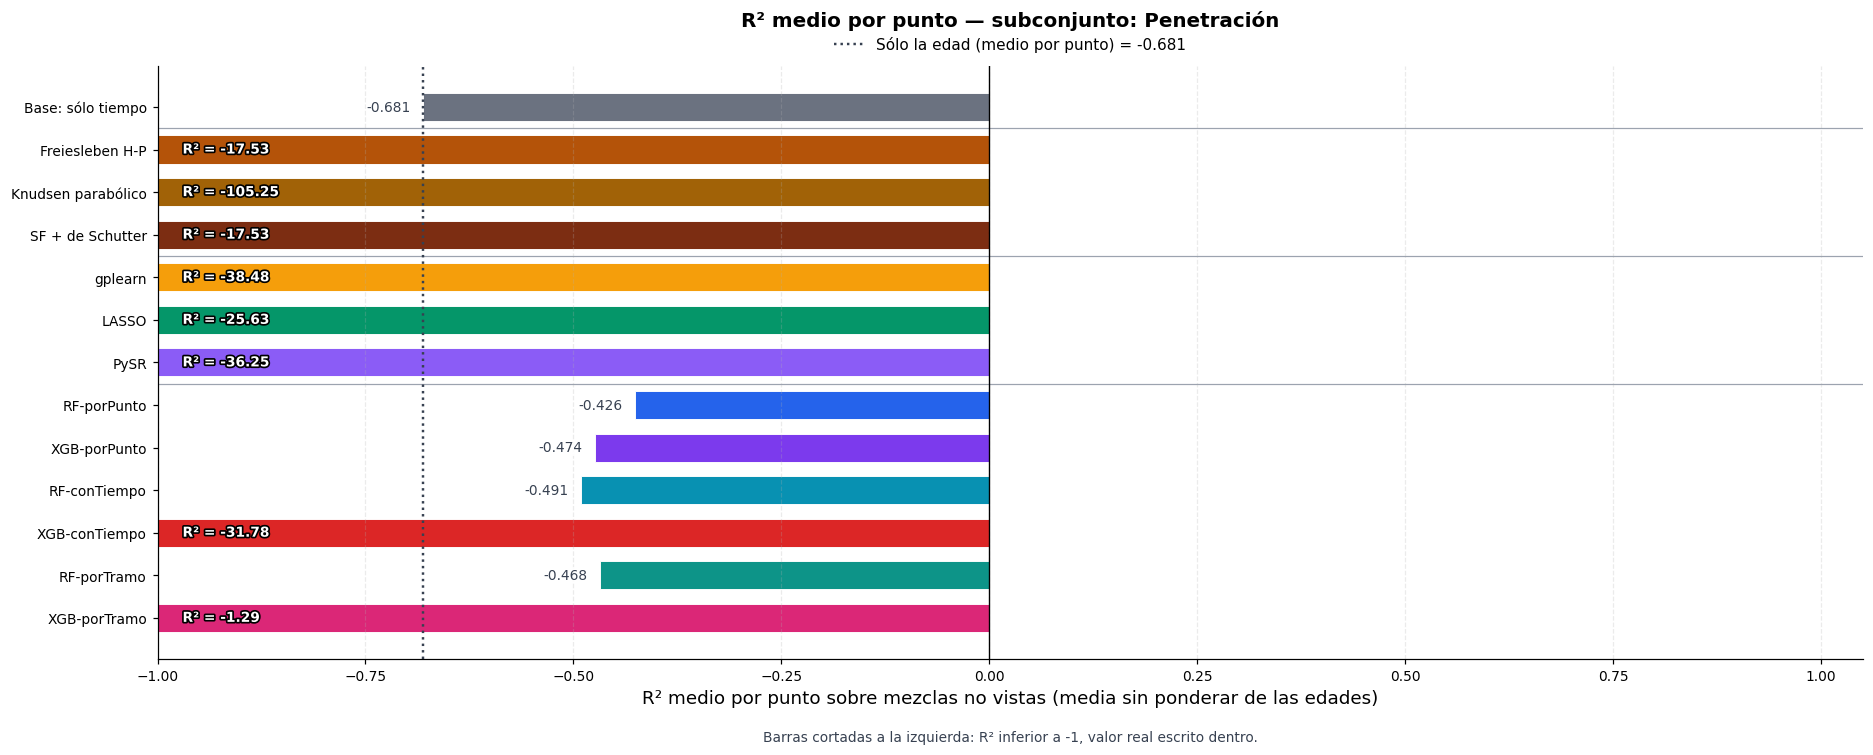

    figura guardada: figuras/fig_5_r2_medio_penetracion.pdf


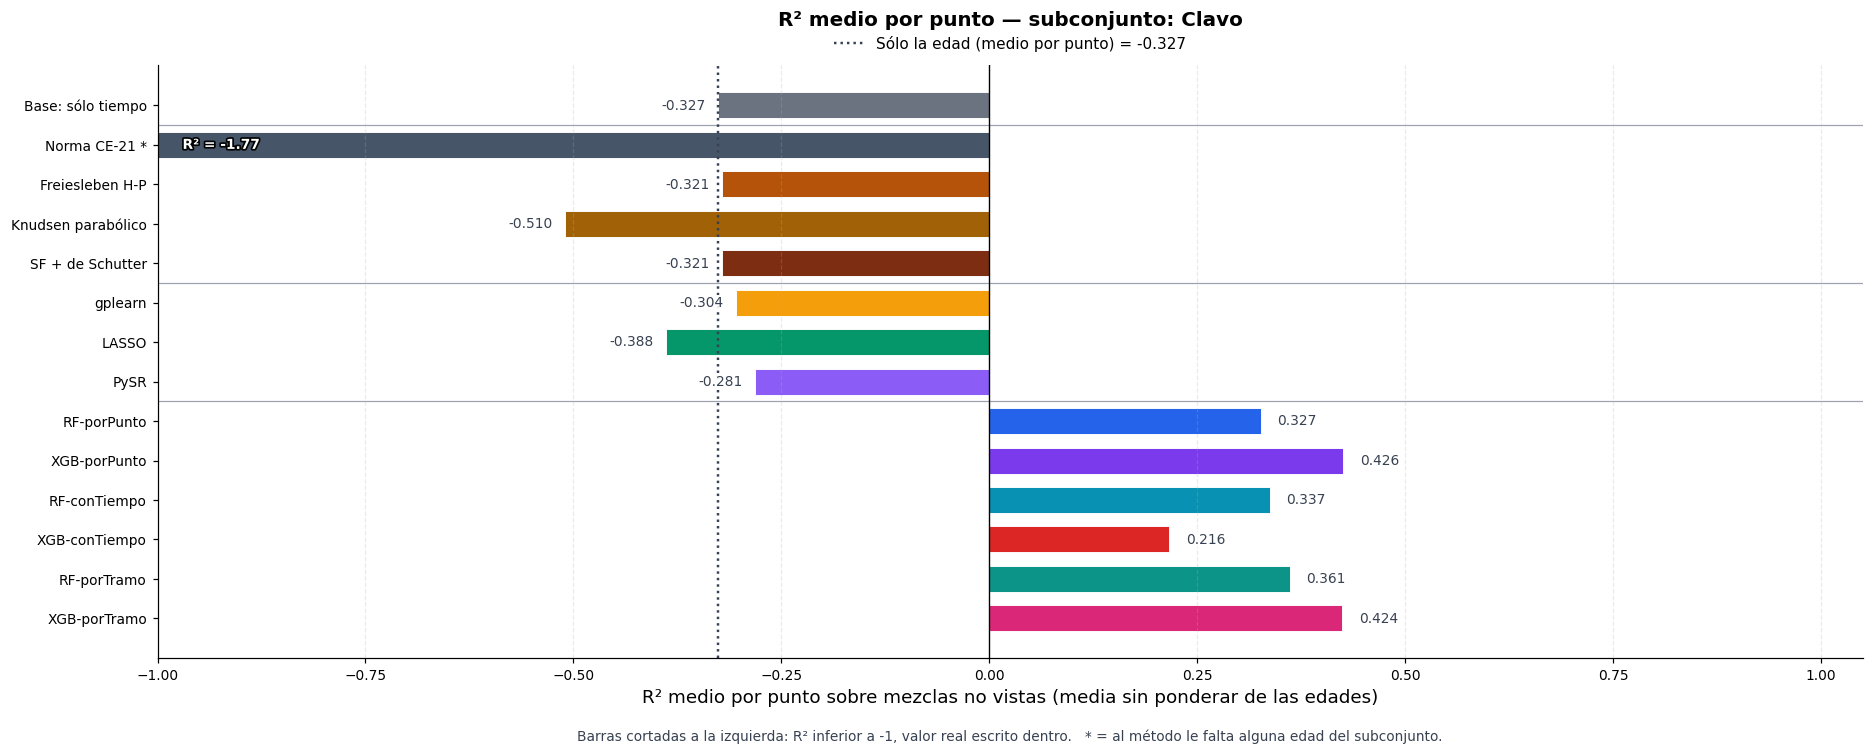

    figura guardada: figuras/fig_5_r2_medio_clavo.pdf


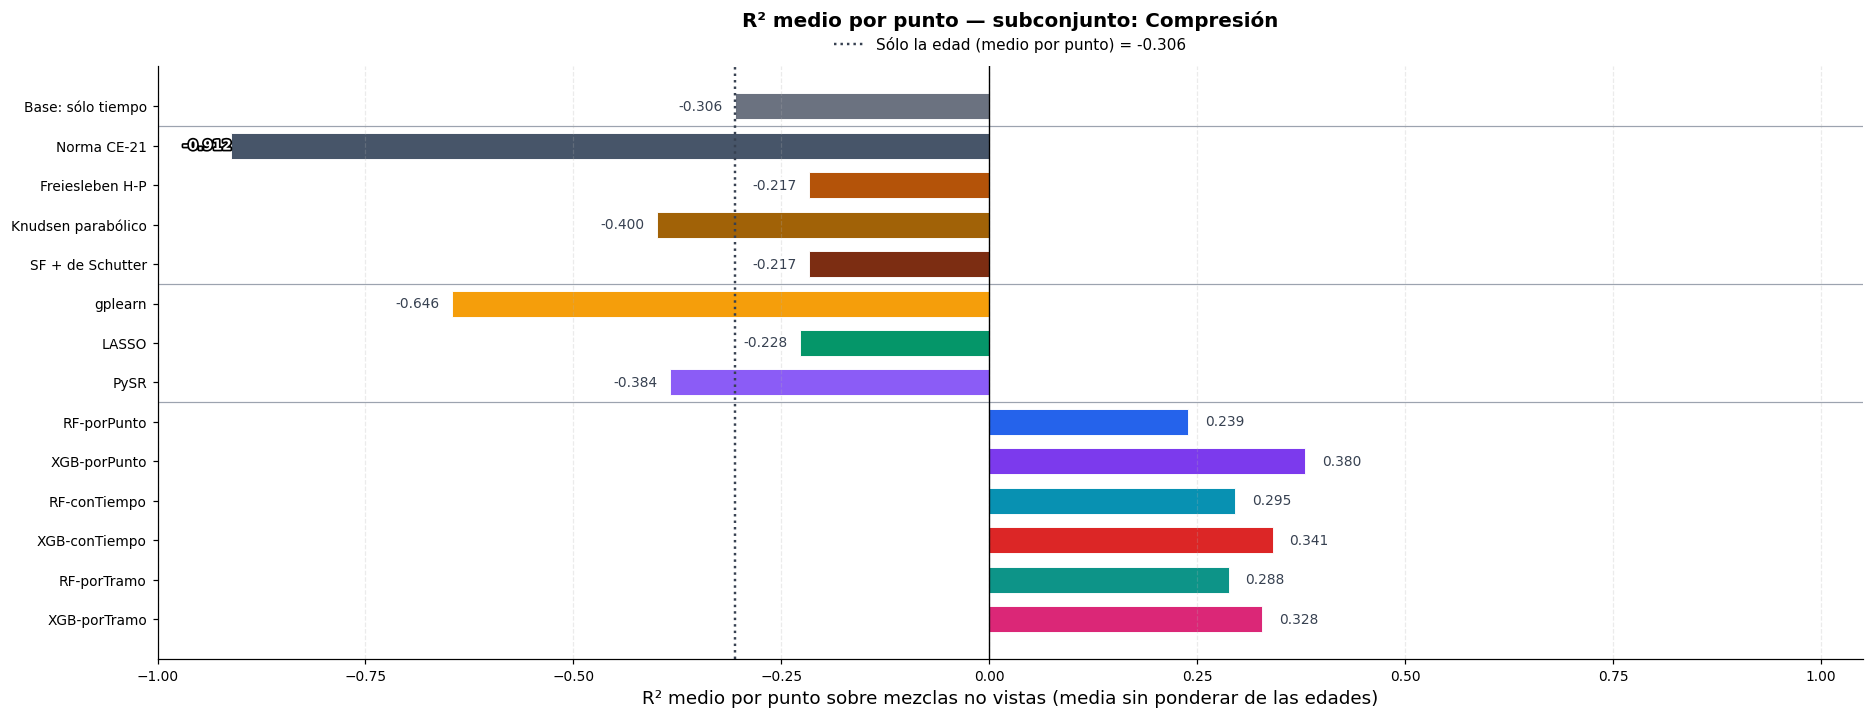

    figura guardada: figuras/fig_5_r2_medio_compresion.pdf


In [9]:
# ==============================================================================
# CELDA 5 — COMPARATIVA FINAL
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

_TXT_FUERA = dict(fontsize=9, color='#374151', zorder=6,
                  bbox=dict(facecolor='white', edgecolor='none', pad=0.6, alpha=0.9))
_TXT_DENTRO = dict(fontsize=9, color='white', fontweight='bold',
                   path_effects=[pe.withStroke(linewidth=2.2, foreground='black')])

ORDEN_METODOS = [
    'Base: sólo tiempo',
    'Norma CE-21', 'Freiesleben H-P', 'Knudsen parabólico',
    'SF + de Schutter',
    'gplearn', 'LASSO', 'PySR',
    'RF-porPunto', 'XGB-porPunto', 'RF-conTiempo', 'XGB-conTiempo',
    'RF-porTramo', 'XGB-porTramo',
]
ORDEN_METODOS = [m for m in ORDEN_METODOS if m in PRED]
SEPARADORES = ['Base: sólo tiempo', 'SF + de Schutter', 'PySR']

_CON_BASE = 'Base: sólo tiempo' not in PRED

RESUMEN          = {m: resumen_metricas(m) for m in ORDEN_METODOS}
RESUMEN_PUNTO    = {m: resumen_metricas_por_punto(m) for m in ORDEN_METODOS}
if _CON_BASE:
    RESUMEN['Base por punto']       = resumen_metricas(PRED_BASE_PUNTO)
    RESUMEN_PUNTO['Base por punto'] = resumen_metricas_por_punto(PRED_BASE_PUNTO)
_FILAS = ORDEN_METODOS + (['Base por punto'] if _CON_BASE else [])
_PART  = {m: len(PRED[m]) for m in ORDEN_METODOS}
_PART['Base por punto'] = len(PRED_BASE_PUNTO)

# ══════════════════════════════════════════════════════════════════════════════
# 1. TABLAS EN CONSOLA — las dos R² y los dos MAE de todos los métodos
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 90)
print(f"  CELDA 5 — COMPARATIVA FINAL · particiones "
      f"{int((1 - CFG_TEST_SIZE) * 100)}/{int(CFG_TEST_SIZE * 100)} agrupadas por mezcla")
print(f"  {len(ORDEN_METODOS)} métodos · imputación ajustada dentro de cada partición")
if 'CFG_OBJETIVO_LOG' in globals():
    print(f"  Modelos con el tiempo (2.B, 2.C) entrenados sobre "
          f"{'log(1 + resistencia)' if CFG_OBJETIVO_LOG else 'la resistencia en MPa'}")
print("=" * 90)
MASC_C5 = imprimir_tablas_mascaras(ORDEN_METODOS, 'COMPARATIVA FINAL',
                                   con_base=_CON_BASE)
print("  '—' = método no definido o con menos de "
      f"{CFG_MIN_TEST_METRICA} probetas de test en ese subconjunto")
print("        (la norma CE-21 no está definida por debajo de 1 día).")

# ── Resumen de lectura: cuánto infla el agrupado ──
print("\n" + "=" * 90)
print("  CUÁNTO INFLA LA R² AGRUPADA · diferencia agrupado − medio por punto (Global)")
print("=" * 90)
print(f"  {'Método':<20} {'Part.':>5} {'R² agrupado':>12} {'R² medio':>10} "
      f"{'R² mediana':>11} {'diferencia':>11}")
print("-" * 90)
for m in _FILAS:
    a, p = RESUMEN[m]['Global'], RESUMEN_PUNTO[m]['Global']
    if a is None or p is None:
        print(f"  {m:<20} {_PART[m]:>5} {'—':>12} {'—':>10} {'—':>11} {'—':>11}")
        continue
    marca = '*' if p['n_puntos'] < p['puntos_mascara'] else ' '
    print(f"  {m:<20} {_PART[m]:>5} {a['r2']:>12.3f} {p['r2']:>9.3f}{marca} "
          f"{p['r2_mediana']:>11.3f} {a['r2'] - p['r2']:>+11.3f}")
    if m in SEPARADORES and m != _FILAS[-1]:
        print("  " + "·" * 86)
print("=" * 90)
print("  La R² agrupada de 'Base: sólo tiempo' (predecir la media de cada edad sin")
print("  mirar la mezcla) es la cota que cualquier modelo alcanza sólo por conocer")
print("  la edad. La R² media por punto es la que dice si el modelo distingue mezclas.")
print("  La mediana acompaña porque un solo punto muy negativo arrastra la media.")
print("  '*' = al método le falta algún punto evaluable (p. ej. CE-21 bajo 1 día).")

# ══════════════════════════════════════════════════════════════════════════════
# 2. CLASES J DE TODOS LOS MÉTODOS (si la Celda 4 se ha ejecutado)
# ══════════════════════════════════════════════════════════════════════════════
ACIERTO_J = {}
if 'acierto_J_particiones' in globals():
    ACIERTO_J = {m: acierto_J_particiones(m) for m in ORDEN_METODOS}
    _et = clasificar_J(T_ALL, Y_ALL)
    _et = _et[np.isin(_et, ETIQUETAS_J)]
    _may = max(ETIQUETAS_J, key=lambda c: np.sum(_et == c))
    _n_cl = sum(np.any(_et == c) for c in ETIQUETAS_J)
    print("\n" + "=" * 90)
    print("  CLASES J (6 min – 24 h) · acierto sobre mezclas no vistas")
    print("=" * 90)
    print(f"  Referencia: decir siempre '{_may}' acierta el {np.mean(_et == _may):.1%} "
          f"(equilibrado: {1 / _n_cl:.1%}).")
    print(f"\n  {'Método':<20} {'Part.':>5} {'acierto simple':>18} "
          f"{'acierto equilibrado':>22}")
    print("-" * 90)
    for m in ORDEN_METODOS:
        d = ACIERTO_J[m]
        if d is None:
            print(f"  {m:<20} {_PART[m]:>5} {'—':>18} {'—':>22}")
        else:
            print(f"  {m:<20} {_PART[m]:>5} {d['acierto']:>9.1%} ± {d['sd']:>5.1%} "
                  f"{d['equilibrado']:>13.1%} ± {d['equilibrado_sd']:>5.1%}")
        if m in SEPARADORES and m != ORDEN_METODOS[-1]:
            print("  " + "·" * 86)
    print("=" * 90)
    print("  Norma CE-21: sólo clasifica a 24 h (única edad de su rango dentro del")
    print("  diagrama J), así que su acierto se mide sobre muy pocos ensayos.")
else:
    print("\n  (Clases J: ejecutar la Celda 4 para compararlas aquí)")

# ══════════════════════════════════════════════════════════════════════════════
# 3. TABLAS EN LaTeX
# ══════════════════════════════════════════════════════════════════════════════
def _escapar(texto):
    for a, b in [('≥', r'$\geq$'), ('≤', r'$\leq$'), ('±', r'$\pm$'),
                 ('²', r'$^2$'), ('&', r'\&'), ('%', r'\%'), ('_', r'\_')]:
        texto = texto.replace(a, b)
    return texto

def _num(x, dec):
    return rf"${x:.{dec}f}$"

def tabla_latex(campo, titulo, etiqueta, claves=None, incluir_particiones=True):
    claves = list(MASCARAS) if claves is None else claves
    dec = 3 if campo == 'r2' else 2
    nombre = r'$R^2$' if campo == 'r2' else r'MAE'
    n_col = len(claves)
    col_extra = 'c' if incluir_particiones else ''
    L = [r'\begin{table}[htbp]', r'  \centering',
         rf'  \caption{{{titulo}}}', rf'  \label{{{etiqueta}}}', r'  \small',
         r'  \resizebox{\textwidth}{!}{%',
         r'  \begin{tabular}{l' + col_extra + 'cc' * n_col + '}',
         r'    \toprule']
    cab = [r'\textbf{Método}'] + ([r'\textbf{Part.}'] if incluir_particiones else [])
    reglas = []
    d0 = 2 + (1 if incluir_particiones else 0)
    for i, clave in enumerate(claves):
        cab.append(rf'\multicolumn{{2}}{{c}}{{\textbf{{{MASCARAS_LATEX[clave]}}}}}')
        reglas.append(rf'\cmidrule(lr){{{d0 + 2 * i}-{d0 + 1 + 2 * i}}}')
    L.append('    ' + ' & '.join(cab) + r' \\')
    L.append('    ' + ''.join(reglas))
    sub = [''] + ([''] if incluir_particiones else [])
    for _ in claves:
        sub += [rf'{nombre} agrupado', rf'{nombre} medio']
    L.append('    ' + ' & '.join(sub) + r' \\')
    L.append(r'    \midrule')
    for m in _FILAS:
        celdas = [_escapar(m)] + ([str(_PART[m])] if incluir_particiones else [])
        for clave in claves:
            a, p = RESUMEN[m][clave], RESUMEN_PUNTO[m][clave]
            celdas.append(r'\textemdash' if a is None else
                          rf"${a[campo]:.{dec}f} \pm {a[campo + '_sd']:.{dec}f}$")
            if p is None:
                celdas.append(r'\textemdash')
            else:
                txt = _num(p[campo], dec)
                if p['n_puntos'] < p['puntos_mascara']:
                    txt += r'$^{*}$'
                celdas.append(txt)
        L.append('    ' + ' & '.join(celdas) + r' \\')
        if m in SEPARADORES and m != _FILAS[-1]:
            L.append(r'    \midrule')
    L += [r'    \bottomrule', r'  \end{tabular}}', r'\end{table}']
    return '\n'.join(L)

_pie = (f'Todos los métodos se evalúan con el mismo protocolo: particiones '
        f'{int((1 - CFG_TEST_SIZE) * 100)}/{int(CFG_TEST_SIZE * 100)} agrupadas por '
        f'mezcla (ninguna amasada aparece a la vez en entrenamiento y validación) e '
        f'imputación ajustada dentro de cada partición. Part.: número de '
        f'particiones empleadas en cada método. ')

_pie_r2 = (r'\emph{Agrupado}: una $R^2$ con todos los ensayos del subconjunto, media '
           r'$\pm$ desviación típica entre particiones; incluye la variación entre '
           r'edades, por lo que es alta incluso para una predicción que sólo conoce '
           r'la edad (fila Base: sólo tiempo). \emph{Medio}: media sin ponderar de '
           r'la $R^2$ de cada edad del subconjunto; mide la capacidad de distinguir '
           r'mezclas a edad fija. $^{*}$: al método le falta alguna edad del '
           r'subconjunto.')

_pie_mae = (r'\emph{Agrupado}: error absoluto medio de todos los ensayos del '
            r'subconjunto (media $\pm$ desviación típica entre particiones), que pesa '
            r'cada edad según su número de probetas. \emph{Medio}: media sin ponderar '
            r'del MAE de cada edad. Los MAE no son comparables entre familias de '
            r'ensayo: la penetración y el clavo se miden sobre un rango de '
            r'resistencias un orden de magnitud inferior al de la compresión.')

TABLA_LATEX_R2  = tabla_latex('r2', _pie + _pie_r2, 'tab:comparativa_r2')
TABLA_LATEX_MAE = tabla_latex('mae', _pie + _pie_mae, 'tab:comparativa_mae')

print("\n" + "=" * 90)
print("  TABLAS LaTeX (preámbulo: \\usepackage{booktabs} y \\usepackage{graphicx})")
print("=" * 90)
print("\n% ── R² agrupado y medio por punto ──")
print(TABLA_LATEX_R2)
print("\n% ── MAE agrupado y medio por punto ──")
print(TABLA_LATEX_MAE)

with open('tablas_comparativa.tex', 'w', encoding='utf-8') as _f:
    _f.write("% Generado por la Celda 5. Requiere booktabs y graphicx.\n\n")
    _f.write(TABLA_LATEX_R2 + "\n\n" + TABLA_LATEX_MAE + "\n")
print("\n  Guardadas también en tablas_comparativa.tex")

# ══════════════════════════════════════════════════════════════════════════════
# 4. FIGURAS RESUMEN — 8 figuras: 4 de R² agrupado y 4 de R² medio por punto
# ══════════════════════════════════════════════════════════════════════════════
CFG_PISO_R2 = -1.0

_NOMBRE_ARCHIVO = {'Global': 'global', 'Penetración': 'penetracion',
                   'Clavo': 'clavo', 'Compresión': 'compresion'}
_REF = 'Base por punto' if _CON_BASE else 'Base: sólo tiempo'
_TIPOS_FIG = {
    'agrupado': dict(fuente=RESUMEN, con_error=True,
                     eje='R² agrupado sobre mezclas no vistas '
                         '(media ± d.t. entre particiones)',
                     titulo='R² agrupado', ref='Sólo la edad (agrupado)'),
    'medio':    dict(fuente=RESUMEN_PUNTO, con_error=False,
                     eje='R² medio por punto sobre mezclas no vistas '
                         '(media sin ponderar de las edades)',
                     titulo='R² medio por punto', ref='Sólo la edad (medio por punto)'),
}

def figura_resumen_r2(clave, tipo, archivo, figsize=(20.0, 7.0)):
    cfg = _TIPOS_FIG[tipo]
    datos = {m: cfg['fuente'][m][clave] for m in _FILAS}
    metodos = [m for m in _FILAS if datos[m] is not None]
    if not metodos:
        print(f"    (sin métodos evaluables en {clave}; no se dibuja {archivo})")
        return

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(metodos))
    valores = np.array([datos[m]['r2'] for m in metodos])
    errores = (np.array([datos[m]['r2_sd'] for m in metodos])
               if cfg['con_error'] else np.zeros(len(metodos)))
    fuera = valores < CFG_PISO_R2

    ax.barh(y, np.maximum(valores, CFG_PISO_R2),
            xerr=(np.where(fuera, 0.0, errores) if cfg['con_error'] else None),
            capsize=4, height=0.66, color=[COLOR.get(m, '#6B7280') for m in metodos],
            edgecolor='white', lw=0.6, error_kw={'lw': 1.0, 'ecolor': '#374151'})

    for i, (v, e, f) in enumerate(zip(valores, errores, fuera)):
        if f:
            ax.text(CFG_PISO_R2 + 0.03, i, f'R² = {v:.2f}', va='center', ha='left',
                    **_TXT_DENTRO)
        elif v >= 0:
            ax.text(v + e + 0.02, i, f'{v:.3f}', va='center', ha='left', **_TXT_FUERA)
        elif v - 0.14 > CFG_PISO_R2:
            ax.text(v - 0.015, i, f'{v:.3f}', va='center', ha='right', **_TXT_FUERA)
        else:
            ax.text(CFG_PISO_R2 + 0.03, i, f'{v:.3f}', va='center', ha='left',
                    **_TXT_DENTRO)

    for sep in SEPARADORES:
        if sep in metodos and sep != metodos[-1]:
            ax.axhline(metodos.index(sep) + 0.5, color='#9CA3AF', lw=0.8, ls='-')

    leyenda = []
    ref = cfg['fuente'][_REF][clave]
    if ref is not None and ref['r2'] >= CFG_PISO_R2:
        ax.axvline(ref['r2'], color='#374151', ls=':', lw=1.6)
        leyenda.append(Line2D([0], [0], color='#374151', ls=':', lw=1.6,
                              label=f"{cfg['ref']} = {ref['r2']:.3f}"))
    ax.axvline(0, color='black', lw=0.9)
    etiquetas = [m + (' *' if datos[m].get('n_puntos', 1) < datos[m].get('puntos_mascara', 1)
                      else '') for m in metodos]
    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(CFG_PISO_R2, 1.05)
    ax.set_xlabel(cfg['eje'], fontsize=12)
    ax.set_title(f"{cfg['titulo']} — subconjunto: {clave}",
                 fontsize=13, fontweight='bold', pad=(26 if leyenda else 6))
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, axis='x', alpha=0.25)
    ax.grid(False, axis='y')
    if leyenda:
        ax.legend(handles=leyenda, fontsize=10, loc='lower center',
                  bbox_to_anchor=(0.5, 1.0), frameon=False)
    notas = []
    if fuera.any():
        notas.append(f'Barras cortadas a la izquierda: R² inferior a '
                     f'{CFG_PISO_R2:g}, valor real escrito dentro.')
    if tipo == 'medio' and any(datos[m].get('n_puntos', 1) < datos[m].get('puntos_mascara', 1)
                               for m in metodos):
        notas.append('* = al método le falta alguna edad del subconjunto.')
    if notas:
        ax.text(0.5, -0.12, '   '.join(notas), transform=ax.transAxes,
                ha='center', va='top', fontsize=9, color='#374151')
    guardar_figura(fig, archivo)

for tipo in ['agrupado', 'medio']:
    for clave in MASCARAS:
        figura_resumen_r2(clave, tipo, f'fig_5_r2_{tipo}_{_NOMBRE_ARCHIVO[clave]}')

In [11]:
# ==============================================================================
# CELDA 6 — DESCARGAS (figuras, tablas y modelos)
# ==============================================================================
import os, sys, zipfile, datetime
import joblib, sklearn, xgboost, numpy, scipy, pandas

CATALOGO_MODELOS = [
    ('modelo_porpunto_rf.pkl',  '1_por_punto',  'modelo_porpunto_rf.pkl',  '2',   'por_punto',            'Random Forest', 'RF-porPunto'),
    ('modelo_porpunto_xgb.pkl', '1_por_punto',  'modelo_porpunto_xgb.pkl', '2',   'por_punto',            'XGBoost',       'XGB-porPunto'),
    ('modelo_hormigon_rf.pkl',  '2_con_tiempo', 'modelo_contiempo_rf.pkl', '2.B', 'tiempo_como_variable', 'Random Forest', 'RF-conTiempo'),
    ('modelo_hormigon_xgb.pkl', '2_con_tiempo', 'modelo_contiempo_xgb.pkl','2.B', 'tiempo_como_variable', 'XGBoost',       'XGB-conTiempo'),
    ('modelo_portramo_rf.pkl',  '3_por_tramo',  'modelo_portramo_rf.pkl',  '2.C', 'por_tramo',            'Random Forest', 'RF-porTramo'),
    ('modelo_portramo_xgb.pkl', '3_por_tramo',  'modelo_portramo_xgb.pkl', '2.C', 'por_tramo',            'XGBoost',       'XGB-porTramo'),
]
DESCRIPCION_ESTRATEGIA = {
    'por_punto':            'Un modelo por edad de ensayo',
    'tiempo_como_variable': 'Un único modelo con la edad como variable',
    'por_tramo':            'Un modelo por tramo (penetración, clavo, compresión)',
}
CLAVE_ESTRUCTURA = {'por_punto': 'resultados', 'tiempo_como_variable': 'modelo_unico',
                    'por_tramo': 'modelos_tramo'}
LIMITE_GITHUB_MB = 100

def _fmt(v, dec):
    return f"{v:.{dec}f}" if isinstance(v, (int, float)) else "—"

def descargar_modelos():
    ahora = datetime.datetime.now()
    nombre_zip = f"modelos_tfg_{ahora:%Y-%m-%d_%H%M}.zip"
    versiones = {'scikit-learn': sklearn.__version__, 'xgboost': xgboost.__version__,
                 'numpy': numpy.__version__, 'scipy': scipy.__version__,
                 'pandas': pandas.__version__, 'joblib': joblib.__version__}

    leeme = [f"MODELOS DEL TFG — exportados el {ahora:%d/%m/%Y a las %H:%M}", "",
             "Configuración del cuaderno:",
             f"  Objetivo            : {'log(1 + resistencia)' if globals().get('CFG_OBJETIVO_LOG') else 'resistencia en MPa'}",
             f"  Temperatura incluida: {'sí' if globals().get('CFG_INCLUIR_TEMPERATURA') else 'no'}",
             f"  Variables ({len(globals().get('CFG_FEATURES', []))})      : "
             f"{', '.join(globals().get('CFG_FEATURES', []))}",
             f"  Python              : {sys.version.split()[0]}", "",
             "Métricas: validación agrupada por mezcla (media ± desv. típica entre particiones).",
             "=" * 78]

    print("=" * 96)
    print("  MODELOS EXPORTADOS")
    print("=" * 96)
    print(f"  {'Archivo en el zip':<38} {'Celda':>5}  {'Algoritmo':<14} "
          f"{'MAE (MPa)':>13} {'R² agr.':>8} {'MB':>7}")
    print("-" * 96)

    incluidos = 0
    with zipfile.ZipFile(nombre_zip, 'w', zipfile.ZIP_DEFLATED) as z:
        for (archivo, carpeta, nombre, celda, estrategia,
             algoritmo, registro) in CATALOGO_MODELOS:
            ruta_zip = f"{carpeta}/{nombre}"
            if not os.path.exists(archivo):
                print(f"  {ruta_zip:<38} FALTA: ejecuta la Celda {celda}")
                leeme += ["", ruta_zip, f"  NO INCLUIDO: no existe (ejecutar Celda {celda})"]
                continue

            p = joblib.load(archivo)
            assert p.get('estrategia') == estrategia and p.get('tipo') == algoritmo, (
                f"{archivo} contiene '{p.get('tipo')}' / '{p.get('estrategia')}', "
                f"no '{algoritmo}' / '{estrategia}'. Revisa el catálogo.")

            g = (p.get('metricas') or {}).get('Global') or {}
            mae = f"{_fmt(g.get('mae'), 2)} ± {_fmt(g.get('mae_sd'), 2)}"
            r2 = _fmt(g.get('r2'), 3)
            mb = os.path.getsize(archivo) / 1e6
            aviso = "  ⚠ >100 MB: GitHub no lo acepta" if mb > LIMITE_GITHUB_MB else ""
            app = ("compatible con app_2.py (lee 'resultados' y 'orden')"
                   if estrategia == 'por_punto' else "requiere adaptar app_2.py")

            z.write(archivo, ruta_zip)
            incluidos += 1
            print(f"  {ruta_zip:<38} {celda:>5}  {algoritmo:<14} {mae:>13} {r2:>8} "
                  f"{mb:>7.1f}{aviso}")
            leeme += ["", ruta_zip,
                      f"  Estrategia : {DESCRIPCION_ESTRATEGIA[estrategia]} (Celda {celda})",
                      f"  Algoritmo  : {algoritmo}   ·   registro: {registro}",
                      f"  Métricas   : MAE = {mae} MPa · R² agrupado = {r2} · "
                      f"{g.get('particiones', '—')} particiones",
                      f"  Estructura : modelo(s) en la clave '{CLAVE_ESTRUCTURA[estrategia]}'",
                      f"  Aplicación : {app}",
                      f"  Tamaño     : {mb:.1f} MB{aviso}"]

        leeme += ["", "=" * 78,
                  "requirements.txt: versiones exactas de este entorno. Cópialo a la",
                  "carpeta de la aplicación para que los .pkl se carguen sin errores."]
        z.writestr("LEEME.txt", "\n".join(leeme) + "\n")
        z.writestr("requirements.txt",
                   "streamlit\nplotly\n" +
                   "".join(f"{k}=={v}\n" for k, v in versiones.items()))

    print("-" * 96)
    print(f"  {incluidos} de {len(CATALOGO_MODELOS)} modelos en {nombre_zip} "
          f"(+ LEEME.txt y requirements.txt)")
    print(f"  Versiones: " + " · ".join(f"{k} {v}" for k, v in versiones.items()))
    try:
        from google.colab import files
        files.download(nombre_zip)
    except Exception:
        print("  (fuera de Colab: el .zip está en el directorio de trabajo)")

# ── Figuras (una sola vez) ──────────────────────────────────────────────────
descargar_figuras()

# ── Tablas LaTeX de la comparativa ──────────────────────────────────────────
if os.path.exists('tablas_comparativa.tex'):
    try:
        from google.colab import files
        files.download('tablas_comparativa.tex')
    except Exception:
        print("  (fuera de Colab: tablas_comparativa.tex está en el directorio de trabajo)")

# ── Modelos ─────────────────────────────────────────────────────────────────
descargar_modelos()

  33 figuras comprimidas en figuras_tfg.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  MODELOS EXPORTADOS
  Archivo en el zip                      Celda  Algoritmo          MAE (MPa)  R² agr.      MB
------------------------------------------------------------------------------------------------
  1_por_punto/modelo_porpunto_rf.pkl         2  Random Forest    2.99 ± 0.30    0.923    12.0
  1_por_punto/modelo_porpunto_xgb.pkl        2  XGBoost          2.80 ± 0.36    0.933     7.6
  2_con_tiempo/modelo_contiempo_rf.pkl     2.B  Random Forest    2.94 ± 0.33    0.926     8.5
  2_con_tiempo/modelo_contiempo_xgb.pkl    2.B  XGBoost          3.05 ± 0.32    0.929     0.5
  3_por_tramo/modelo_portramo_rf.pkl       2.C  Random Forest    2.92 ± 0.31    0.926     9.5
  3_por_tramo/modelo_portramo_xgb.pkl      2.C  XGBoost          2.81 ± 0.37    0.933     1.3
------------------------------------------------------------------------------------------------
  6 de 6 modelos en modelos_tfg_2026-09-28_0811.zip (+ LEEME.txt y requirements.txt)
  Versiones: scikit-learn 1.9.1 · xgboost 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>